# Haar and DCT Time Reparameterization in NumPyro

Many time series models have one latent variable per time step. A local level model, for example, has one random-walk increment per week. These variables are independent under the prior, but the data couple them, because every observation depends on all the increments before it.

This coupling is a problem for mean-field variational inference. A mean-field guide, such as `AutoNormal`, has one independent Normal per coordinate and cannot represent the correlation between increments. The coupling also slows down NUTS when its mass matrix is diagonal. In this notebook we study a reparametrization technique that addresses this issue. We focus on variational inference. We describe in the conclusion what we expect for NUTS.

The solution that we present here comes from Pyro's forecasting module, [`pyro.contrib.forecast`](https://docs.pyro.ai/en/stable/contrib.forecast.html). It is a pair of transforms, the Haar and the DCT transform, which in a nutshell are a change of coordinates in which the coupling described above is much weaker. These transforms rewrite every time-indexed latent variable in a [Haar wavelet](https://en.wikipedia.org/wiki/Haar_wavelet) basis or in a discrete cosine basis. Both bases are orthonormal, so this change of variables is a rotation. The model does not change, only the coordinates that the guide works with.

This reparameterization is now available in the NumPyro ecosystem. The transforms `HaarTransform` and `DiscreteCosineTransform`, and the reparameterizers `HaarReparam` and `DiscreteCosineReparam`, are part of NumPyro since version `0.22` (see [numpyro#2208](https://github.com/pyro-ppl/numpyro/pull/2208)). The function `time_reparam` of [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) applies them to the latent variables under the `time` plate of a forecasting model (see [numpyro_forecast#135](https://github.com/juanitorduz/numpyro_forecast/pull/135)).

In this notebook we explore these reparameterization methods in detail for mean-field variational inference. We consider three questions: *what* this reparameterization is, *why* it helps, and *how* to apply it in NumPyro. We first work with a model where we can compute everything exactly, and then we move to a real forecasting model.

For an introduction to SVI see [PyData Berlin 2025: Introduction to Stochastic Variational Inference with NumPyro](https://juanitorduz.github.io/intro_svi/). The forecasting example is the model from [From Pyro to NumPyro: Forecasting a univariate, heavy tailed time series](https://juanitorduz.github.io/numpyro_forecasting-univariate/).

## Outline

Here are the steps we follow:

1. **Local Level Model.** We write the simplest model with a time-indexed latent variable, simulate data from it, and compute its posterior in closed form.
2. **Posterior Geometry.** We look at the shape of that posterior and at why it is hard for coordinate-wise methods.
3. **Orthonormal Time Transforms.** We define the reparameterization and the two bases, the discrete cosine transform (DCT) and the Haar transform.
4. **Mean-Field Gap.** We derive how much a mean-field guide loses in each basis, and what this does to the uncertainty of the level and to the scale estimates.
5. **Local Level Experiments.** We apply the two rotations with the NumPyro reparameterizers and check the derivation with SVI.
6. **Ridership Forecasting Model.** We move to the weekly BART ridership data and to a model with unknown scales and a heavy-tailed likelihood.
7. **Variational Inference.** We compare the ELBO of the same guide in the three coordinate systems.
8. **Posterior and Forecast Comparison.** We compare the variational fits with a NUTS reference, score the forecasts on a held-out year, and run a backtest over several years.

## Prepare Notebook

We need NumPyro `0.22` or later and `numpyro_forecast` `0.4` or later.


In [1]:
from collections.abc import Callable
from time import perf_counter
from typing import NamedTuple

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import polars as pl
import seaborn as sns
from jax import random
from jax.example_libraries.optimizers import exponential_decay
from jaxtyping import Array, Float, ScalarLike, UInt
from numpyro import handlers
from numpyro.distributions.transforms import (
    DiscreteCosineTransform,
    HaarTransform,
    Transform,
)
from numpyro.infer import (
    MCMC,
    NUTS,
    SVI,
    Predictive,
    Trace_ELBO,
    init_to_uniform,
    init_to_value,
)
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import DiscreteCosineReparam, HaarReparam, LocScaleReparam
from numpyro.infer.util import log_density
from numpyro.optim import Adam
from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    eval_crps,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    time_reparam,
    to_datatree,
)
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import ForecastModel
from scipy.optimize import minimize

numpyro.set_host_device_count(n=4)
numpyro.enable_x64()


HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

pl.Config.set_float_precision(4)

%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = 42
rng_key = random.PRNGKey(seed=seed)

## Local Level Model

We start with the simplest model that has the problem. Let $T$ be the number of time steps and $y_t$ the observation at time $t = 1, \ldots, T$. We use the notation of the local level model in the [`UnobservedComponents`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.structural.UnobservedComponents.html) class of statsmodels. The observation $y_t$ is a noisy measurement of a latent level $\mu_t$, and the level is a random walk with increments $\eta_t$.

The quantity we want is the posterior of the increments given the observations. We want to know how well a mean-field guide can approximate it.

Let $\sigma_\varepsilon$ be the scale of the observation noise $\varepsilon_t$ and $\sigma_\eta$ the scale of the increments $\eta_t$. The model is

\begin{align*}
y_t & = \mu_t + \varepsilon_t, & \varepsilon_t & \sim \text{Normal}(0, \sigma_\varepsilon), \\
\mu_t & = \mu_{t-1} + \eta_t, & \eta_t & \sim \text{Normal}(0, \sigma_\eta),
\end{align*}

with $\mu_0 = 0$. Here the second argument of $\text{Normal}$ is the standard deviation. The statsmodels documentation writes the variances $\sigma_\varepsilon^2$ and $\sigma_\eta^2$ instead.

The latent variables are the increments $\eta = (\eta_1, \ldots, \eta_T)$, not the levels. This is how the Pyro forecasting tutorial and the `innovations` building block of `numpyro_forecast` write a random walk: sample white noise and take a cumulative sum, $\mu_t = \sum_{s \le t} \eta_s$. In vector form the level is $\mu = L \eta$, where $L$ is the $T \times T$ lower-triangular matrix of ones.

In this first part we keep the two scales $\sigma_\eta$ and $\sigma_\varepsilon$ fixed. Then the model is linear and Gaussian and we can compute everything analytically. We come back to unknown scales and to a non-Gaussian likelihood in the ridership example below.

First, let's write the model in NumPyro. We use the names of the Pyro tutorial: the increments are the site `drift`, $\sigma_\eta$ is `drift_scale` and $\sigma_\varepsilon$ is `sigma`. The time axis is an event dimension of the `drift` site. We write a generative model without observations, and we condition it on data later.

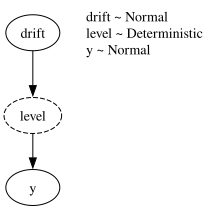

In [3]:
T_TOY = 256
DRIFT_SCALE = 0.2
SIGMA = 1.0


def local_level_model(t_obs: int, drift_scale: float, sigma: float) -> None:
    "Generative local level model with the increments as latent variables."
    drift = numpyro.sample(
        "drift", dist.Normal(0.0, drift_scale).expand([t_obs]).to_event(1)
    )
    level = numpyro.deterministic("level", jnp.cumsum(drift))
    numpyro.sample("y", dist.Normal(level, sigma).to_event(1))


toy_args = (T_TOY, DRIFT_SCALE, SIGMA)

numpyro.render_model(
    local_level_model,
    model_args=toy_args,
    render_params=True,
    render_distributions=True,
)

Next, we simulate one data set from the model itself. We use $T = 256$ time steps, $\sigma_\eta = 0.2$ and $\sigma_\varepsilon = 1$.

In [4]:
rng_key, rng_subkey = random.split(rng_key)
prior_draw = Predictive(local_level_model, num_samples=1)(rng_subkey, *toy_args)
toy_drift = prior_draw["drift"][0]
toy_level = prior_draw["level"][0]
toy_y = prior_draw["y"][0]

Let's plot the simulated observations together with the level that generated them.

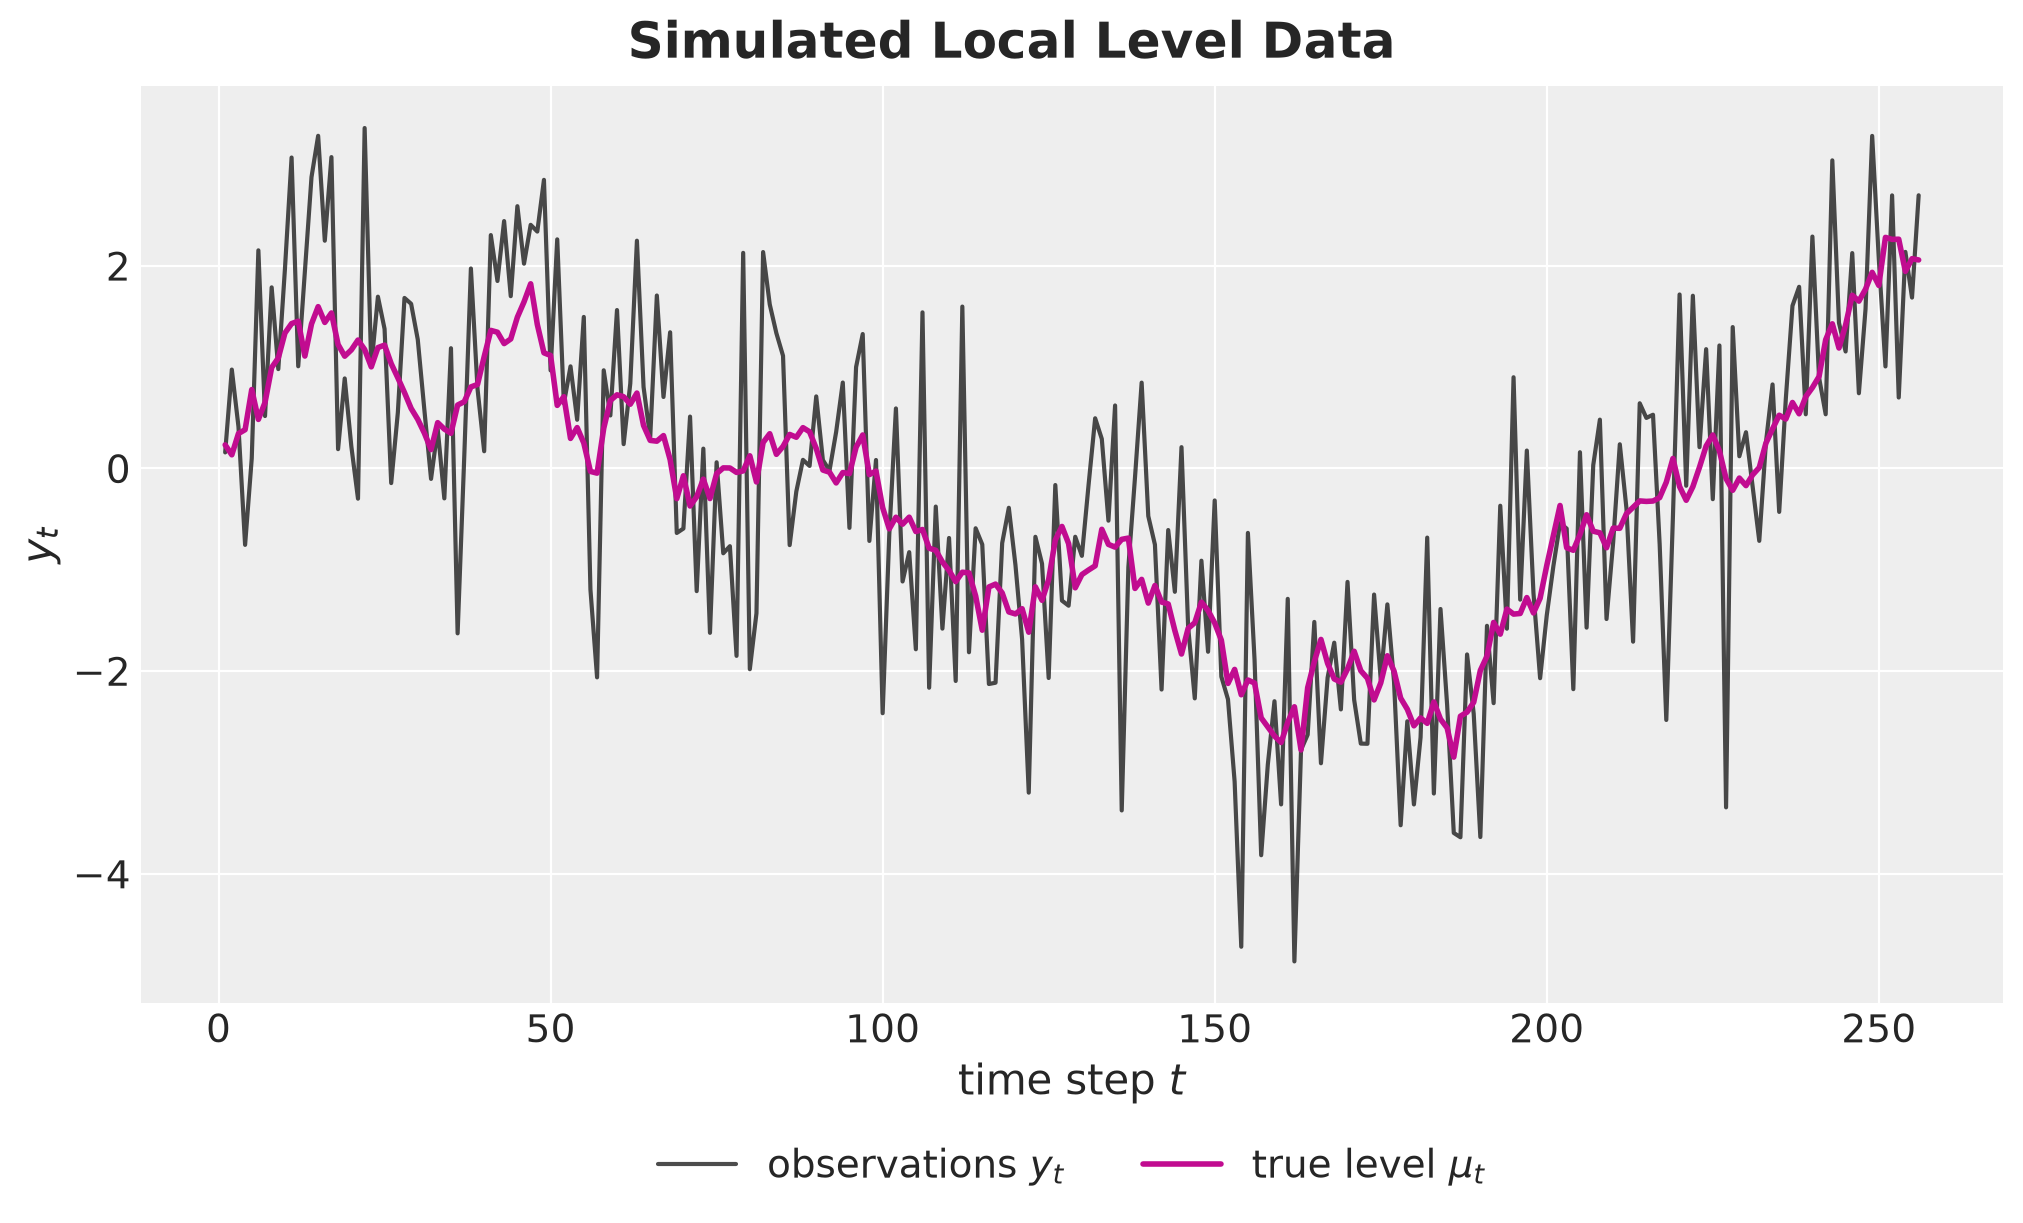

In [5]:
toy_time = jnp.arange(1, T_TOY + 1)

fig, ax = plt.subplots()
ax.plot(
    toy_time,
    toy_y,
    color="black",
    alpha=0.7,
    label="observations $y_t$",
)
ax.plot(toy_time, toy_level, color="C3", linewidth=2, label="true level $\\mu_t$")
ax.set(xlabel="time step $t$", ylabel="$y_t$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
fig.suptitle("Simulated Local Level Data", fontsize=18, fontweight="bold");

The level moves slowly relative to the noise, because one increment has a scale of $0.2$ and the noise a scale of $1$. Over $256$ time steps the increments add up, and the level moves over a range of several units. The observations therefore carry a clear signal about the path of the level, but not about any single increment.

Finally, we condition the generative model on the simulated observations with the effect handler `handlers.condition`. The resulting `toy_model`, is the model that we study in the first part of the notebook.

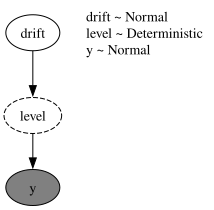

In [6]:
toy_model = handlers.condition(local_level_model, data={"y": toy_y})

numpyro.render_model(
    toy_model,
    model_args=toy_args,
    render_params=True,
    render_distributions=True,
)

### Exact Posterior

The prior of $\eta$ is Gaussian and the likelihood is Gaussian in $L \eta$. Therefore the posterior $\text{P}(\eta \mid y)$ is a multivariate Gaussian.

How do we find its parameters? Up to a constant, the log posterior is the sum of the log prior and the log likelihood:

$$
\log \text{P}(\eta \mid y) = -\frac{1}{2 \sigma_\eta^2}\, \eta^\top \eta - \frac{1}{2 \sigma_\varepsilon^2}\, (y - L \eta)^\top (y - L \eta) + \text{const} .
$$

This is a quadratic function of $\eta$. Let $\bar{\eta}$ be the posterior mean and $\Lambda$ the precision matrix (the inverse of the covariance). The precision is minus the matrix of second derivatives (the Hessian) of the log posterior, and the mean is the point where the gradient is zero. Expanding the square gives

$$
\Lambda = \frac{1}{\sigma_\eta^2} I + \frac{1}{\sigma_\varepsilon^2} L^\top L, \qquad \bar{\eta} = \frac{1}{\sigma_\varepsilon^2} \Lambda^{-1} L^\top y .
$$

In other words, this is the posterior of a Bayesian linear regression with design matrix $L$, weights $\eta$ and an isotropic Gaussian prior on the weights. See equation (2.8) of [Rasmussen and Williams (2006)](http://gaussianprocess.org/gpml/chapters/RW2.pdf) or equations (3.53) and (3.54) of [Bishop (2006)](https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf).

We make two remarks:

- **The precision does not depend on the data.** It only depends on $T$ and on the two scales. The geometry we study below is a property of the model, not of one data set.
- **The coupling comes from the cumulative sum.** The entry $(L^\top L)_{ij} = T + 1 - \max(i, j)$ counts the observations that depend on both $\eta_i$ and $\eta_j$. Two increments are coupled through every observation at or after the later of the two.

Let's compute the exact posterior of the increments and of the level $\mu = L \eta$, which has mean $L \bar{\eta}$ and covariance $L \Lambda^{-1} L^\top$. We also check the two formulas with automatic differentiation of the log density of `toy_model`: its gradient must be zero at $\bar{\eta}$, and its Hessian must be $-\Lambda$.

In [7]:
def posterior_precision(
    t_obs: int, drift_scale: ScalarLike, sigma: ScalarLike
) -> Float[Array, "t t"]:
    "Posterior precision of the increments of the local level model."
    cumsum = jnp.tril(jnp.ones((t_obs, t_obs)))
    return jnp.eye(t_obs) / drift_scale**2 + cumsum.T @ cumsum / sigma**2


def toy_log_joint(drift: Float[Array, " t"]) -> Float[Array, ""]:
    "Log joint density of the conditioned local level model at the increments."
    log_joint, _ = log_density(toy_model, toy_args, {}, {"drift": drift})
    return log_joint


cumsum_matrix = jnp.tril(jnp.ones((T_TOY, T_TOY)))

precision = posterior_precision(*toy_args)
covariance = jnp.linalg.inv(precision)

drift_mean = covariance @ cumsum_matrix.T @ toy_y / SIGMA**2
level_mean = cumsum_matrix @ drift_mean
level_covariance = cumsum_matrix @ covariance @ cumsum_matrix.T
level_sd = jnp.sqrt(jnp.diag(level_covariance))

# The gradient is zero at the mean
np.testing.assert_allclose(jax.grad(toy_log_joint)(drift_mean), 0, atol=1e-8)
# The Hessian is minus the precision.
np.testing.assert_allclose(
    jax.hessian(toy_log_joint)(drift_mean), -precision, atol=1e-8
)

Let's plot the exact posterior of the level and its $94\%$ highest density interval (HDI).

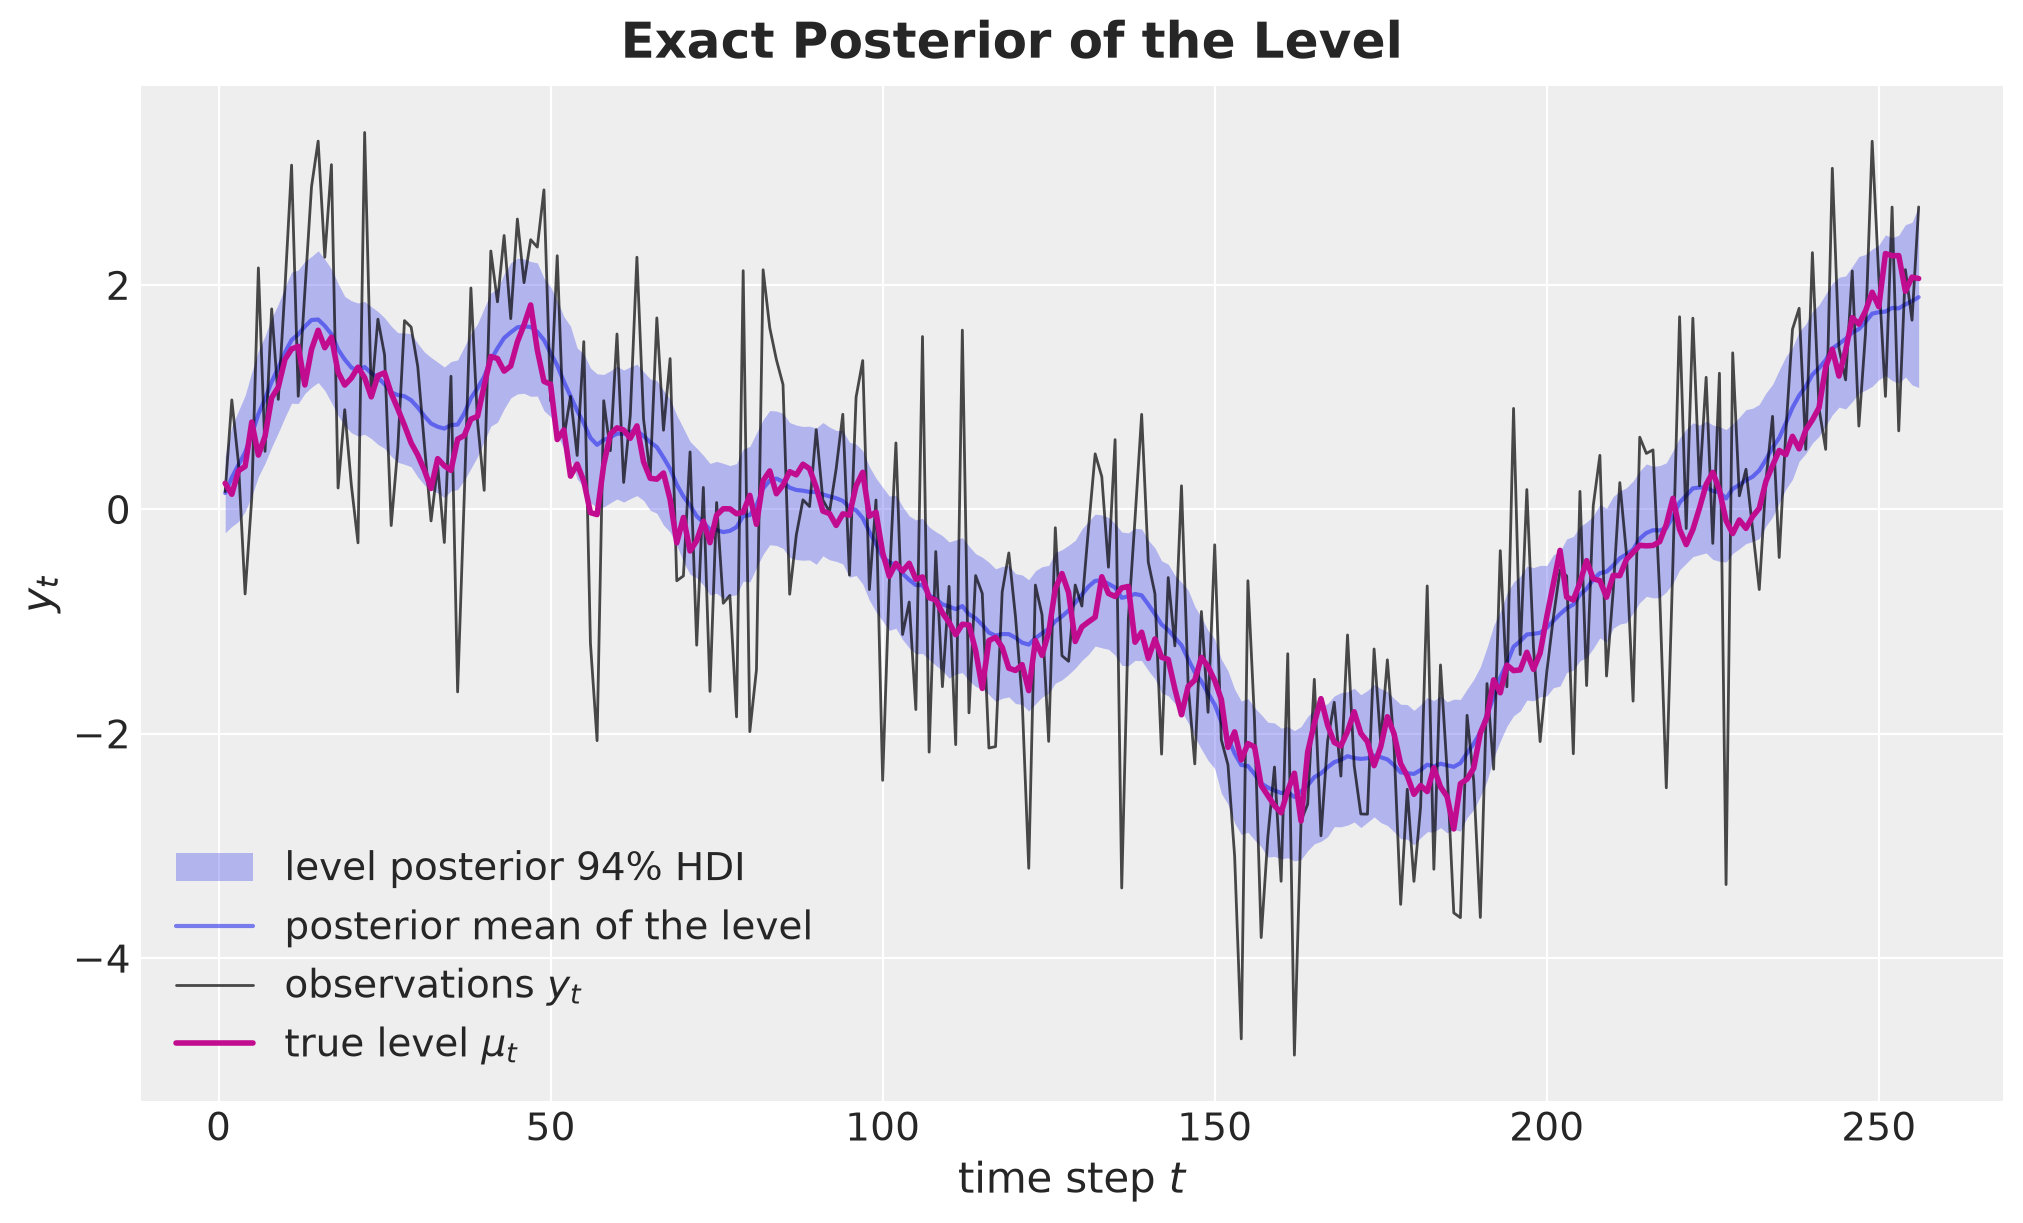

In [8]:
rng_key, rng_subkey = random.split(rng_key)
exact_level_draws = random.multivariate_normal(
    rng_subkey, level_mean, level_covariance, shape=(1, 4_000)
)

exact_tree = az.from_dict(
    {
        "posterior": {"level": np.asarray(exact_level_draws)},
        "observed_data": {"y": np.asarray(toy_y)},
        "constant_data": {"t": np.asarray(toy_time, dtype=float)},
    },
    coords={"time": np.asarray(toy_time)},
    dims={"level": ["time"], "y": ["time"], "t": ["time"]},
)

pc = az.plot_lm(
    exact_tree,
    x="t",
    y="level",
    y_obs="y",
    group="posterior",
    smooth=False,
    visuals={
        "pe_line": {"color": "C0", "label": "posterior mean of the level"},
        "ci_band": {
            "color": "C0",
            "alpha": 0.3,
            "label": r"level posterior $94\%$ HDI",
        },
        "observed_scatter": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
fig = pc.viz["figure"].item()
ax = fig.axes[0]
ax.plot(
    toy_time, toy_y, color="black", alpha=0.7, linewidth=1, label="observations $y_t$"
)
ax.plot(toy_time, toy_level, color="C3", linewidth=2, label="true level $\\mu_t$")
ax.set(xlabel="time step $t$", ylabel="$y_t$", title="")
ax.legend()
fig.suptitle("Exact Posterior of the Level", fontsize=18, fontweight="bold");

The figure shows the data, the level that we want to recover, and its exact posterior.

- **The posterior tracks the level.** The posterior mean follows the true level, and the true level stays inside the HDI most of the time.
- **The HDI has a constant width.** Away from the two ends, the data constrain the level with the same precision at every time step. We will see below that a mean-field guide on the increments cannot reproduce this property.

## Posterior Geometry

What does the posterior of the increments look like? The contours of a Gaussian density are ellipsoids, and the eigenvectors of $\Lambda$ are their axes.

A large eigenvalue is a *stiff* direction, where the data leave little freedom. A small eigenvalue is a *loose* direction.

Let's compute the eigendecomposition of $\Lambda$ numerically. We sort the eigenvalues from the largest to the smallest, so that direction $k = 0$ is the stiffest one, and we fix the sign of each eigenvector so that its first entry is positive.

In [9]:
eigenvalues, eigenvectors = jnp.linalg.eigh(precision)
order = jnp.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
eigenvectors = eigenvectors * jnp.sign(eigenvectors[0])

For this model the axes are also known in closed form. For $k = 0, \ldots, T - 1$ the eigenvectors $v_k$ of $\Lambda$ are cosines with half-integer frequencies,

$$
v_k(t) \propto \cos\left(\frac{(2k + 1)(2t - 1)\pi}{2(2T + 1)}\right), \qquad t = 1, \ldots, T .
$$

These cosines are the rows of the discrete cosine transform of type VIII. The reason is that the inverse of $L^\top L$ is a second-difference matrix, and the members of the DCT family are the eigenvectors of second-difference matrices with different boundary conditions ([Strang, 1999](https://epubs.siam.org/doi/10.1137/S0036144598336745)).

We check the closed form against the numerical eigendecomposition. The axes are cosines, sorted from the smoothest to the most oscillating, and this is what we use below.

In [10]:
frequency = jnp.arange(T_TOY)
omega = (2 * frequency + 1) * jnp.pi / (2 * T_TOY + 1)
cosines = jnp.cos(jnp.outer(toy_time - 0.5, omega))
cosines = cosines / jnp.linalg.norm(cosines, axis=0)

np.testing.assert_allclose(jnp.abs((eigenvectors * cosines).sum(axis=0)), 1, atol=1e-6)

The check passes. Now we plot the four stiffest directions (left) and, for every direction, the posterior variance relative to the prior variance (right).

Along direction $k$ the posterior variance is $1 / \text{eig}_k(\Lambda)$ and the prior variance is $\sigma_\eta^2$. We call this ratio the shrinkage of direction $k$. A ratio close to $1$ means that the data say nothing about that direction, and a ratio close to $0$ means that the data determine it.

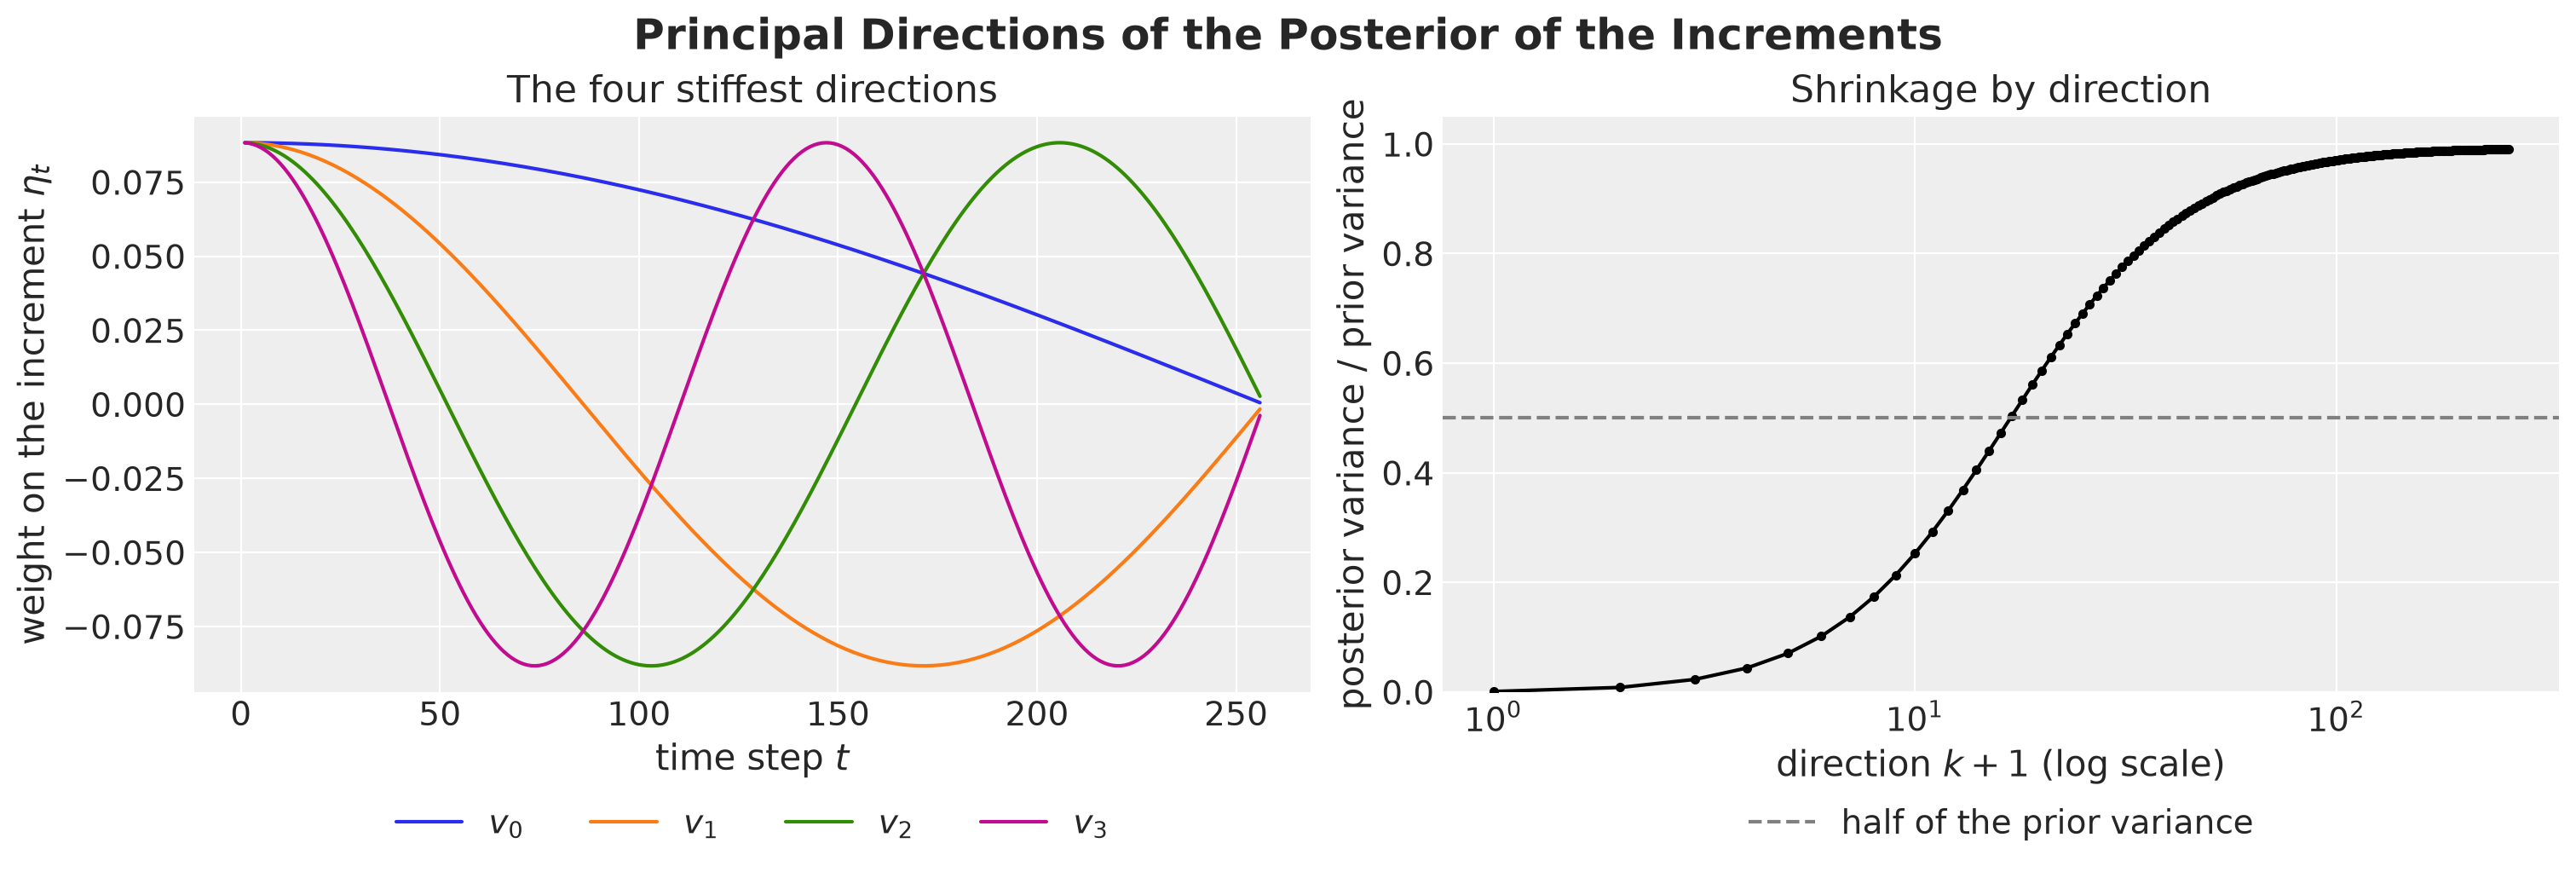

In [11]:
shrinkage = 1 / (DRIFT_SCALE**2 * eigenvalues)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

for i in range(4):
    axes[0].plot(toy_time, eigenvectors[:, i], color=f"C{i}", label=f"$v_{i}$")

axes[0].set(
    xlabel="time step $t$",
    ylabel="weight on the increment $\\eta_t$",
    title="The four stiffest directions",
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
axes[1].plot(frequency + 1, shrinkage, "o-", color="black", markersize=3)
axes[1].axhline(0.5, color="gray", linestyle="--", label="half of the prior variance")
axes[1].set(
    xscale="log",
    xlabel="direction $k + 1$ (log scale)",
    ylabel="posterior variance / prior variance",
    title="Shrinkage by direction",
    ylim=(0, 1.05),
)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15))
fig.suptitle(
    "Principal Directions of the Posterior of the Increments",
    fontsize=18,
    fontweight="bold",
);

The left panel shows the weights of the four stiffest directions on the increments. The right panel shows how much of the prior variance is left along each direction.

- **The stiff directions are smooth.** The stiffest direction $v_0$ moves all the increments in the same direction. This shifts the level at every later time step, and every observation constrains it.
- **Most directions stay at the prior.** Only $16$ of the $256$ directions lose more than half of their prior variance. The oscillating directions barely move the level, because consecutive increments cancel out, and the data do not constrain them.
- **The ellipsoid is very elongated.** The ratio between the largest and the smallest eigenvalue of $\Lambda$, its condition number, is about $1057$. Here is the computation:

In [12]:
eigenvalues.max() / eigenvalues.min()

Array(1057.01655449, dtype=float64)

Here is why this matters for the reparameterization. In the basis of the eigenvectors the posterior precision is diagonal, so a mean-field guide is exact there.

The right panel of the figure above adds that the data only constrain the few smoothest directions. The other directions stay at the prior, where a mean-field guide is exact in any basis. A fixed basis therefore only has to separate the smooth directions from the oscillating ones, and this is what the two transforms of the next section do.

Can we see the ellipsoid itself? We cannot draw it in $256$ dimensions, but we can draw two-dimensional slices through its center. A slice fixes all the other coordinates at their posterior mean. The conditional posterior of the two remaining coordinates is Gaussian, and its precision is the corresponding $2 \times 2$ block of $\Lambda$.

We draw the contour at one standard deviation, that is the points $x$ with $x^\top \Lambda_{\text{block}}\, x = 1$, for two kinds of slices:

- **Stiffest and loosest directions.** The plane of $v_{T-1}$ and $v_0$, where the block is diagonal.
- **Adjacent increments.** The plane of two increments $\eta_t$ and $\eta_{t+1}$, for $t = 1$, $128$ and $255$.

The dashed circle is the same contour for the prior, with radius $\sigma_\eta = 0.2$.

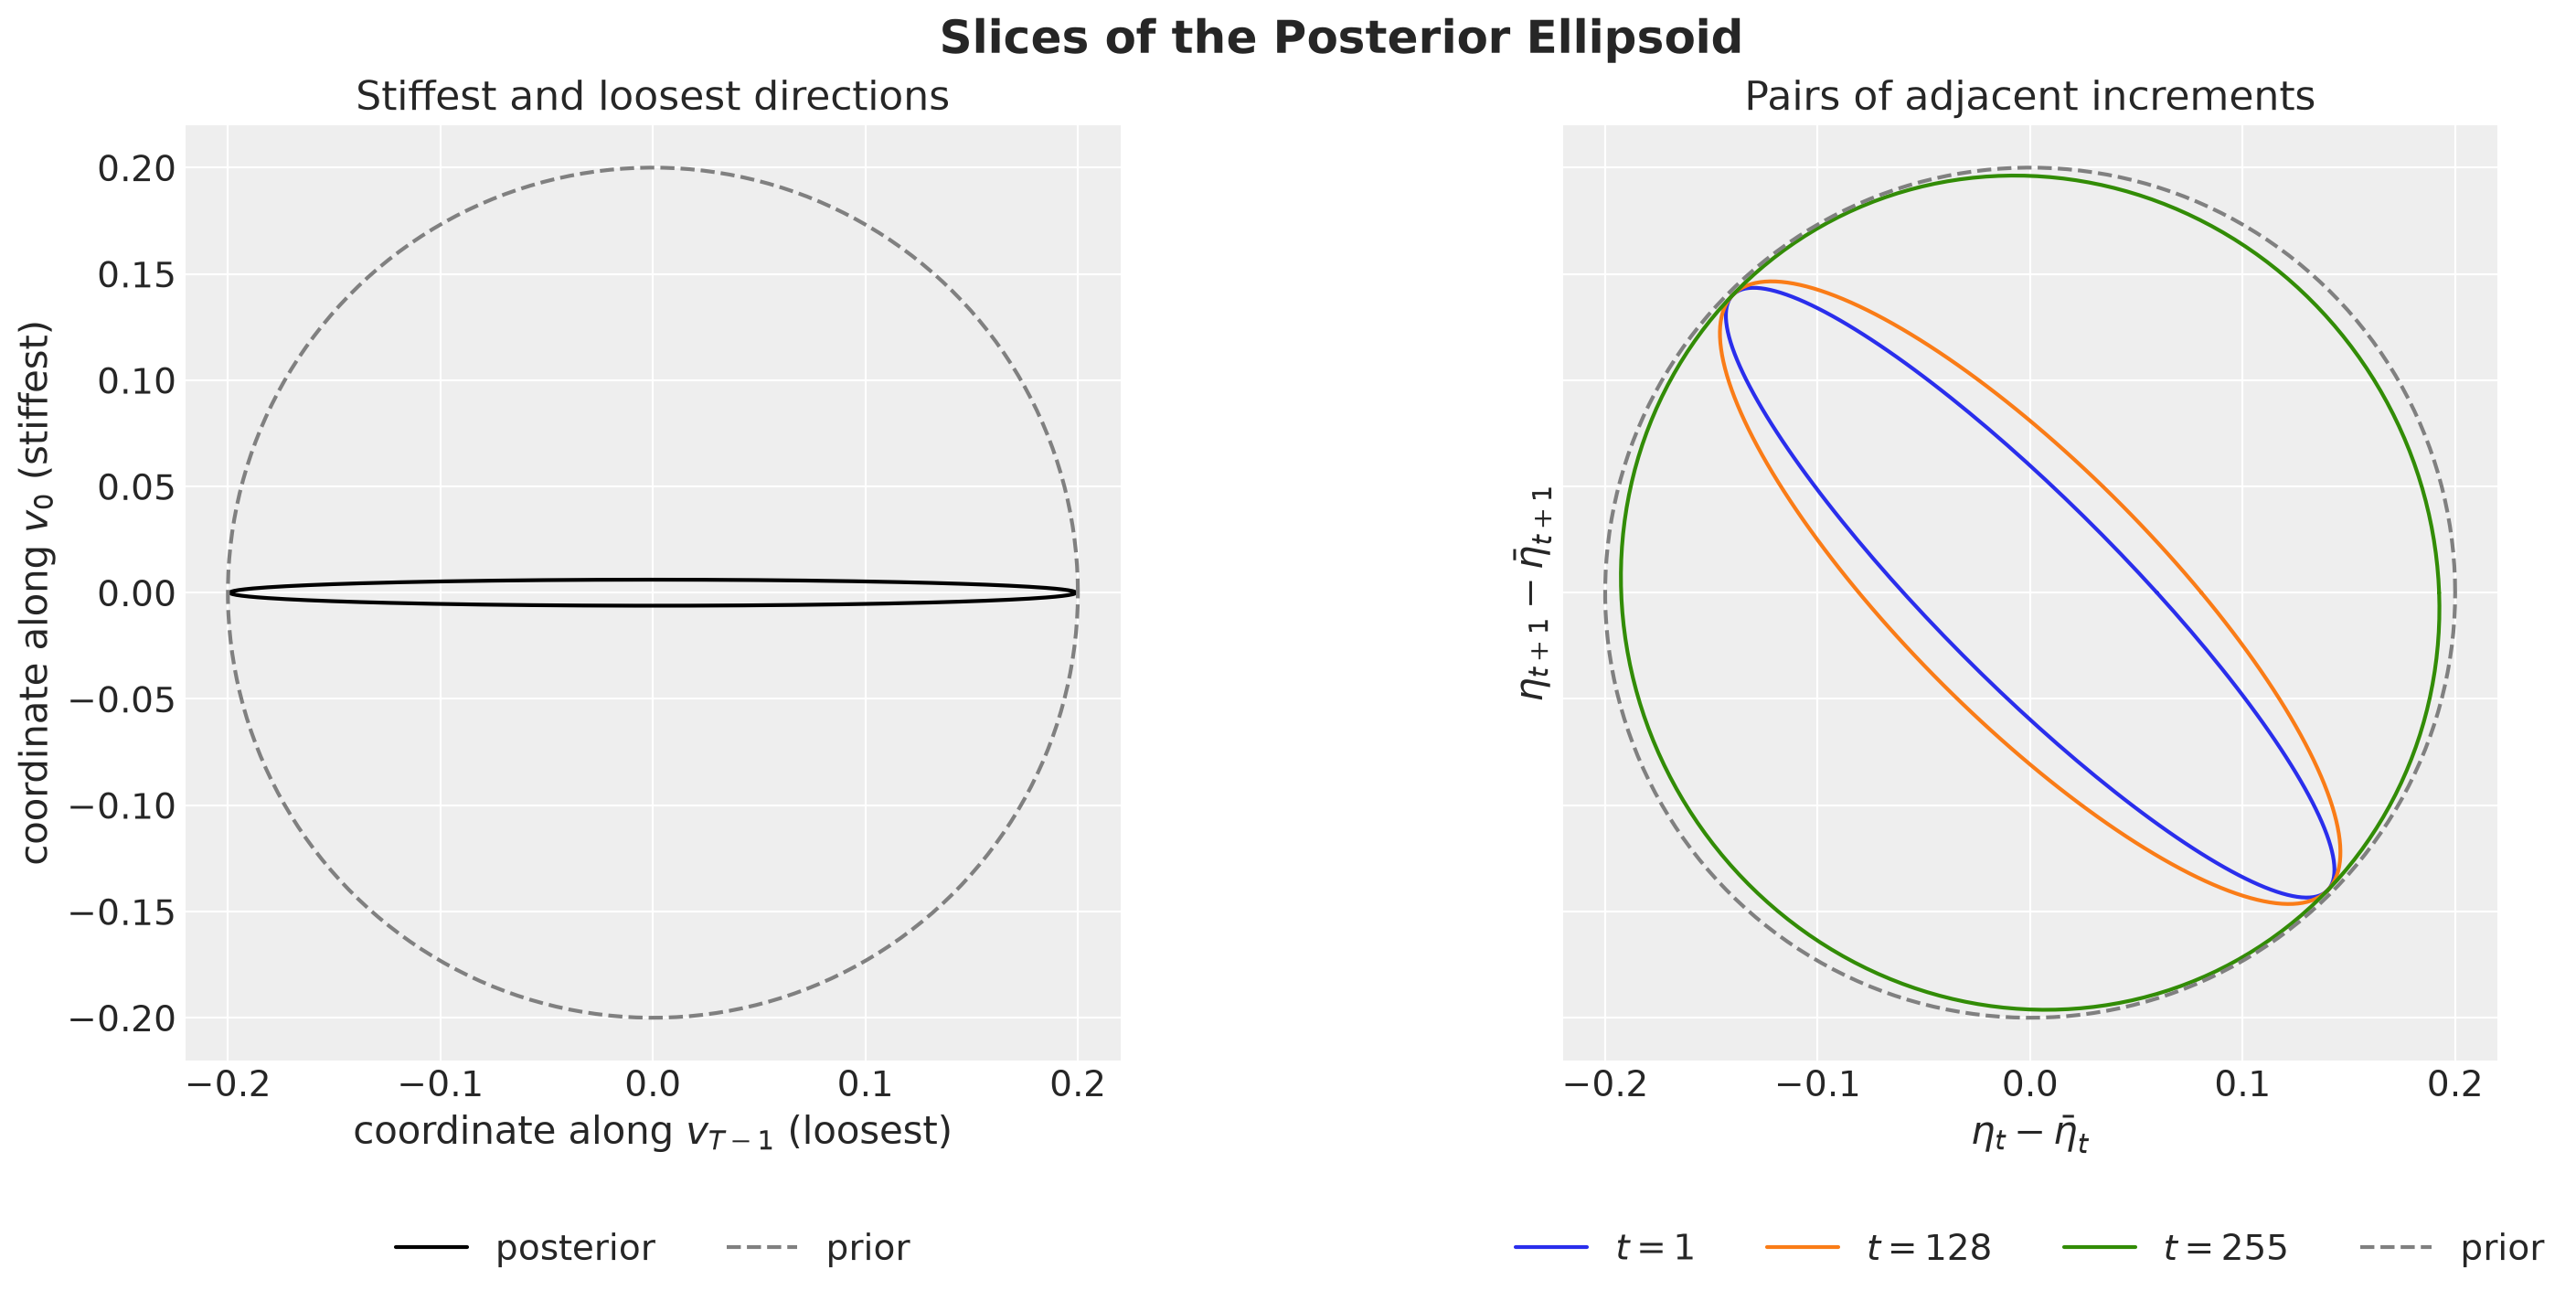

In [13]:
def contour_2d(
    block: Float[Array, "2 2"], num_points: int = 200
) -> Float[Array, "2 n"]:
    "Points x with x^T block x = 1, the one-sigma contour of a 2D Gaussian."
    angles = jnp.linspace(0, 2 * jnp.pi, num_points)
    circle = jnp.stack([jnp.cos(angles), jnp.sin(angles)])
    # If block = C C^T (Cholesky), then x = C^{-T} u satisfies x^T block x = u^T u = 1.
    cholesky = jnp.linalg.cholesky(block)
    return jnp.linalg.solve(cholesky.T, circle)


principal_block = jnp.diag(eigenvalues[jnp.array([-1, 0])])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), sharex=True, sharey=True)
axes[0].plot(*contour_2d(principal_block), color="black", label="posterior")

for i, t in enumerate([1, 128, 255]):
    pair = jnp.array([t - 1, t])  # zero-based positions of eta_t and eta_{t+1}
    block = precision[jnp.ix_(pair, pair)]
    axes[1].plot(*contour_2d(block), color=f"C{i}", label=f"$t = {t}$")

for ax in axes:
    ax.plot(
        *contour_2d(jnp.eye(2) / DRIFT_SCALE**2),
        color="gray",
        linestyle="--",
        label="prior",
    )
    ax.set_aspect("equal")

axes[0].set(
    xlabel="coordinate along $v_{T-1}$ (loosest)",
    ylabel="coordinate along $v_0$ (stiffest)",
    title="Stiffest and loosest directions",
)
axes[1].set(
    xlabel="$\\eta_t - \\bar{\\eta}_t$",
    ylabel="$\\eta_{t+1} - \\bar{\\eta}_{t+1}$",
    title="Pairs of adjacent increments",
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
fig.suptitle("Slices of the Posterior Ellipsoid", fontsize=18, fontweight="bold");

The two panels show slices of the same posterior through different planes.

- Along the principal directions the ellipse is a thin sliver.
- Along adjacent increments the ellipse is tilted.
- The tilt fades toward the end of the series.

Observe that the axes of the tilted ellipses are diagonals and not coordinate axes. In the full posterior each stiff direction mixes all the increments, not only two of them. This is the cause of the problem: a mean-field guide works coordinate by coordinate.

## Orthonormal Time Transforms

The idea of the reparameterization is to rotate the coordinates such that the axes of the ellipsoid become coordinate axes, at least approximately.

Let $U$ be a $T \times T$ orthonormal matrix, that is $U U^\top = I$, and define the new latent variable $z = U \eta$. We sample $z$ and we recover the increments as $\eta = U^\top z$. Three properties make this change of variables convenient:

- **The density does not change.** The density of $z$ is the density of $\eta$ evaluated at $U^\top z$, times $|\det U^\top| = 1$. There is no Jacobian term, and the model is the same model.
- **White noise stays white noise.** If the increments $\eta_t$ are independent $\text{Normal}(0, \sigma_\eta)$ variables, then the coefficients $z_k$ are independent $\text{Normal}(0, \sigma_\eta)$ variables too. The prior keeps its simple form.
- **The precision is rotated.** The posterior precision of $z$ is $\Lambda_U = U \Lambda U^\top$.

A rotation does not change methods that treat all directions alike. For example, a full-rank Gaussian guide reaches the same ELBO in every orthonormal basis. The rotation matters for methods that work coordinate by coordinate, such as a mean-field guide.

The best choice of $U$ is the matrix of eigenvectors of $\Lambda$, which makes $\Lambda_U$ diagonal. For the local level model these eigenvectors are the cosines of the previous section, and they do not depend on the scales. In a real model we do not know the eigenvectors: the likelihood is not Gaussian, and other parameters, such as an intercept or a regression, couple with the path.

We do know that the stiff directions are smooth and that the loose ones oscillate. Therefore we use a fixed basis that sorts the coordinates from coarse to fine. Pyro offers two, and the first one is the closest standard transform to the cosines of the previous section.

### Discrete Cosine Transform

The rows of the orthonormal DCT (type II) are cosines of increasing frequency. For $k = 0, \ldots, T - 1$ and $t = 1, \ldots, T$,

$$
C_{k t} = c_k \cos\left(\frac{\pi k (2t - 1)}{2T}\right), \qquad c_0 = \sqrt{1 / T}, \qquad c_k = \sqrt{2 / T} \ \text{ for } k \ge 1 .
$$

The first coefficient $z_0$ is the average increment times $\sqrt{T}$. The next ones are slow trends, and the last ones are step-to-step oscillations. The transform costs $O(T \log T)$ operations with a fast Fourier transform.

### Haar Transform

The Haar transform compares the averages of neighboring blocks at different scales. For $T = 2^n$ the first row is constant, $H_{0 t} = \sqrt{1 / T}$.

For each scale $j = 0, \ldots, n - 1$ we split the time axis into $2^j$ blocks of length $T / 2^j$, and each block gives one row. That row is $\sqrt{2^j / T}$ on the first half of the block, $-\sqrt{2^j / T}$ on the second half, and $0$ outside the block.

In other words, a Haar coefficient is proportional to the difference between the averages of the two halves of a block. The rows are localized in time, which the cosines are not. The transform costs $O(T)$ operations.

**Remark (other lengths and constrained sites):** When $T$ is not a power of two, NumPyro uses a block-structured version of the same idea, and the first row is no longer a global average. For $T = 417$, for example, it is the average of the first $256$ values. For a constrained latent variable, NumPyro applies the rotation in the unconstrained space.

From now on we label the three coordinate systems `none` (the original increments), `haar` and `dct`. All the figures use these labels and the same three colors.

Let's build the two matrices from the NumPyro transforms. We apply each transform to the columns of the identity matrix, and we check that the result is orthonormal and that the DCT matches the formula.

In [14]:
def transform_matrix(transform: Transform, t_obs: int) -> Float[Array, "t t"]:
    "Matrix `u` of a linear transform, such that `u @ x == transform(x)`."
    return jax.vmap(transform)(jnp.eye(t_obs)).T


rotations = {
    "none": jnp.eye(T_TOY),
    "haar": transform_matrix(HaarTransform(dim=-1), T_TOY),
    "dct": transform_matrix(DiscreteCosineTransform(dim=-1), T_TOY),
}

for rotation in rotations.values():
    np.testing.assert_allclose(rotation @ rotation.T, jnp.eye(T_TOY), atol=1e-10)

dct_scale = jnp.where(frequency == 0, jnp.sqrt(1 / T_TOY), jnp.sqrt(2 / T_TOY))
dct_formula = dct_scale[:, None] * jnp.cos(
    jnp.pi * jnp.outer(frequency, 2 * toy_time - 1) / (2 * T_TOY)
)
np.testing.assert_allclose(rotations["dct"], dct_formula, atol=1e-10)

Both matrices are orthonormal. We plot the first four rows of each basis next to the four stiffest directions of the posterior. Each vector has its own horizontal strip, and each strip is scaled to the same height.

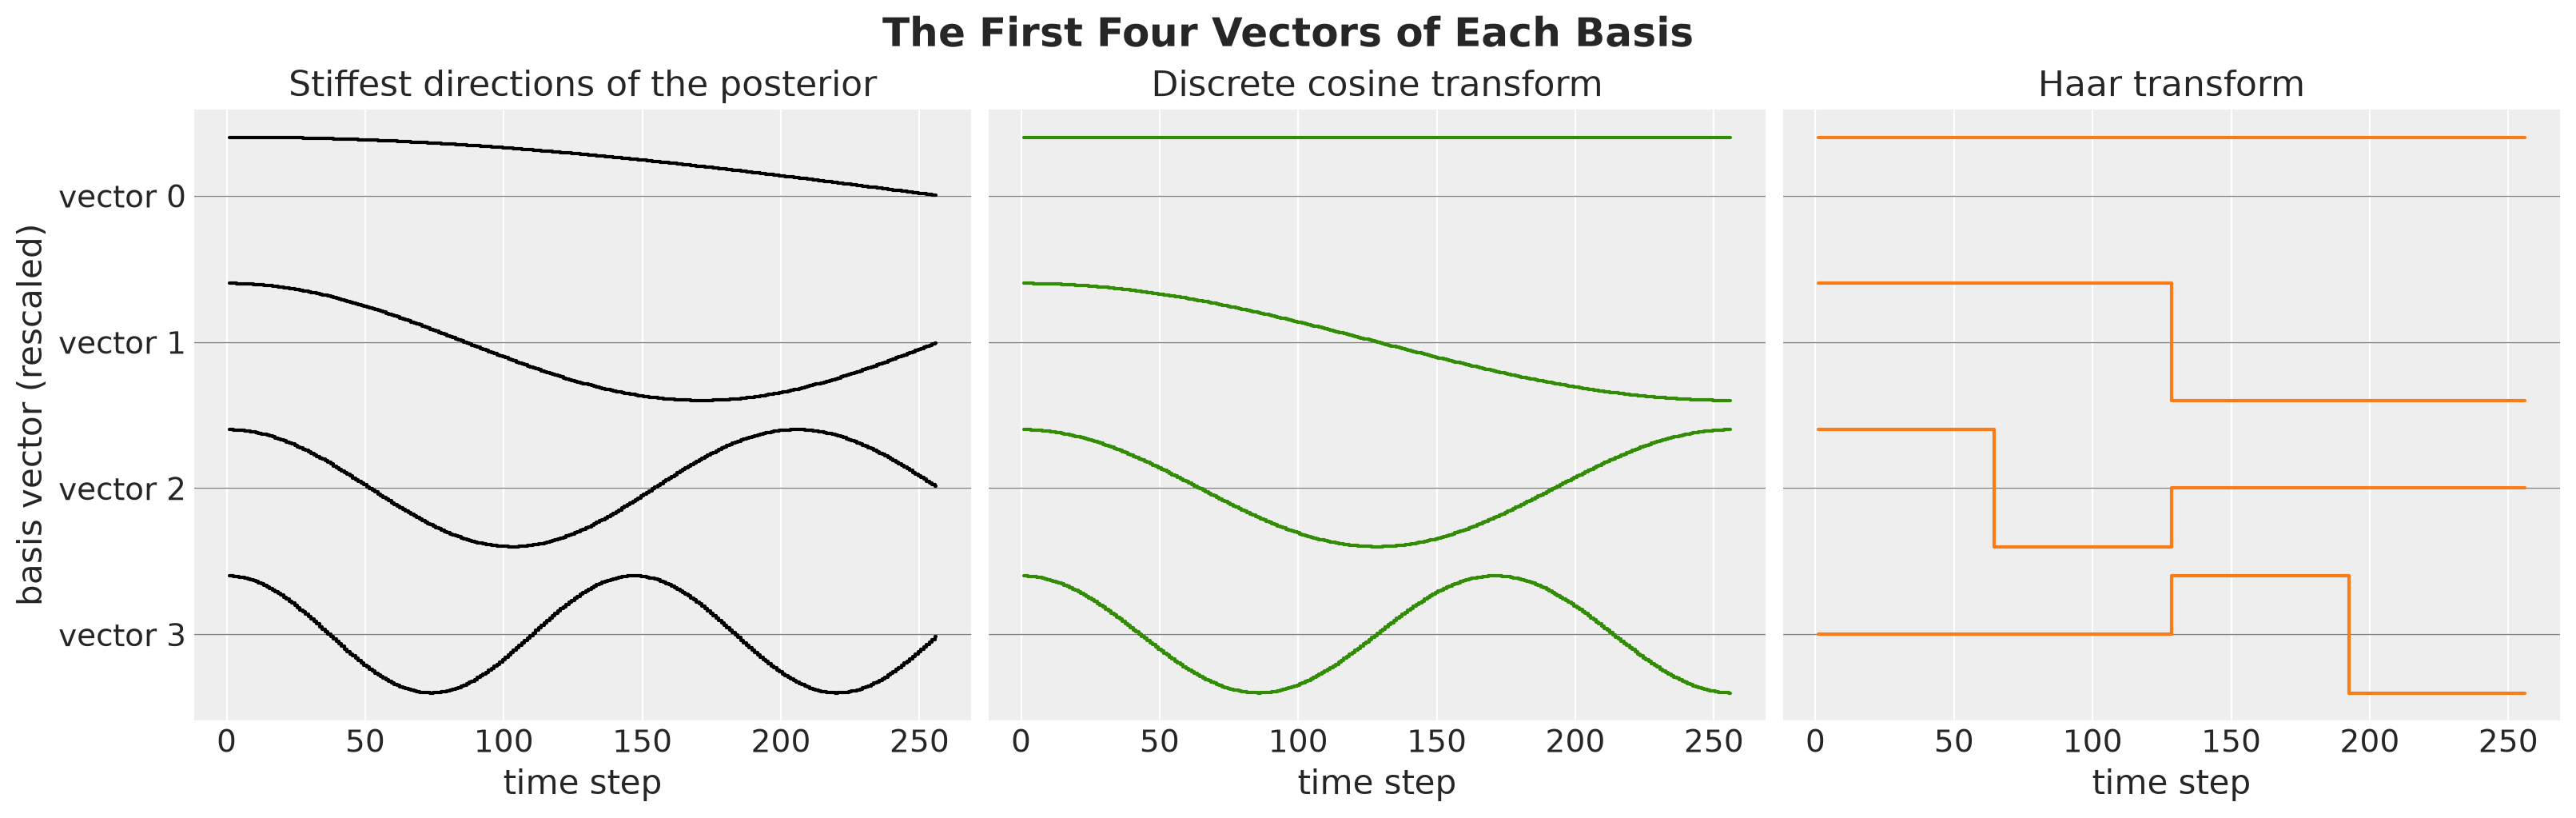

In [15]:
# One color per coordinate system, used in every figure.
COLORS = {"none": "C0", "haar": "C1", "dct": "C2"}

ratio_grid = jnp.logspace(-2, jnp.log10(3.0), 26)


panels = {
    "Stiffest directions of the posterior": (eigenvectors.T, "black"),
    "Discrete cosine transform": (rotations["dct"], COLORS["dct"]),
    "Haar transform": (rotations["haar"], COLORS["haar"]),
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), sharey=True)

for ax, (title, (rows, color)) in zip(axes, panels.items(), strict=True):
    for i in range(4):
        strip = 0.4 * rows[i] / jnp.abs(rows[i]).max() - i
        ax.axhline(-i, color="gray", linewidth=0.5)
        ax.plot(toy_time, strip, color=color, drawstyle="steps-mid")

    ax.set(xlabel="time step", title=title, yticks=[0, -1, -2, -3])
    ax.set_yticklabels([f"vector {i}" for i in range(4)])

axes[0].set(ylabel="basis vector (rescaled)")
fig.suptitle("The First Four Vectors of Each Basis", fontsize=18, fontweight="bold");

Each strip is one basis vector as a function of time, and the thin gray line is zero. The left panel is the target, and the other two are the fixed bases.

- **The DCT rows resemble the true axes.** They are cosines of increasing frequency, like the eigenvectors $v_k$. They are not the same: the eigenvectors have half-integer frequencies and go to zero at the right end, while the DCT rows have integer frequencies.
- **The Haar rows are a blocky version of the same idea.** Vector $0$ is the average, vector $1$ compares the two halves, and vectors $2$ and $3$ compare the quarters inside each half.
- **Both bases sort the coordinates from coarse to fine.** The first coordinates are the smooth, stiff directions and the last ones are the oscillating, loose directions.

**Remark (exact bases):** The eigenvectors $v_k$ are the rows of another member of the family, the DCT of type VIII. The DCT of type II is exact for a different parameterization. If we sample the levels $\mu_t$ instead of the increments and give the first level a flat prior, the posterior precision is $\sigma_\varepsilon^{-2} I$ plus $\sigma_\eta^{-2}$ times a second-difference matrix with free ends. The DCT of type II diagonalizes this matrix ([Strang, 1999](https://epubs.siam.org/doi/10.1137/S0036144598336745)). For the increments the match is approximate, and the next section measures how good it is.

## Mean-Field Gap

Now we quantify what a mean-field guide loses in each basis. Let's first recall the two quantities that variational inference works with.

Variational inference replaces the posterior $\text{P}(z \mid y)$ with the closest member $q$ of a simpler family of distributions, the guide. It measures the distance with the Kullback-Leibler (KL) divergence,

$$
\text{KL}\left(q \,\|\, \text{P}(z \mid y)\right) = \text{E}_{q}\left[\log q(z) - \log \text{P}(z \mid y)\right] .
$$

The KL divergence is the expected log ratio between the guide and the posterior, under the guide. It is never negative, and it is zero only when $q$ equals the posterior. With the natural logarithm we measure it in *nats*.

Here is the intuition behind the direction of the KL divergence. The expectation is under $q$, so the guide pays a large penalty where it puts mass and the posterior does not. As a result, when the guide $q$ cannot match the true shape of the posterior, it tends to concentrate its mass in regions where the posterior has support and avoids placing mass where the posterior is low or zero. In effect, the guide "stays inside" the high-probability regions of the posterior. This conservatism means the guide usually underestimates the uncertainty, because it does not spread out as much as the true posterior. Keep this in mind for the results below.

We cannot compute the KL divergence directly, because the posterior contains the unknown evidence $\text{P}(y)$. Instead, SVI maximizes the evidence lower bound (ELBO), which only needs the joint density $\text{P}(y, z)$ of the model:

$$
\text{ELBO}(q) = \text{E}_{q}\left[\log \text{P}(y, z) - \log q(z)\right] = \log \text{P}(y) - \text{KL}\left(q \,\|\, \text{P}(z \mid y)\right) .
$$

The log evidence does not depend on $q$, so maximizing the ELBO is the same as minimizing the KL divergence. Since the KL divergence is never negative, the ELBO is a lower bound on the log evidence, hence the name. For a detailed introduction see [PyData Berlin 2025: Introduction to Stochastic Variational Inference with NumPyro](https://juanitorduz.github.io/intro_svi/).



A mean-field Gaussian guide for $z$ is a product of independent Normal distributions,

$$
q(z) = \prod_{i = 1}^{T} \text{Normal}(z_i \mid m_i, s_i),
$$

with one location $m_i$ and one scale $s_i$ per coordinate. This is the family that `AutoNormal` fits.

The log evidence does not depend on the choice of basis (i.e., the coordinate system or set of axes we use to represent the variable $z$) either. Therefore, the smallest KL divergence that a mean-field guide can reach sets its best possible ELBO. We call that divergence the mean-field gap.

For a Gaussian posterior with precision $\Lambda_U$ we can minimize in closed form. The optimal locations are the entries of the posterior mean and the optimal scales are $s_i^2 = 1 / (\Lambda_U)_{ii}$. In other words, each factor of the guide gets the *conditional* variance of its coordinate, which is never larger than the marginal variance (see equation (10.12) in Section 10.1.2 of [Bishop (2006)](https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)). Let $\tilde{\Lambda}_U$ be the precision $\Lambda_U$ rescaled to have ones on the diagonal, which we call the normalized precision. The gap is

$$
\text{gap}(U) = \frac{1}{2} \left( \sum_{i = 1}^{T} \log (\Lambda_U)_{ii} - \log \det \Lambda \right) = - \frac{1}{2} \log \det \tilde{\Lambda}_U .
$$

Here is where the formula comes from. The guide and the posterior are both Gaussian, so their KL divergence has a closed form (see the [Wikipedia article on the multivariate normal distribution](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Kullback%E2%80%93Leibler_divergence)), which we write out in the Mean-Field Check section below. In that expression the locations only appear in a quadratic term, which is zero at the posterior mean, and the variances separate into one term $(\Lambda_U)_{ii}\, s_i^2 - \log s_i^2$ per coordinate.

Each of these terms is smallest at $s_i^2 = 1 / (\Lambda_U)_{ii}$, where it equals $1 + \log (\Lambda_U)_{ii}$. Summing over the coordinates gives $\text{gap}(U)$.

We make two remarks:

- **The gap is zero only for a diagonal precision.** This is [Hadamard's inequality](https://en.wikipedia.org/wiki/Hadamard%27s_inequality): the determinant of a positive definite matrix is at most the product of its diagonal entries, with equality only for a diagonal matrix.
- **Only the first term depends on the basis.** The determinant of $\Lambda$ is invariant under rotations. A good basis is one where the product of the diagonal entries of $\Lambda_U$ is small, that is, where the off-diagonal entries of the normalized precision are close to zero.

Let's compute the gap for the three coordinate systems. We plot the normalized precision matrices (top row) and a zoom on their first $16$ coordinates (bottom row). White is zero, which means no coupling, and the diagonal is $1$ by construction.

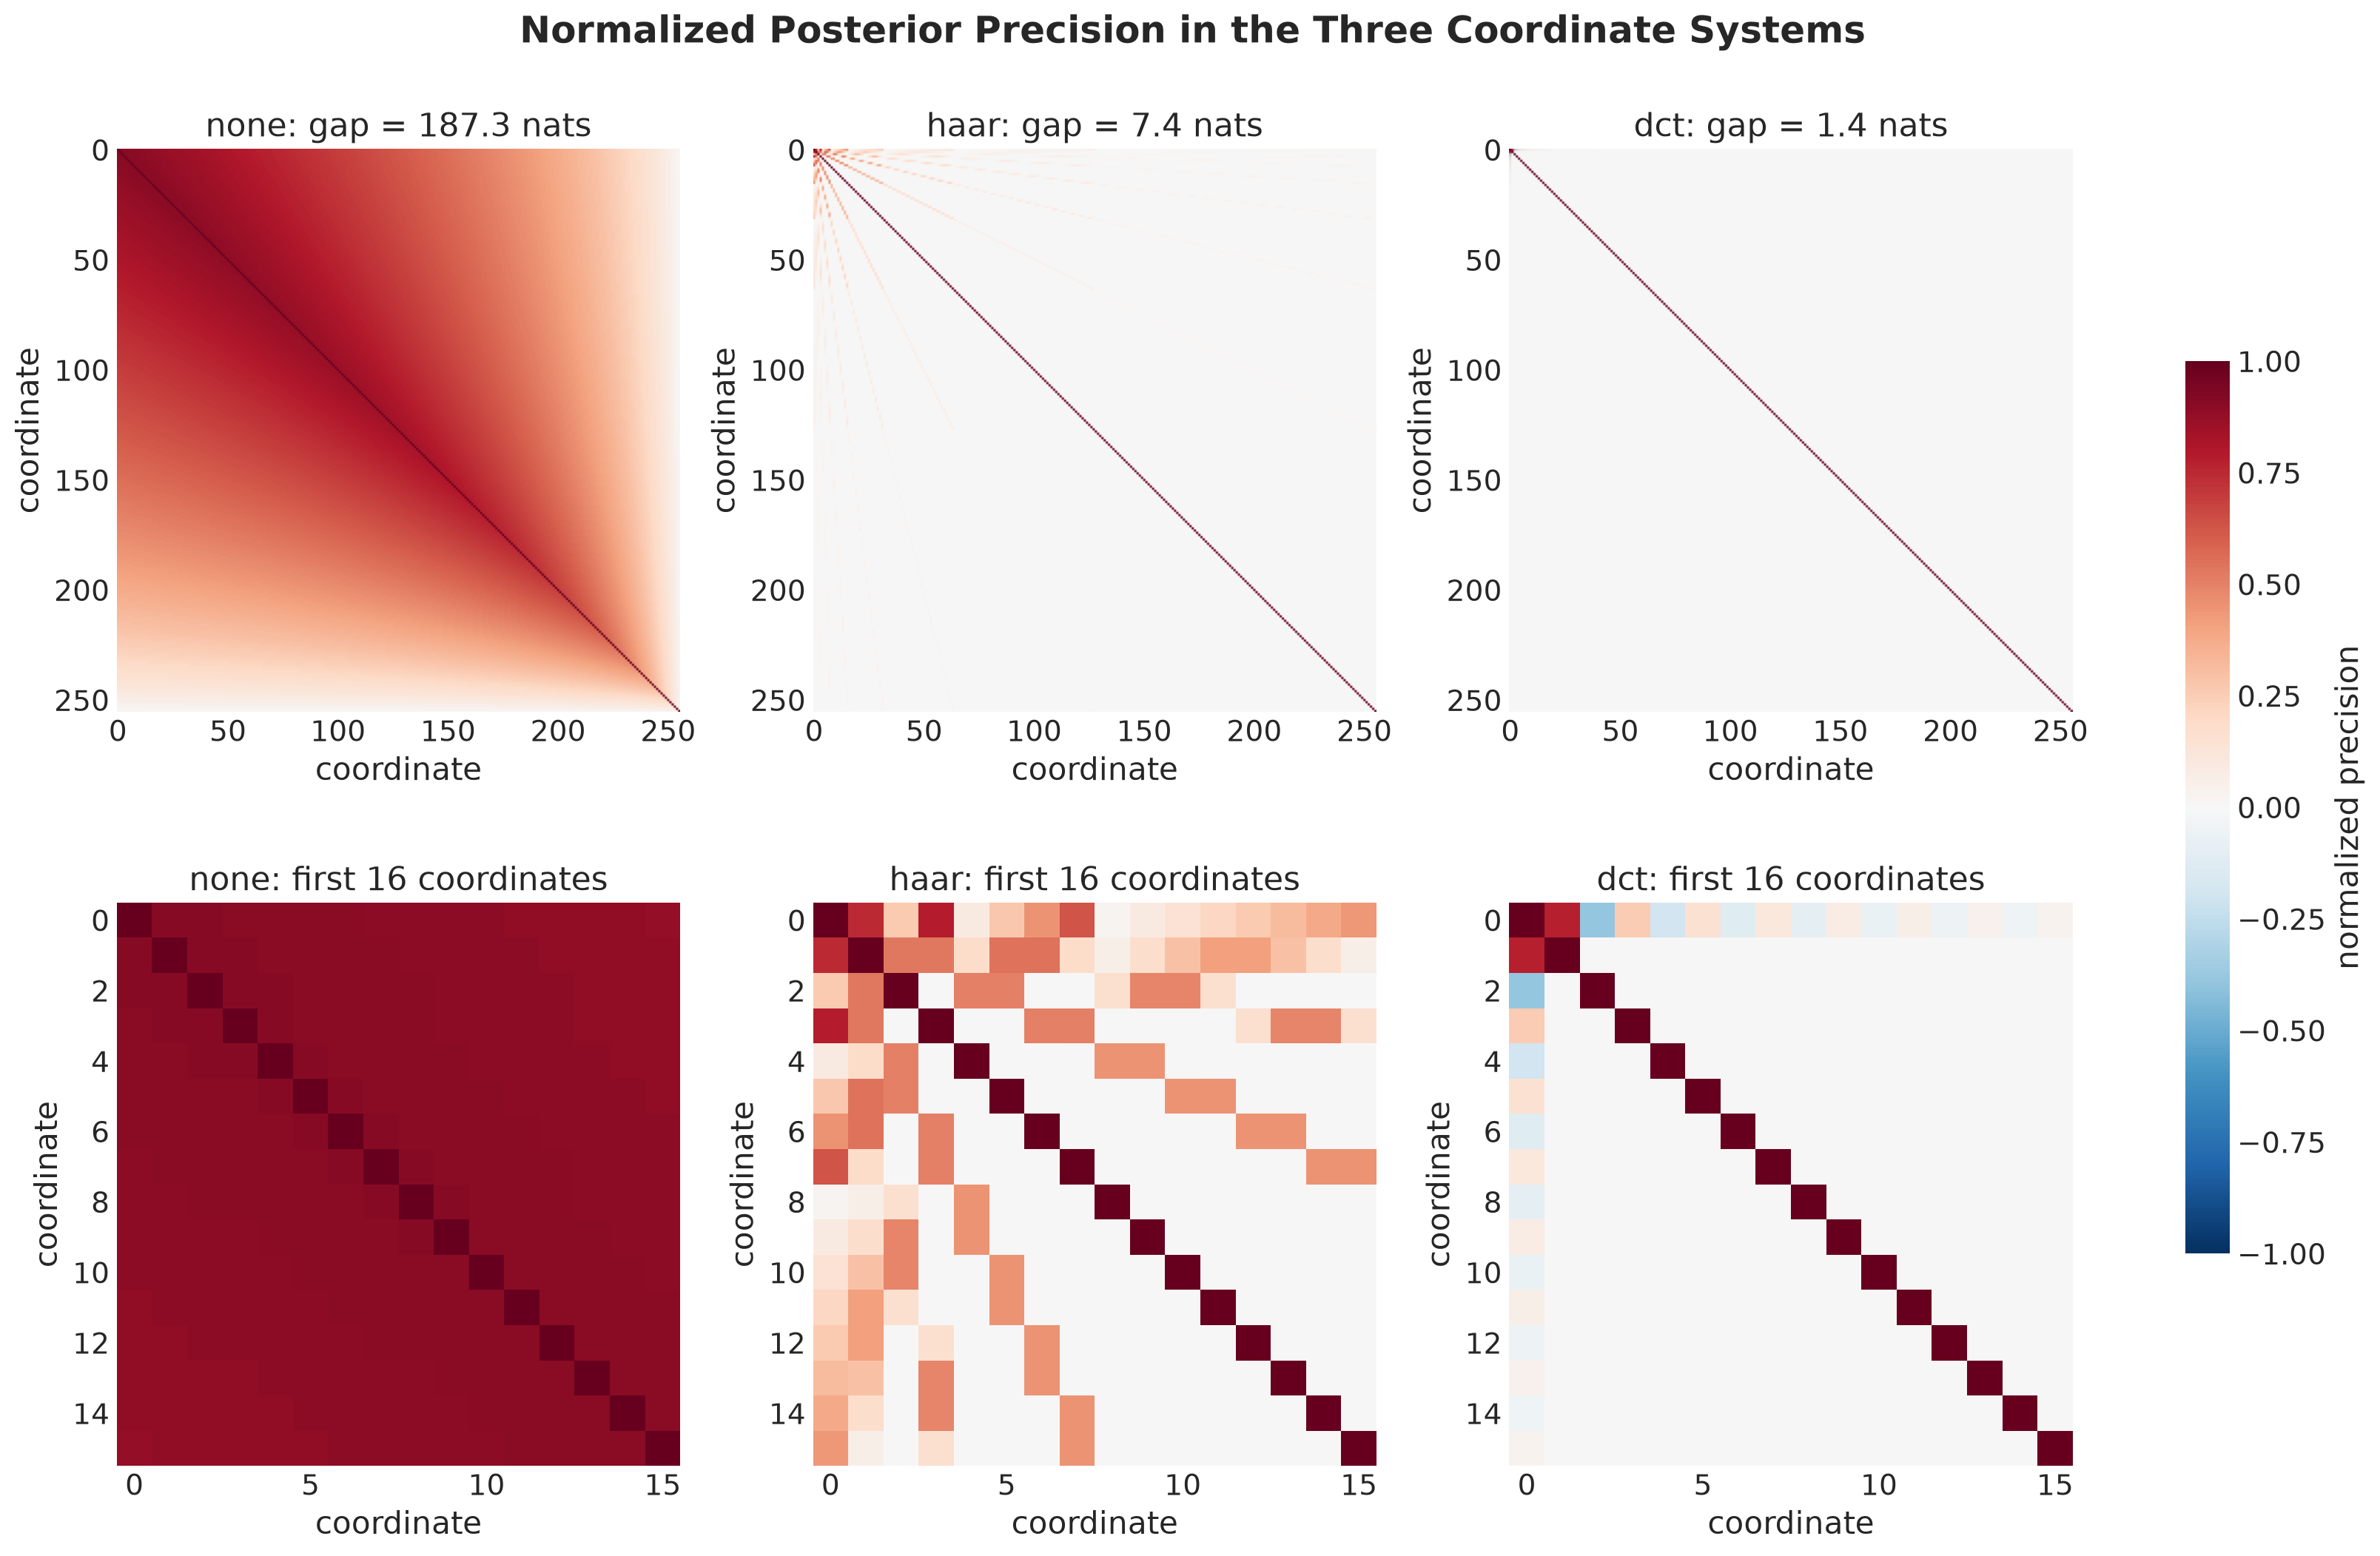

In [16]:
def normalize(matrix: Float[Array, "t t"]) -> Float[Array, "t t"]:
    "Rescale a positive definite matrix to have ones on the diagonal."
    scale = jnp.sqrt(jnp.diag(matrix))
    return matrix / jnp.outer(scale, scale)


def mean_field_gap(
    precision: Float[Array, "t t"], rotation: Float[Array, "t t"]
) -> Float[Array, ""]:
    "KL divergence of the best mean-field Gaussian relative to the posterior, in nats."

    rotated = rotation @ precision @ rotation.T
    return 0.5 * (jnp.log(jnp.diag(rotated)).sum() - jnp.linalg.slogdet(precision)[1])


gaps = {name: mean_field_gap(precision, u) for name, u in rotations.items()}

# In the eigenbasis the precision is diagonal and the gap is zero.
np.testing.assert_allclose(mean_field_gap(precision, eigenvectors.T), 0, atol=1e-8)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10.5))

for column, (name, u) in enumerate(rotations.items()):
    normalized = normalize(u @ precision @ u.T)

    for row, size in enumerate([T_TOY, 16]):
        ax = axes[row, column]
        image = ax.imshow(normalized[:size, :size], cmap="RdBu_r", vmin=-1, vmax=1)
        ax.grid(visible=False)
        ax.set(xlabel="coordinate", ylabel="coordinate")

    axes[0, column].set(title=f"{name}: gap = {float(gaps[name]):.1f} nats")
    axes[1, column].set(title=f"{name}: first 16 coordinates")

fig.colorbar(image, ax=axes, shrink=0.6, label="normalized precision")
fig.suptitle(
    "Normalized Posterior Precision in the Three Coordinate Systems",
    fontsize=18,
    fontweight="bold",
);

Each column is the same posterior in one coordinate system, and the title gives the mean-field gap.

- **In the original coordinates every pair is coupled.** The matrix is dense, and the gap is $187.3$ nats. A mean-field guide is very far from this posterior.
- **The Haar basis leaves few entries.** Only about $1\%$ of the off-diagonal entries are larger than $0.05$, and the gap drops to $7.4$ nats.
- **The DCT leaves even fewer.** The gap is $1.4$ nats, which is less than $1\%$ of the original gap.
- **The eigenbasis has zero gap.** It is the ideal that a fixed basis approximates, and the DCT is $1.4$ nats away from it without any knowledge of the scales.
- **The entries that remain are large.** The zoom shows entries up to about $0.8$ among the coarsest coefficients. For the DCT they are all in the first row: the coefficient $z_0$, the average increment, is still coupled to the others. A small gap is a global statement. It does not say that every coordinate is well approximated, and we will see the consequence for the level.

Next, we check that this result is not specific to $\rho = 0.2$. We compute the gap on a grid of scale ratios.

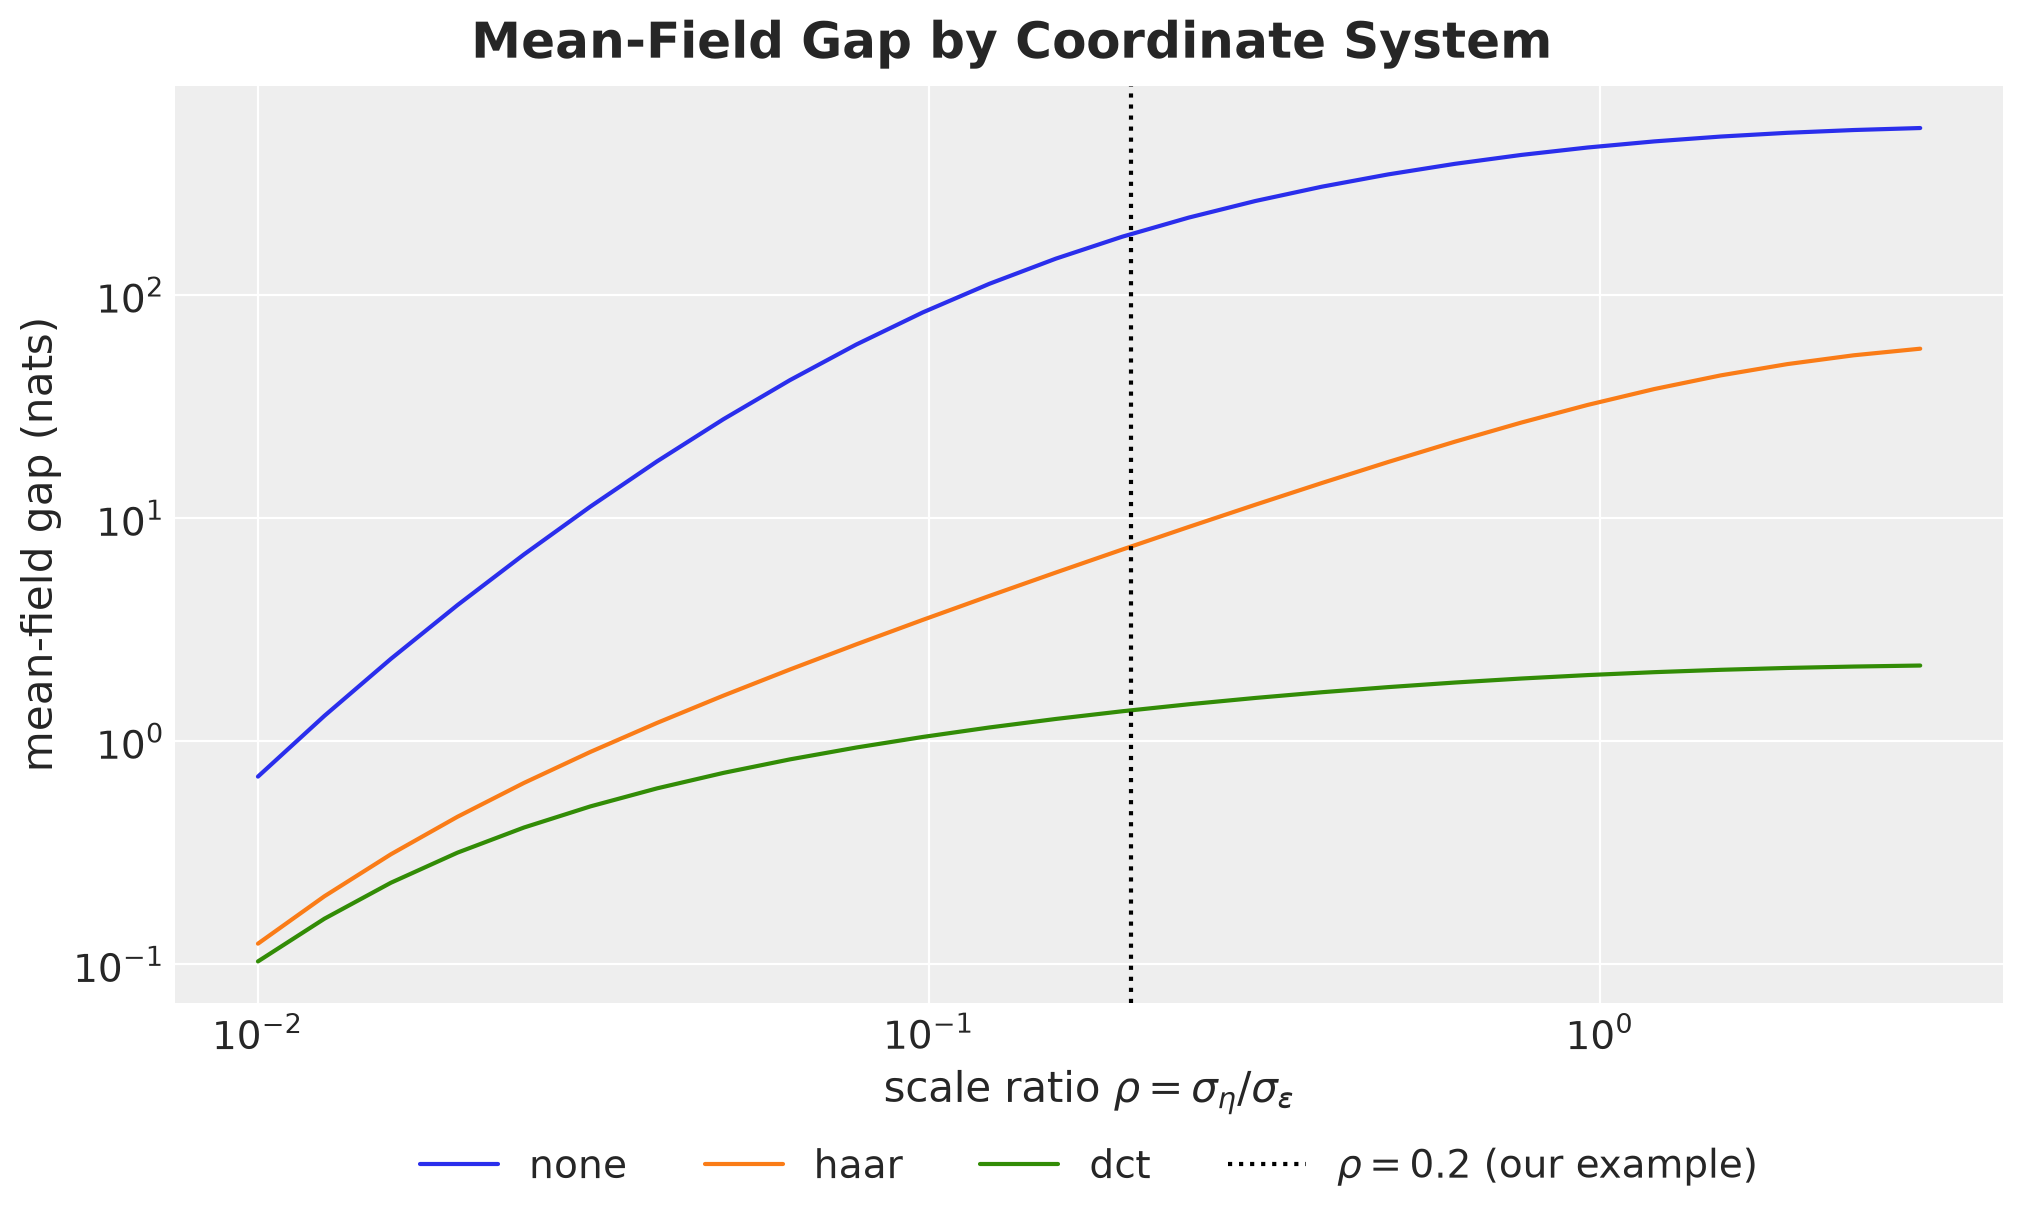

In [17]:
def gap_by_ratio(rotation: Float[Array, "t t"]) -> Float[Array, " r"]:
    "Mean-field gap in a coordinate system, on the grid of scale ratios."
    return jax.vmap(
        lambda rho: mean_field_gap(posterior_precision(T_TOY, rho, 1.0), rotation)
    )(ratio_grid)


gap_grid = {name: gap_by_ratio(u) for name, u in rotations.items()}

fig, ax = plt.subplots()

for name, values in gap_grid.items():
    ax.plot(ratio_grid, values, color=COLORS[name], label=name)

ax.axvline(
    DRIFT_SCALE / SIGMA,
    color="black",
    linestyle=":",
    label="$\\rho = 0.2$ (our example)",
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel="scale ratio $\\rho = \\sigma_\\eta / \\sigma_\\varepsilon$",
    ylabel="mean-field gap (nats)",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
fig.suptitle("Mean-Field Gap by Coordinate System", fontsize=18, fontweight="bold");

The figure shows the gap of the best mean-field guide as a function of the scale ratio, on logarithmic axes.

- **The ranking is the same everywhere.** The original coordinates are the worst for every $\rho$, and both rotations help.
- **The gain grows with the scale ratio.** For a very small $\rho$ the posterior is close to the prior and every coordinate system is fine. For $\rho \ge 0.1$ the original gap is in the tens or hundreds of nats, while the DCT gap stays below $3$ nats.
- **The DCT has a smaller gap than Haar for this model.** The true axes are cosines, and the DCT rows are cosines too.

### Uncertainty of the Level

What does the gap mean for the quantity we forecast from, the level? The optimal mean-field guide has covariance $U^\top \text{diag}(1 / (\Lambda_U)_{ii})\, U$ for the increments. We push it through the cumulative sum and compare the standard deviation of the level with the exact one.

We can anticipate two features of the result:

- **In the original coordinates the variance accumulates.** The guide treats the increments as independent, with variances $1 / \Lambda_{ii} = 1 / (\sigma_\eta^{-2} + (T + 1 - i)\, \sigma_\varepsilon^{-2})$. The variance of the level is their sum, which is approximately $\sigma_\varepsilon^2 \log\left(a / (a - t)\right)$ with $a = T + 1/2 + \rho^{-2}$. It keeps growing with $t$, and faster toward the end.
- **With a constant first row the last level depends on one coefficient.** For the DCT, and for the Haar basis when $T$ is a power of two, every row except the first sums to zero. The last level is therefore $\mu_T = \sqrt{T}\, z_0$. The guide gives $z_0$ the variance $1 / (\Lambda_U)_{00}$, and the standard deviation of $\mu_T$ is approximately $\sigma_\varepsilon \sqrt{3 / T}$, which is too small.

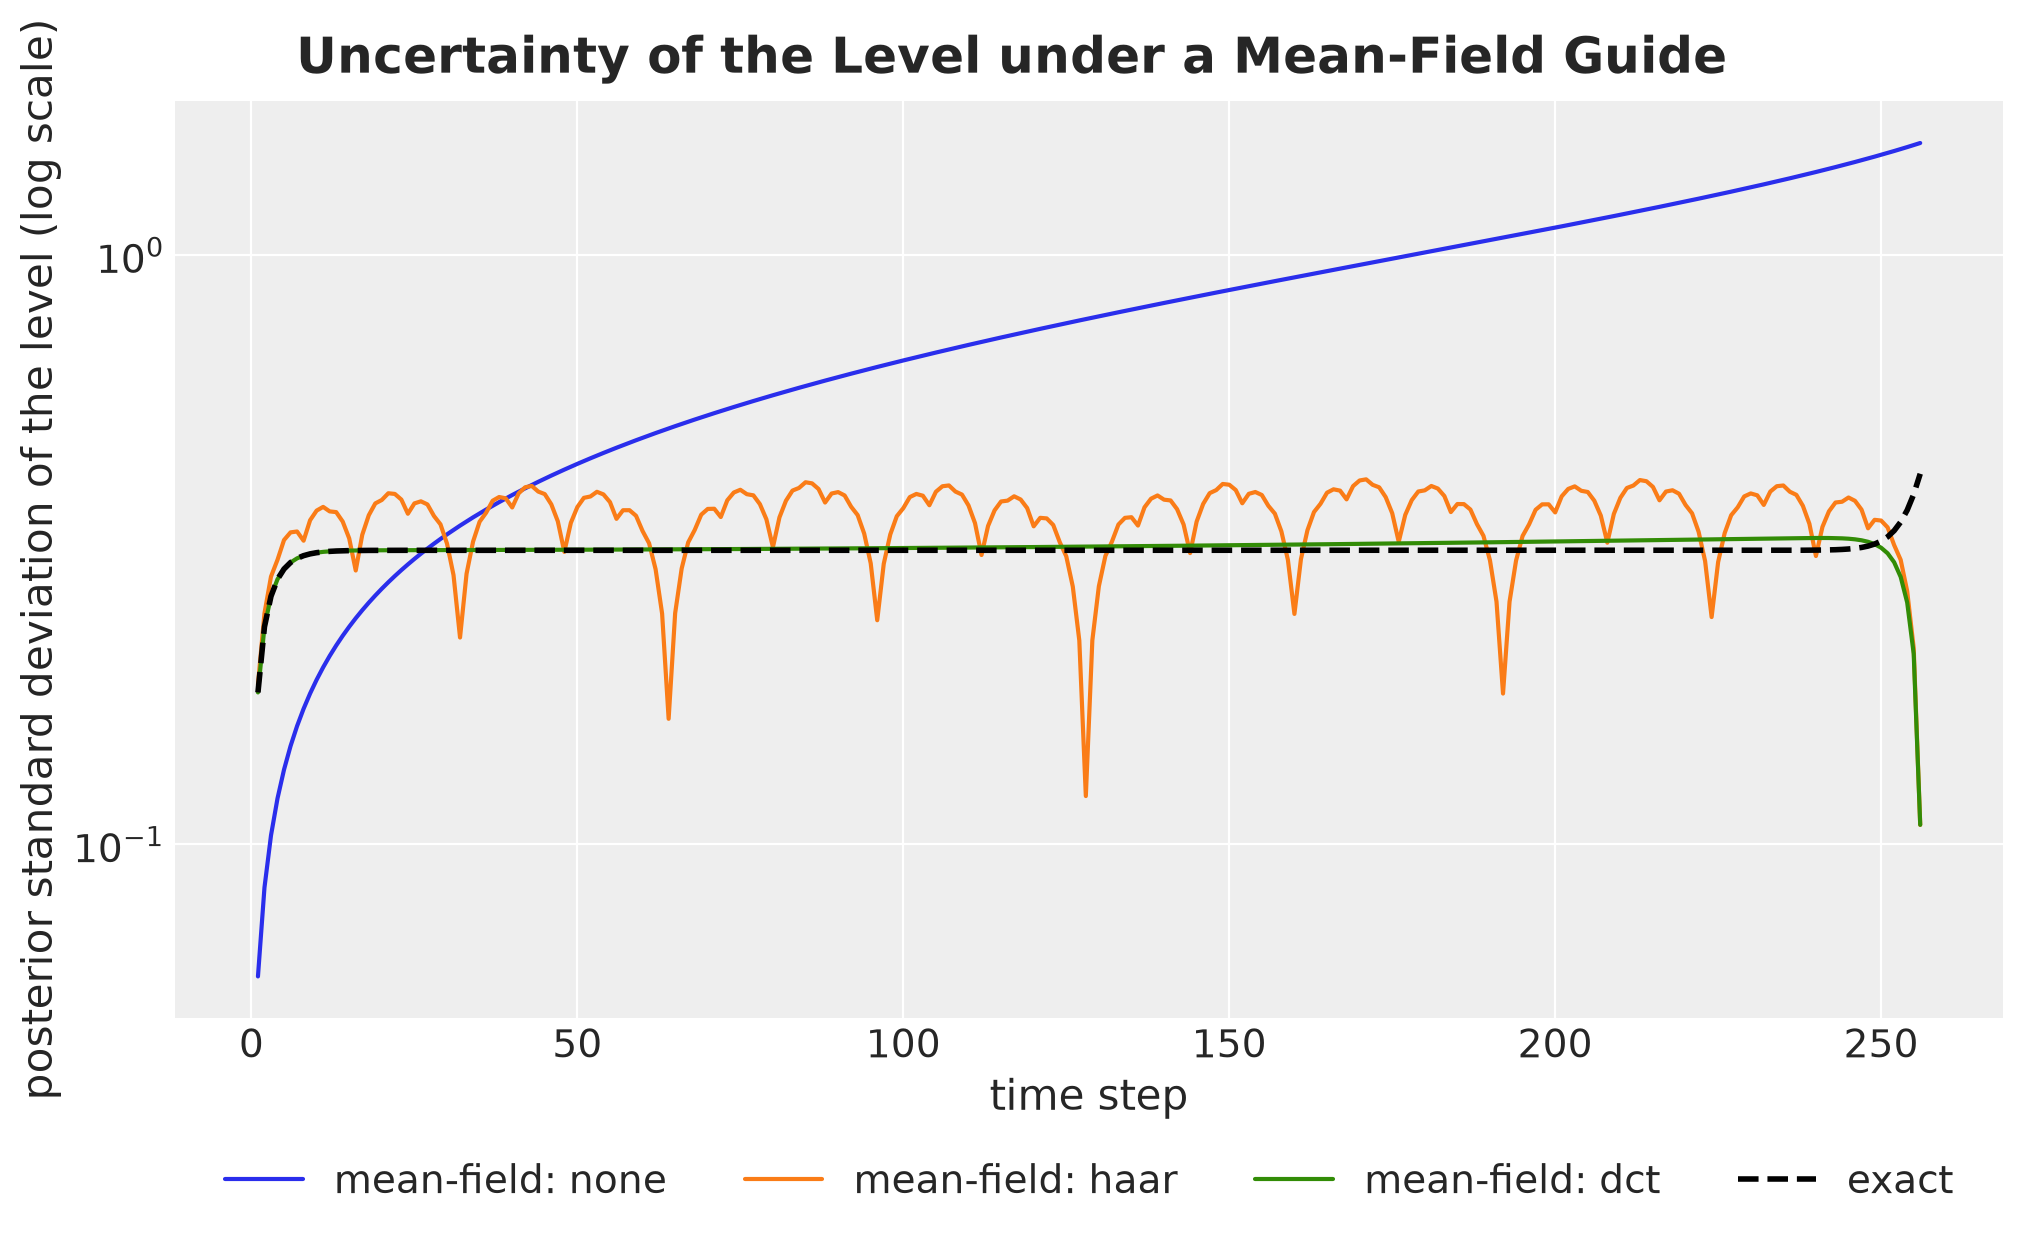

In [18]:
def mean_field_covariance(
    precision: Float[Array, "t t"], rotation: Float[Array, "t t"]
) -> Float[Array, "t t"]:
    "Covariance of the increments under the best mean-field Gaussian."
    rotated = rotation @ precision @ rotation.T
    return rotation.T @ jnp.diag(1 / jnp.diag(rotated)) @ rotation


mean_field_level_sd = {
    name: jnp.sqrt(
        jnp.diag(cumsum_matrix @ mean_field_covariance(precision, u) @ cumsum_matrix.T)
    )
    for name, u in rotations.items()
}

# The two approximations of the text.
offset = T_TOY + 0.5 + (SIGMA / DRIFT_SCALE) ** 2
log_formula = SIGMA * jnp.sqrt(jnp.log(offset / (offset - toy_time)))
np.testing.assert_allclose(mean_field_level_sd["none"], log_formula, rtol=0.01)

for name in ["haar", "dct"]:
    np.testing.assert_allclose(
        mean_field_level_sd[name][-1], SIGMA * jnp.sqrt(3 / T_TOY), rtol=0.01
    )

fig, ax = plt.subplots()

for name, values in mean_field_level_sd.items():
    ax.plot(toy_time, values, color=COLORS[name], label=f"mean-field: {name}")

ax.plot(toy_time, level_sd, color="black", linestyle="--", linewidth=2, label="exact")
ax.set(
    yscale="log",
    xlabel="time step",
    ylabel="posterior standard deviation of the level (log scale)",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
fig.suptitle(
    "Uncertainty of the Level under a Mean-Field Guide", fontsize=18, fontweight="bold"
);

The dashed black line is the exact posterior standard deviation of the level. The colored lines are the standard deviations under the best mean-field guide in each coordinate system. The assertions in the cell check the two approximations.

- **In the original coordinates the shape is wrong.** The guide is too narrow in the first tenth of the series and too wide after that, up to $4.5$ times near the end and $3.6$ times at the last time step. It cannot express that the data constrain the level with the same precision at every time step.
- **The DCT guide is within $5\%$ of the exact value, except at the end.** In the last six time steps it is more than $5\%$ too narrow, and at the last one by a factor of $3.9$.
- **The Haar guide is about $13\%$ too wide on average, with dips.** The dips are at the ends of the Haar blocks, where the level depends on a few coarse coefficients. The deepest one is at the last time step, with the same value as the DCT.

The dips and the collapse at the end have the same cause. A mean-field guide gives each coefficient its *conditional* variance, which is too small for the coarse coefficients because they are strongly coupled to each other.

The last time step matters, because a forecast starts from the last level, the forecast origin. At that point the rotated guides are as wrong as the original one, in the opposite direction. The rotation is a large improvement of the fit as a whole and not a complete fix.

### Unknown Scales

With fixed scales, a bad coordinate system gives a wrong uncertainty. When the scales are parameters, the optimizer has a second option: it can change the scales to make the bound tighter. [Turner and Sahani (2011)](https://www.semanticscholar.org/paper/Two-problems-with-variational-expectation-for-Turner-Sahani/aaca093827e826a1118a4d2a93b0e42a09308be7) study this bias of variational methods in time series models.

We can compute this effect exactly for point estimates of the scales. The best ELBO as a function of the scales is the log marginal likelihood minus the gap,

$$
\log \text{P}(y \mid \sigma_\eta, \sigma_\varepsilon) - \text{gap}_U(\sigma_\eta, \sigma_\varepsilon) ,
$$

and the gap grows with $\rho$. The gap therefore acts as a penalty on $\sigma_\eta / \sigma_\varepsilon$. Let's maximize this function in each coordinate system and compare the result with the maximum of the marginal likelihood alone.

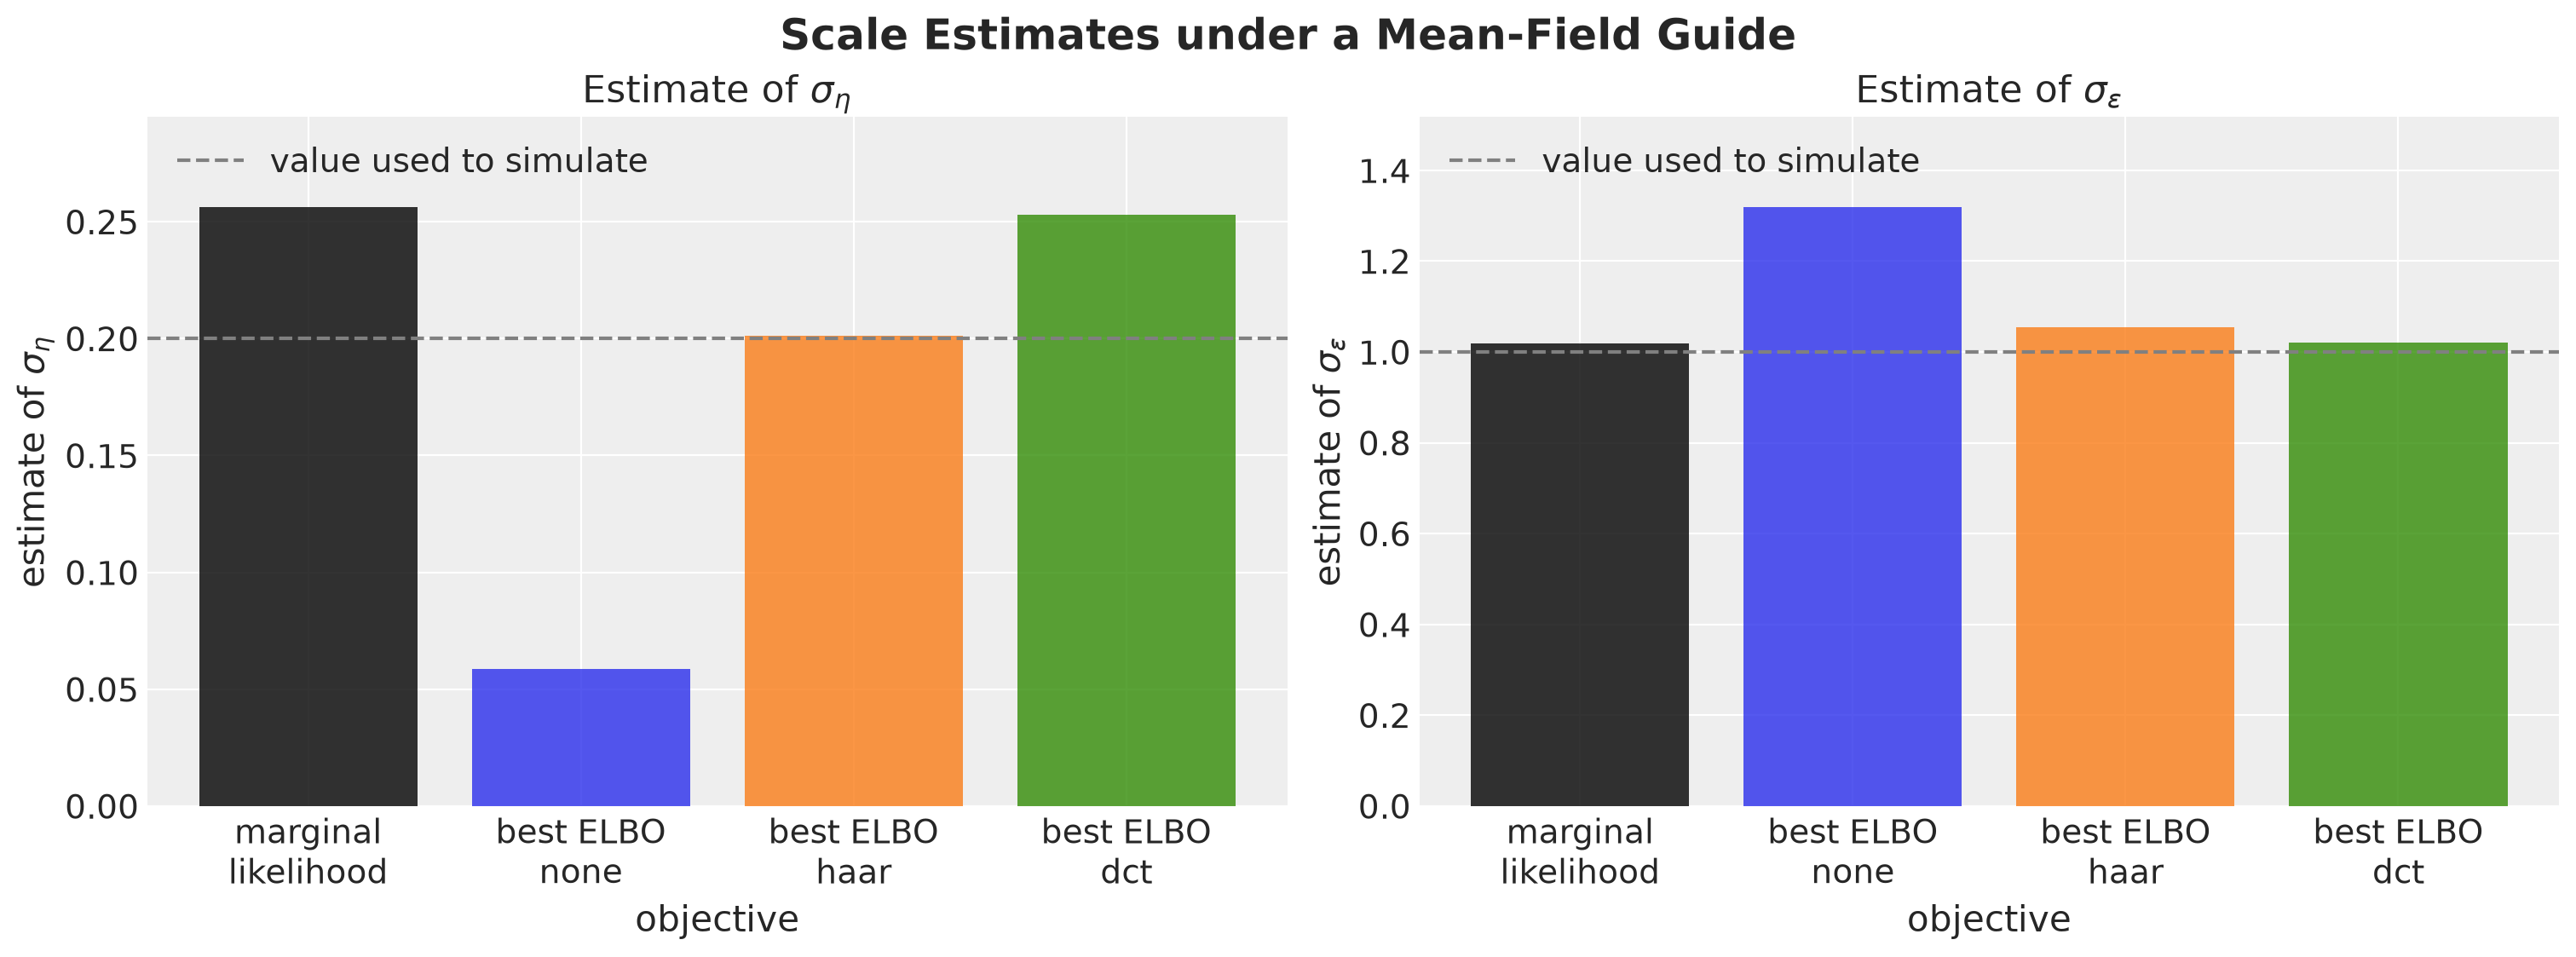

In [19]:
def log_marginal_likelihood(
    drift_scale: ScalarLike, sigma: ScalarLike
) -> Float[Array, ""]:
    "Log density of the observations, with the increments integrated out."
    y_covariance = drift_scale**2 * cumsum_matrix @ cumsum_matrix.T
    y_covariance += sigma**2 * jnp.eye(T_TOY)
    quadratic = toy_y @ jnp.linalg.solve(y_covariance, toy_y)
    log_det = jnp.linalg.slogdet(y_covariance)[1]
    return -0.5 * (T_TOY * jnp.log(2 * jnp.pi) + log_det + quadratic)


def best_scales(rotation: Float[Array, "t t"] | None) -> Float[Array, " 2"]:
    "Scales that maximize the marginal likelihood minus the mean-field gap."

    def objective(log_scales: Float[np.ndarray, " 2"]) -> float:
        drift_scale, sigma = jnp.exp(jnp.asarray(log_scales))
        value = log_marginal_likelihood(drift_scale, sigma)
        if rotation is not None:
            value -= mean_field_gap(
                posterior_precision(T_TOY, drift_scale, sigma), rotation
            )
        return -float(value)

    result = minimize(objective, np.log([DRIFT_SCALE, SIGMA]), method="Nelder-Mead")
    return jnp.exp(result.x)


scale_estimates = {"marginal likelihood": best_scales(None)} | {
    name: best_scales(u) for name, u in rotations.items()
}

objective_labels = ["marginal\nlikelihood"] + [f"best ELBO\n{name}" for name in COLORS]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5))

for i, (ax, symbol, truth) in enumerate(
    zip(
        axes,
        ["\\sigma_\\eta", "\\sigma_\\varepsilon"],
        [DRIFT_SCALE, SIGMA],
        strict=True,
    )
):
    estimates = [float(estimate[i]) for estimate in scale_estimates.values()]
    ax.bar(
        range(len(scale_estimates)),
        estimates,
        color=["black", *COLORS.values()],
        alpha=0.8,
    )
    ax.axhline(truth, color="gray", linestyle="--", label="value used to simulate")
    ax.set_xticks(range(len(scale_estimates)), labels=objective_labels)
    ax.set(
        xlabel="objective",
        ylabel=f"estimate of ${symbol}$",
        title=f"Estimate of ${symbol}$",
        ylim=(0, 1.15 * max(estimates)),
    )
    ax.legend(loc="upper left")

fig.suptitle(
    "Scale Estimates under a Mean-Field Guide", fontsize=18, fontweight="bold"
);

The black bar maximizes the marginal likelihood, which is the answer without any approximation of the posterior. The colored bars maximize the best ELBO of a mean-field guide in each coordinate system. The dashed line is the value we used to simulate the data.

- **In the original coordinates the level is shrunk.** Compared with the maximum of the marginal likelihood, the estimate of $\sigma_\eta$ is about four times too small, and the estimate of $\sigma_\varepsilon$ is about $30\%$ too large. The guide prefers a level that moves less, and it explains the rest as noise.
- **The rotations remove most of the bias.** With the Haar basis $\sigma_\eta$ is about $20\%$ too small, and with the DCT both estimates are within $2\%$ of the marginal likelihood.

We will see the same pattern in the ridership example.

**Remark (other guides):** A full-rank Gaussian guide removes the dependence on the basis, at the price of $O(T^2)$ parameters. Low-rank guides are in between. The rotation has no parameters and costs $O(T \log T)$ operations or less.

**Remark (the `smooth` parameter):** `DiscreteCosineTransform` has a parameter `smooth` that multiplies each coefficient by a fixed weight. A fixed diagonal rescaling does not change the best mean-field gap, because a mean-field guide absorbs it. It only changes the starting point and the path of the optimizer.

## Local Level Experiments

We now check the derivation of the mean-field gap on the local level model with a fitted guide.

First, we need the model in the three coordinate systems. NumPyro implements the two rotations as the reparameterizers `HaarReparam` and `DiscreteCosineReparam` (see the [NumPyro documentation](https://num.pyro.ai/en/stable/reparam.html)). The effect handler `handlers.reparam` applies a reparameterizer to the sites we name, without changes to the model code.

The reparameterizer replaces the latent site `drift` with a new latent site, `drift_haar` or `drift_dct`, which holds the coefficients $z = U \eta$. The site `drift` becomes a deterministic function of the new site. Let's create the three versions of the conditioned model.

In [20]:
Model = Callable[..., None]

toy_models: dict[str, Model] = {
    "none": toy_model,
    "haar": handlers.reparam(toy_model, config={"drift": HaarReparam(dim=-1)}),
    "dct": handlers.reparam(toy_model, config={"drift": DiscreteCosineReparam(dim=-1)}),
}

We can visualize the three models:

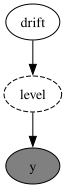

In [21]:
numpyro.render_model(toy_models["none"], model_args=toy_args, model_kwargs={})

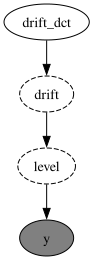

In [22]:
numpyro.render_model(toy_models["dct"], model_args=toy_args, model_kwargs={})

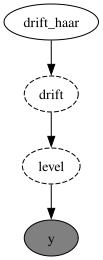

In [23]:
numpyro.render_model(toy_models["haar"], model_args=toy_args, model_kwargs={})

Let's check that the three versions define the same model: we evaluate the log joint density of the three models at the same point, written in each coordinate system.

In [24]:
log_joint, _ = log_density(toy_model, toy_args, {}, {"drift": toy_drift})

for name, transform in {
    "haar": HaarTransform(dim=-1),
    "dct": DiscreteCosineTransform(dim=-1),
}.items():
    log_joint_rotated, _ = log_density(
        toy_models[name],
        toy_args,
        {},
        {f"drift_{name}": transform(toy_drift)},
    )
    np.testing.assert_allclose(log_joint_rotated, log_joint, rtol=1e-5)

The three log densities agree. We have three coordinate systems for one model.

### Mean-Field Check

We fit an `AutoNormal` guide to each version of the model. The guide is a product of Normal distributions with locations $m$ and scales $s$, and the posterior of $z$ is a Gaussian with mean $U \bar{\eta}$ and precision $\Lambda_U$. The KL divergence between two Gaussians has a closed form (see the [Wikipedia article on the multivariate normal distribution](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Kullback%E2%80%93Leibler_divergence)), and for this pair it is

$$
\text{KL} = \frac{1}{2} \left( \sum_{i} (\Lambda_U)_{ii}\, s_i^2 + (m - U \bar{\eta})^\top \Lambda_U\, (m - U \bar{\eta}) - T - \log \det \Lambda - \sum_{i} \log s_i^2 \right) .
$$

This number cannot be smaller than the gap of the previous section, and it is equal to it only if the optimizer finds the optimum. We use a learning rate that decays from $0.02$ to $10^{-4}$, so that the optimizer noise does not hide gaps of a few nats.

In [25]:
def fit_toy_guide(
    rng_key: UInt[Array, "2"], model: Model, num_steps: int = 20_000
) -> dict[str, Array]:
    "Fit a mean-field guide to the local level model and return its parameters."
    guide = AutoNormal(model)
    optimizer = Adam(exponential_decay(0.02, num_steps, 0.005))
    svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=4))
    result = svi.run(rng_key, num_steps, *toy_args, progress_bar=False)
    return result.params


def fitted_gap(
    params: dict[str, Array], site: str, rotation: Float[Array, "t t"]
) -> Float[Array, ""]:
    "KL divergence of a fitted mean-field guide relative to the exact posterior."
    loc = params[f"{site}_auto_loc"]
    scale = params[f"{site}_auto_scale"]
    rotated = rotation @ precision @ rotation.T
    shift = loc - rotation @ drift_mean
    return 0.5 * (
        (jnp.diag(rotated) * scale**2).sum()
        + shift @ rotated @ shift
        - T_TOY
        - jnp.linalg.slogdet(precision)[1]
        - 2 * jnp.log(scale).sum()
    )


toy_sites = {"none": "drift", "haar": "drift_haar", "dct": "drift_dct"}

rng_key, rng_subkey = random.split(rng_key)
fitted_gaps = {
    name: fitted_gap(fit_toy_guide(rng_subkey, model), toy_sites[name], rotations[name])
    for name, model in toy_models.items()
}

We compare the gap of the fitted guides with the gap from the formula.

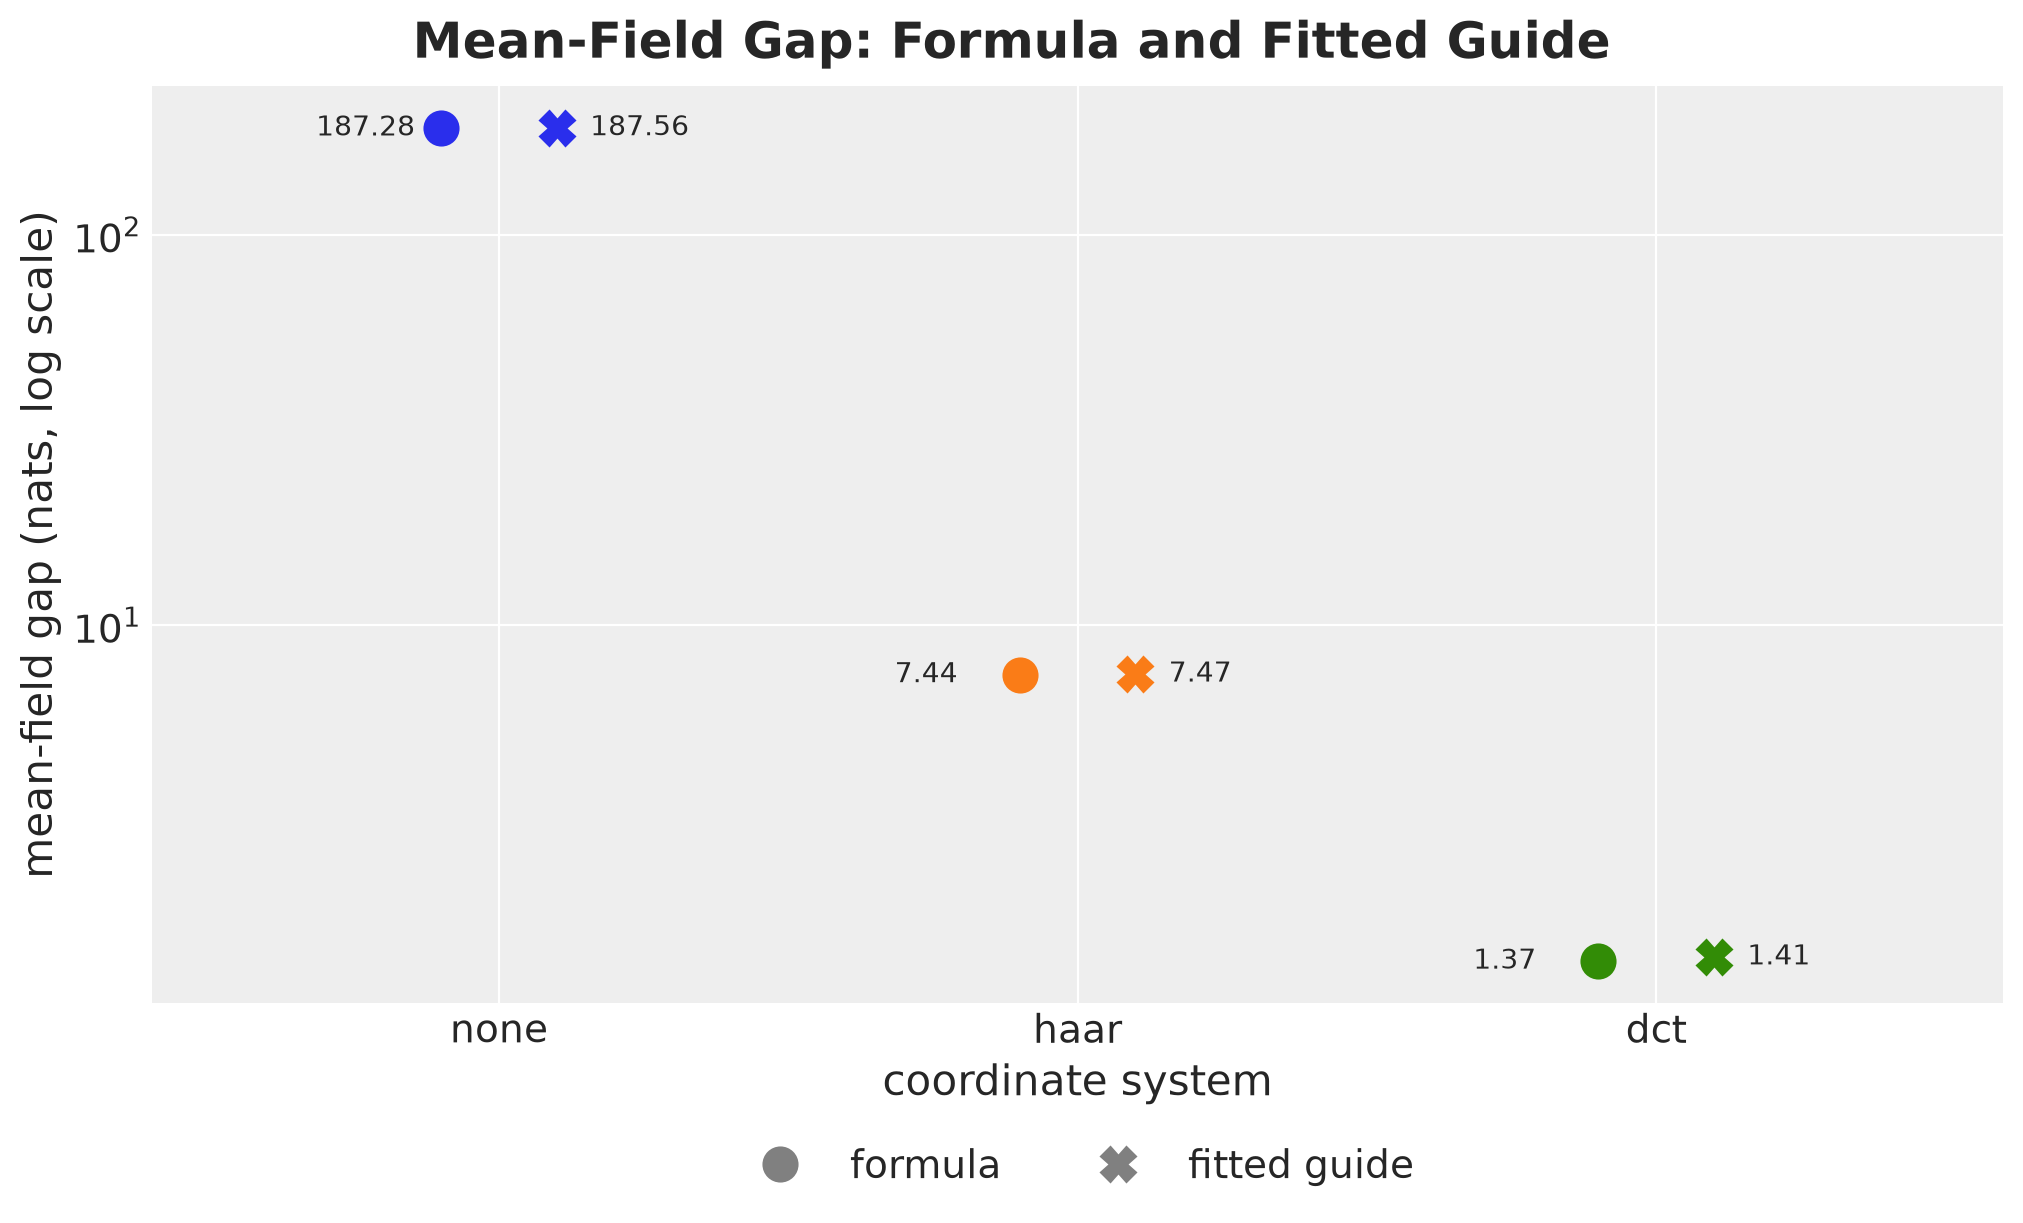

In [26]:
positions = jnp.arange(len(COLORS))
formula_gaps = [float(gaps[name]) for name in COLORS]
fitted = [float(fitted_gaps[name]) for name in COLORS]

fig, ax = plt.subplots()

for position, name in enumerate(COLORS):
    ax.plot(
        position - 0.1, formula_gaps[position], "o", color=COLORS[name], markersize=12
    )
    ax.plot(position + 0.1, fitted[position], "X", color=COLORS[name], markersize=12)

ax.plot([], [], "o", color="gray", markersize=12, label="formula")
ax.plot([], [], "X", color="gray", markersize=12, label="fitted guide")

for position, formula_gap, fitted_value in zip(
    positions, formula_gaps, fitted, strict=True
):
    ax.annotate(
        f"{formula_gap:.2f}",
        (position - 0.1, formula_gap),
        xytext=(-45, 0),
        textcoords="offset points",
        va="center",
    )
    ax.annotate(
        f"{fitted_value:.2f}",
        (position + 0.1, fitted_value),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
    )

ax.set(
    yscale="log",
    xticks=positions,
    xticklabels=list(COLORS),
    xlim=(-0.6, 2.6),
    xlabel="coordinate system",
    ylabel="mean-field gap (nats, log scale)",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
fig.suptitle(
    "Mean-Field Gap: Formula and Fitted Guide", fontsize=18, fontweight="bold"
);

For each coordinate system, the circle is the gap from the formula and the cross is the divergence of the fitted guide.

- **The fitted guides reach the predicted gap.** The two values agree in the three coordinate systems, and the fitted value is never below the formula.
- **The rotation improves the ELBO by $180$ nats with the Haar basis and $186$ nats with the DCT.**

The model, the guide family and the optimizer are the same in the three fits.

## Ridership Forecasting Model

Now we move to real data and to a model where nothing is exact. We use the example of the Pyro tutorial [Forecasting I: univariate, heavy tailed](https://pyro.ai/examples/forecasting_i.html), in the `numpyro_forecast` version of the [univariate forecasting example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html).

### Data

The data are the total weekly ridership of the BART train system, on the log scale. We hold out the last $52$ weeks as a test set. The seasonal features are a Fourier basis with $26$ harmonics of the yearly period.

We load the data, split it, and plot it.

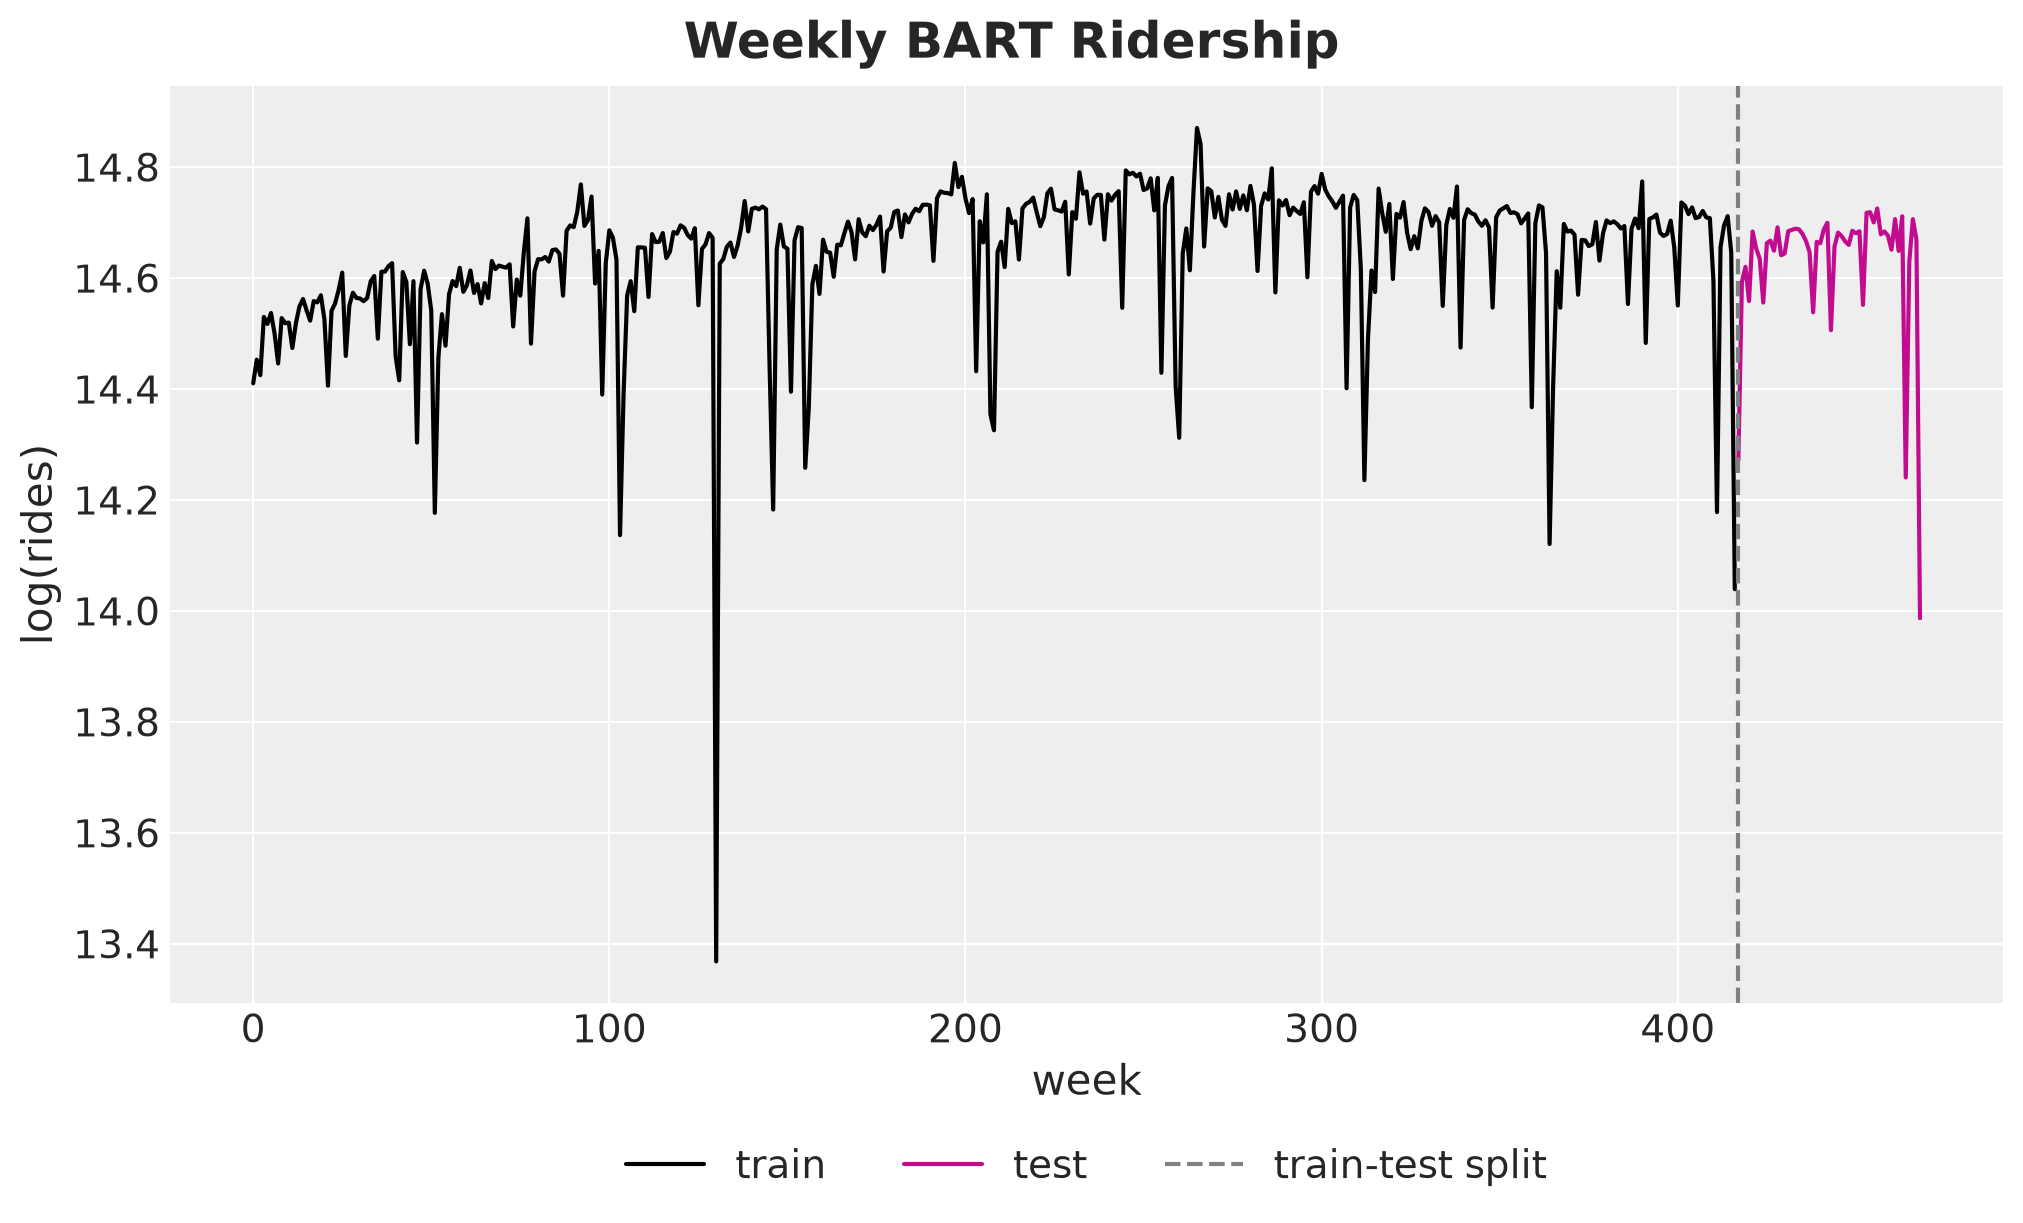

In [27]:
data = load_bart_weekly()
duration = data.shape[0]
t_train = duration - 52

y_train = data[:t_train]
y_test = data[t_train:]

covariates = fourier_features(duration, period=365.25 / 7, num_terms=26)
covariates_train = covariates[:t_train]

weeks = jnp.arange(duration)
weeks_train = weeks[:t_train]
weeks_test = weeks[t_train:]

fig, ax = plt.subplots()
ax.plot(weeks_train, y_train[:, 0], color="black", label="train")
ax.plot(weeks_test, y_test[:, 0], color="C3", label="test")
ax.axvline(t_train, color="gray", linestyle="--", label="train-test split")
ax.set(xlabel="week", ylabel="log(rides)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.suptitle("Weekly BART Ridership", fontsize=18, fontweight="bold");

The series has $417$ training weeks and $52$ test weeks.

- **The level moves slowly.** There is a trend that changes over the years, which is what the random-walk level has to capture.
- **There is a yearly pattern with sharp drops.** The drops are holiday weeks. This is the reason for a heavy-tailed likelihood.

### Model Specification

The model is a local level with a seasonal regression and Student-T noise. We keep the notation of the first part. Let $x_t$ be the vector of Fourier features of week $t$, $w$ the regression weights, $b$ a global intercept, and $\nu$ the degrees of freedom. The model is

\begin{align*}
y_t & = b + \mu_t + w^\top x_t + \varepsilon_t, & \varepsilon_t & \sim \text{StudentT}(\nu, 0, \sigma_\varepsilon), \\
\mu_t & = \mu_{t-1} + \eta_t, & \eta_t & \sim \text{Normal}(0, \sigma_\eta),
\end{align*}

with $\mu_0 = 0$. This is the local level model of the first part with three complications: the scales $\sigma_\eta$ and $\sigma_\varepsilon$ are unknown, the likelihood is not Gaussian, and there are an intercept and a regression.

We keep the priors and the site names of the Pyro tutorial: `bias` is $b$, `weight` is $w$, `drift_scale` is $\sigma_\eta$, `sigma` is $\sigma_\varepsilon$ and `nu` is $\nu$. The model follows the `numpyro_forecast` convention: it takes `(covariates, data)`, derives the forecast horizon with `Horizon.from_data`, samples the increments with `innovations`, and hands the prediction to `predict`. We also register the level $\mu_t$ as the deterministic site `level`, to compare it across fits.

We sample the increments in the non-centered parameterization, $\eta_t = \sigma_\eta\, \tilde{\eta}_t$ with $\tilde{\eta}_t \sim \text{Normal}(0, 1)$, through `LocScaleReparam(centered=0.0)`. This reduces the strong dependence between a scale and the variables it scales, which is known as the funnel ([Gorinova, Moore and Hoffman, 2020](https://arxiv.org/abs/1906.03028)). It is a different problem from the one we study here.

**Remark (the `centered` site):** The documentation example samples the amount of centering as an extra site `centered`. That site does not change the model, so its exact posterior is its prior, and NUTS does not mix on it: it has an $\hat{R}$ of $1.82$ in the [comparison of inference methods](https://juanitorduz.github.io/numpyro_forecast/docs/examples/inference_methods_comparison.html). We fix the value, so that the NUTS reference below converges.

Here is the model.

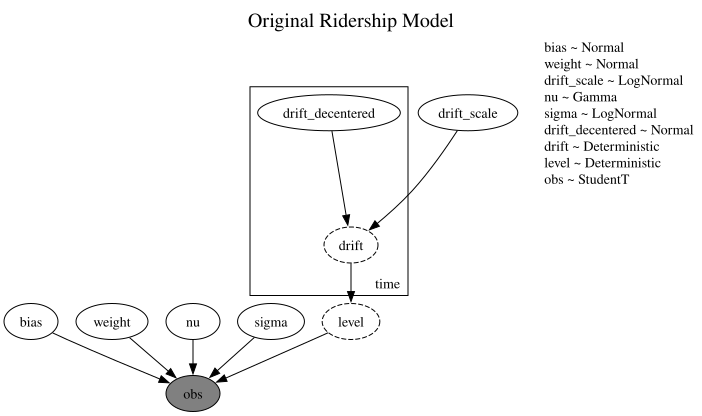

In [28]:
def ridership_model(
    covariates: Float[Array, "duration features"],
    data: Float[Array, "t_obs 1"] | None = None,
) -> None:
    "Local level with a Fourier regression and Student-T observations."
    h = Horizon.from_data(covariates, data)
    num_features = covariates.shape[-1]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    weight = numpyro.sample(
        "weight", dist.Normal(0.0, 0.1).expand([num_features]).to_event(1)
    )
    drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20.0, 5.0))
    nu = numpyro.sample("nu", dist.Gamma(10.0, 2.0))
    sigma = numpyro.sample("sigma", dist.LogNormal(-5.0, 5.0))

    drift = innovations(
        h,
        "drift",
        dist.Normal(0.0, drift_scale),
        reparam=LocScaleReparam(centered=0.0),
    )
    level = numpyro.deterministic("level", jnp.cumsum(drift, axis=-2))
    regression = (weight * covariates).sum(axis=-1, keepdims=True)

    predict(h, dist.StudentT(df=nu, loc=0.0, scale=sigma), bias + level + regression)


graph = numpyro.render_model(
    ridership_model,
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

graph.attr(label="Original Ridership Model", labelloc="t", fontsize="20")

graph

The function `time_reparam` of `numpyro_forecast` applies the same reparameterizers to a forecasting model. It selects every latent sample site inside the `time` plate, which are the sites that `innovations` samples, and it rotates them along the time axis. The global parameters and the likelihood stay as they are.

Each rotated version of the model is one call to `time_reparam`. We create each wrapped model once and reuse it for fitting and forecasting.

**Remark (Pyro's names):** In Pyro `1.9.2` the two names are swapped in [`pyro.contrib.forecast.util`](https://github.com/pyro-ppl/pyro/blob/1.9.2/pyro/contrib/forecast/util.py): `time_reparam="haar"` applies the DCT and `time_reparam="dct"` applies the Haar transform. In `numpyro_forecast` each name does what it says. Take this into account when comparing results across the two libraries.

In [29]:
models: dict[str, Model] = {
    "none": ridership_model,
    "haar": time_reparam(ridership_model, "haar"),
    "dct": time_reparam(ridership_model, "dct"),
}

Let's render the DCT version to see which sites it has.

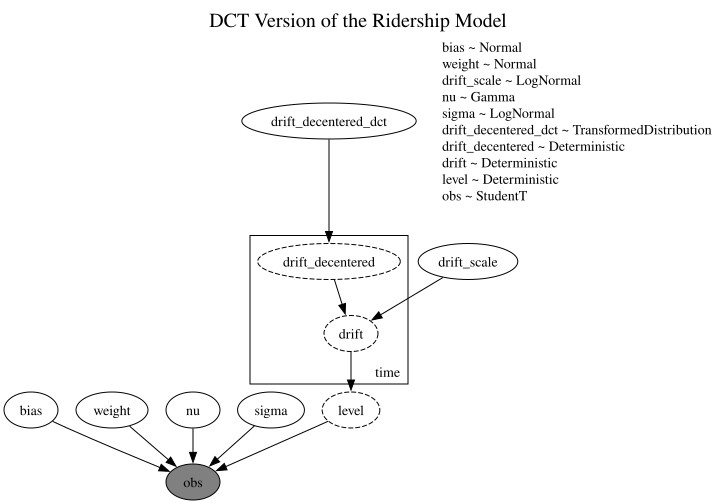

In [30]:
graph = numpyro.render_model(
    models["dct"],
    model_args=(covariates_train, y_train),
    render_distributions=True,
)

graph.attr(label="DCT Version of the Ridership Model", labelloc="t", fontsize="20")

graph

The graph shows the sites of the reparameterized model. Solid ellipses are latent sites, dashed ellipses are deterministic sites, the gray ellipse is the observed site, and the box is the `time` plate.

- **The new latent site is `drift_decentered_dct`.** It is outside the `time` plate, because its $417$ coordinates are DCT coefficients and not time steps.
- **The sites inside the plate are deterministic.** The model computes both `drift_decentered` (the standardized increments $\tilde{\eta}_t$) and `drift` from the new site.
- **The other sites are the same as in the model code.** The global parameters, the level and the likelihood do not change.

## Variational Inference

We fit an `AutoNormal` guide to each version of the model, with the optimizer and the number of steps of the documentation example: `Adam` with a step size of $0.005$ for $50000$ steps. The result of one fit depends on the random key, so we repeat every fit with five random keys, the same five for the three coordinate systems.

We also initialize the location of `bias` at the mean of the training data. The data are close to $14.6$ on the log scale, and the default initialization draws every location uniformly in $(-2, 2)$. We study the default initialization in the next subsection.

In [31]:
%%time

NUM_STEPS = 50_000


class Fit(NamedTuple):
    "Result of one SVI fit."

    guide: AutoNormal
    params: dict[str, Array]
    losses: Float[Array, " steps"]
    seconds: float


def fit_guide(
    rng_key: UInt[Array, "2"],
    model: Model,
    init_loc_fn: Callable,
    step_size: float | Callable = 0.005,
) -> Fit:
    "Fit a mean-field guide to a version of the ridership model."
    guide = AutoNormal(model, init_loc_fn=init_loc_fn)
    svi = SVI(model, guide, Adam(step_size=step_size), Trace_ELBO())
    start = perf_counter()
    result = svi.run(rng_key, NUM_STEPS, covariates_train, y_train, progress_bar=False)
    result.losses.block_until_ready()
    return Fit(guide, result.params, result.losses, perf_counter() - start)


def final_loss(fit: Fit) -> float:
    "Average ELBO loss over the last 1000 steps."
    return float(fit.losses[-1_000:].mean())


init_bias = init_to_value(values={"bias": y_train.mean()})

rng_key, *svi_keys = random.split(rng_key, 6)
svi_fits = {
    name: [fit_guide(key, model, init_bias) for key in svi_keys]
    for name, model in models.items()
}

CPU times: user 2min 47s, sys: 59.5 s, total: 3min 47s
Wall time: 1min 27s


We plot the ELBO loss (the negative ELBO, in nats, so lower is better) of the first fit in each coordinate system. The curves are rolling means over $200$ steps.

The left panel shows the first $10000$ steps, with the final loss of the original fit as a dotted line. The right panel shows the last $20000$ steps, and the arrow is the difference between the final losses of the original and the DCT fits. The legend gives the average loss over the last $1000$ steps.

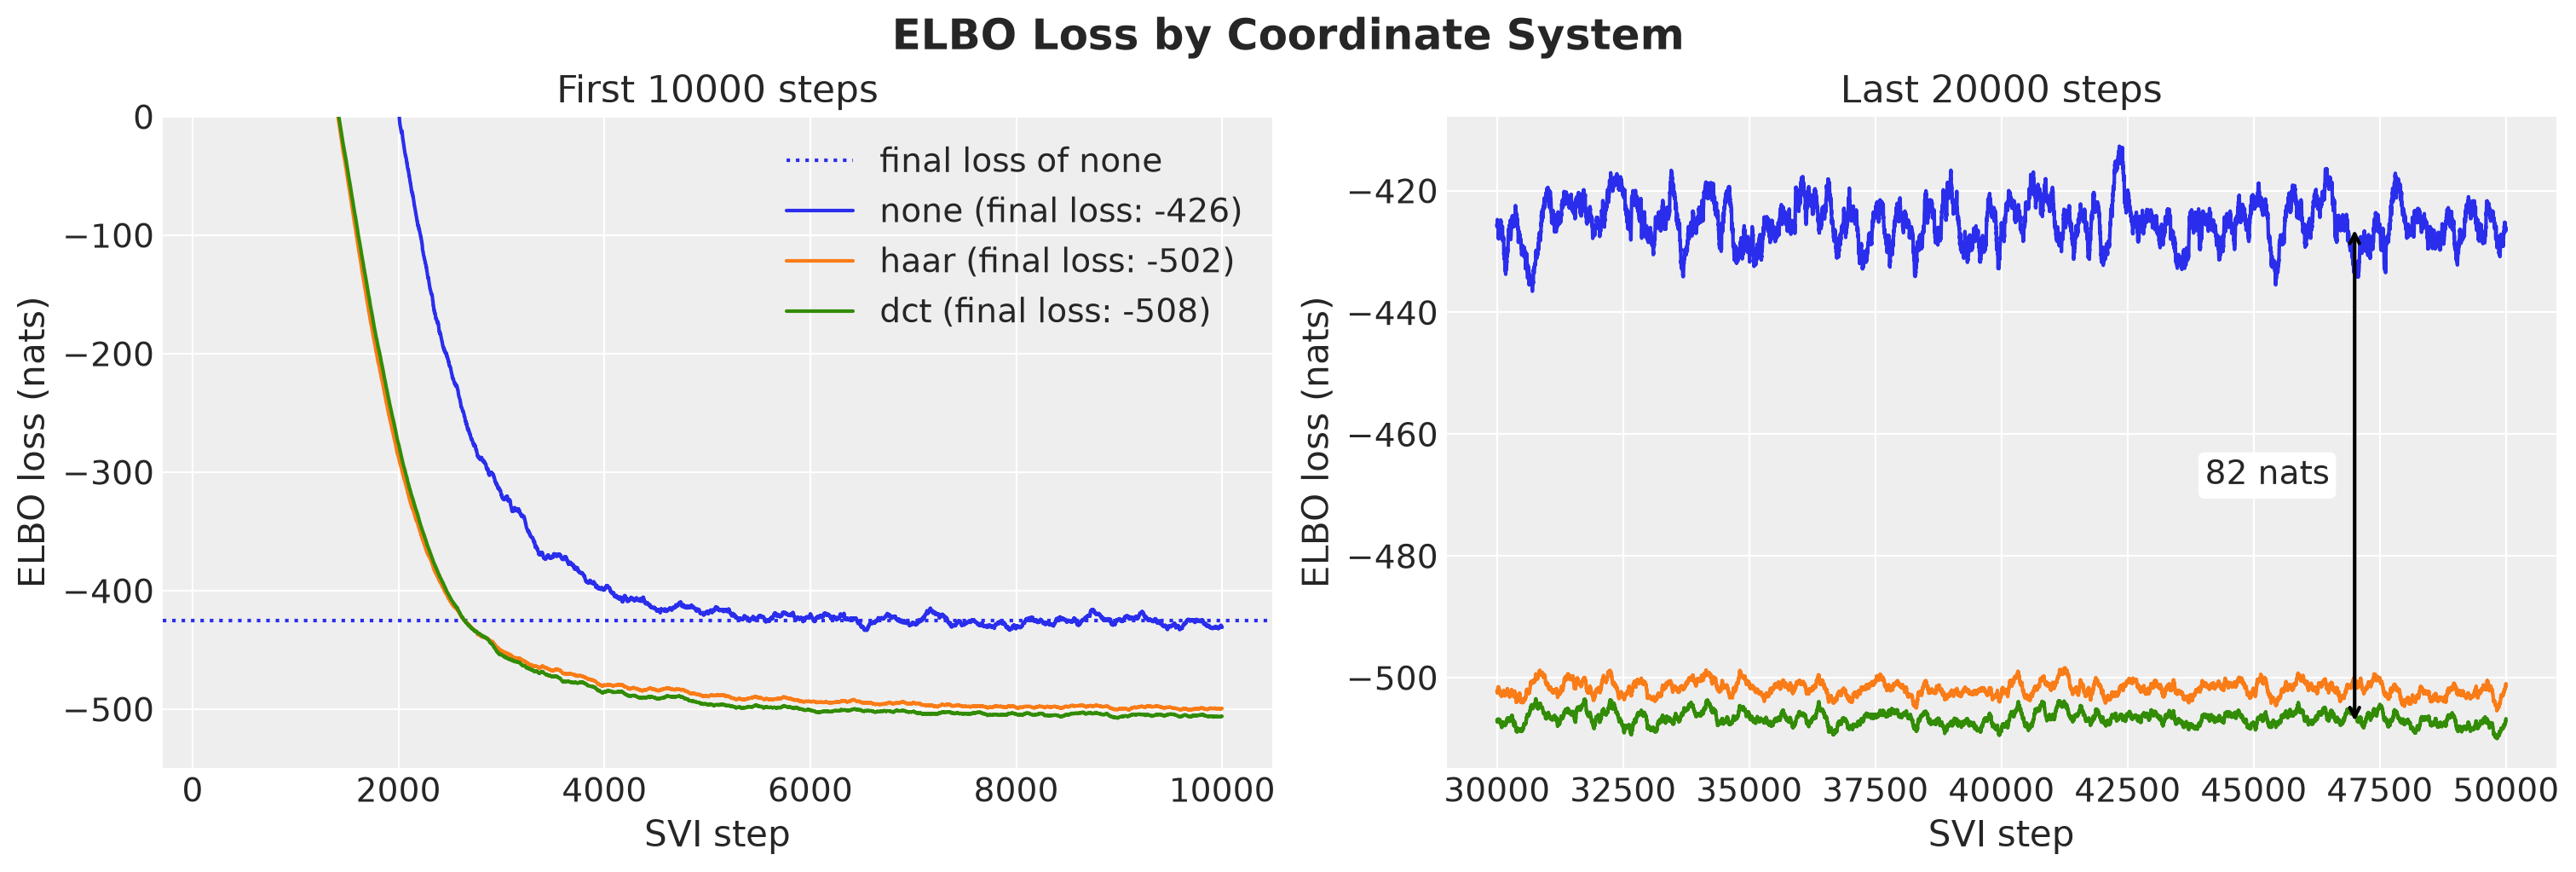

In [32]:
def rolling_mean(values: Float[Array, " n"], window: int = 200) -> Float[Array, " m"]:
    "Rolling mean, aligned with the right end of each window."
    return jnp.convolve(values, jnp.ones(window) / window, mode="valid")


window = 200
steps = jnp.arange(window - 1, NUM_STEPS)
early = steps < 10_000
late = steps >= NUM_STEPS - 20_000

none_final_loss = final_loss(svi_fits["none"][0])
dct_final_loss = final_loss(svi_fits["dct"][0])
arrow_step = NUM_STEPS - 3_000

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axes[0].axhline(
    none_final_loss, color=COLORS["none"], linestyle=":", label="final loss of none"
)

for name, fits in svi_fits.items():
    smooth = rolling_mean(fits[0].losses, window)
    axes[0].plot(
        steps[early],
        smooth[early],
        color=COLORS[name],
        label=f"{name} (final loss: {final_loss(fits[0]):.0f})",
    )
    axes[1].plot(steps[late], smooth[late], color=COLORS[name])

axes[0].set(
    xlabel="SVI step",
    ylabel="ELBO loss (nats)",
    title="First 10000 steps",
    ylim=(-550, 0),
)
axes[0].legend(loc="upper right")
axes[1].set(xlabel="SVI step", ylabel="ELBO loss (nats)", title="Last 20000 steps")
axes[1].annotate(
    "",
    xy=(arrow_step, dct_final_loss),
    xytext=(arrow_step, none_final_loss),
    arrowprops={"arrowstyle": "<->", "color": "black", "linewidth": 1.5},
)
axes[1].text(
    arrow_step - 500,
    (none_final_loss + dct_final_loss) / 2,
    f"{none_final_loss - dct_final_loss:.0f} nats",
    ha="right",
    va="center",
    fontsize=14,
    bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "none"},
)
fig.suptitle("ELBO Loss by Coordinate System", fontsize=18, fontweight="bold");

The three curves are the same guide family fitted to the same model, in three coordinate systems.

- **The rotated fits reach a much better ELBO.** The final loss is about $-426$ in the original coordinates, $-502$ with the Haar transform and $-508$ with the DCT. The gain is about $77$ nats with Haar and $82$ nats with the DCT.
- **They are ahead during the whole run.** The rotated fits cross the dotted line after about $2600$ steps. The original fit needs about $5400$ steps to reach its own final loss.
- **The DCT is slightly ahead of Haar.** The difference is about $5$ nats, the same order as in the local level model.
- **The loss is less noisy in the rotated coordinates.** In the last $20000$ steps the smoothed loss of the original fit varies about three times more than the rotated ones.

The log evidence is the same for the three models, so a better ELBO means a guide that is closer to the posterior 🚀. We look at what this means for the parameters and for the forecasts in the last section.

The rotated fits need fewer steps, but each step costs more. Let's time the fits. The first fit of each model includes the compilation, so we show the other four of each coordinate system. The bar is their mean and each black point is one fit.

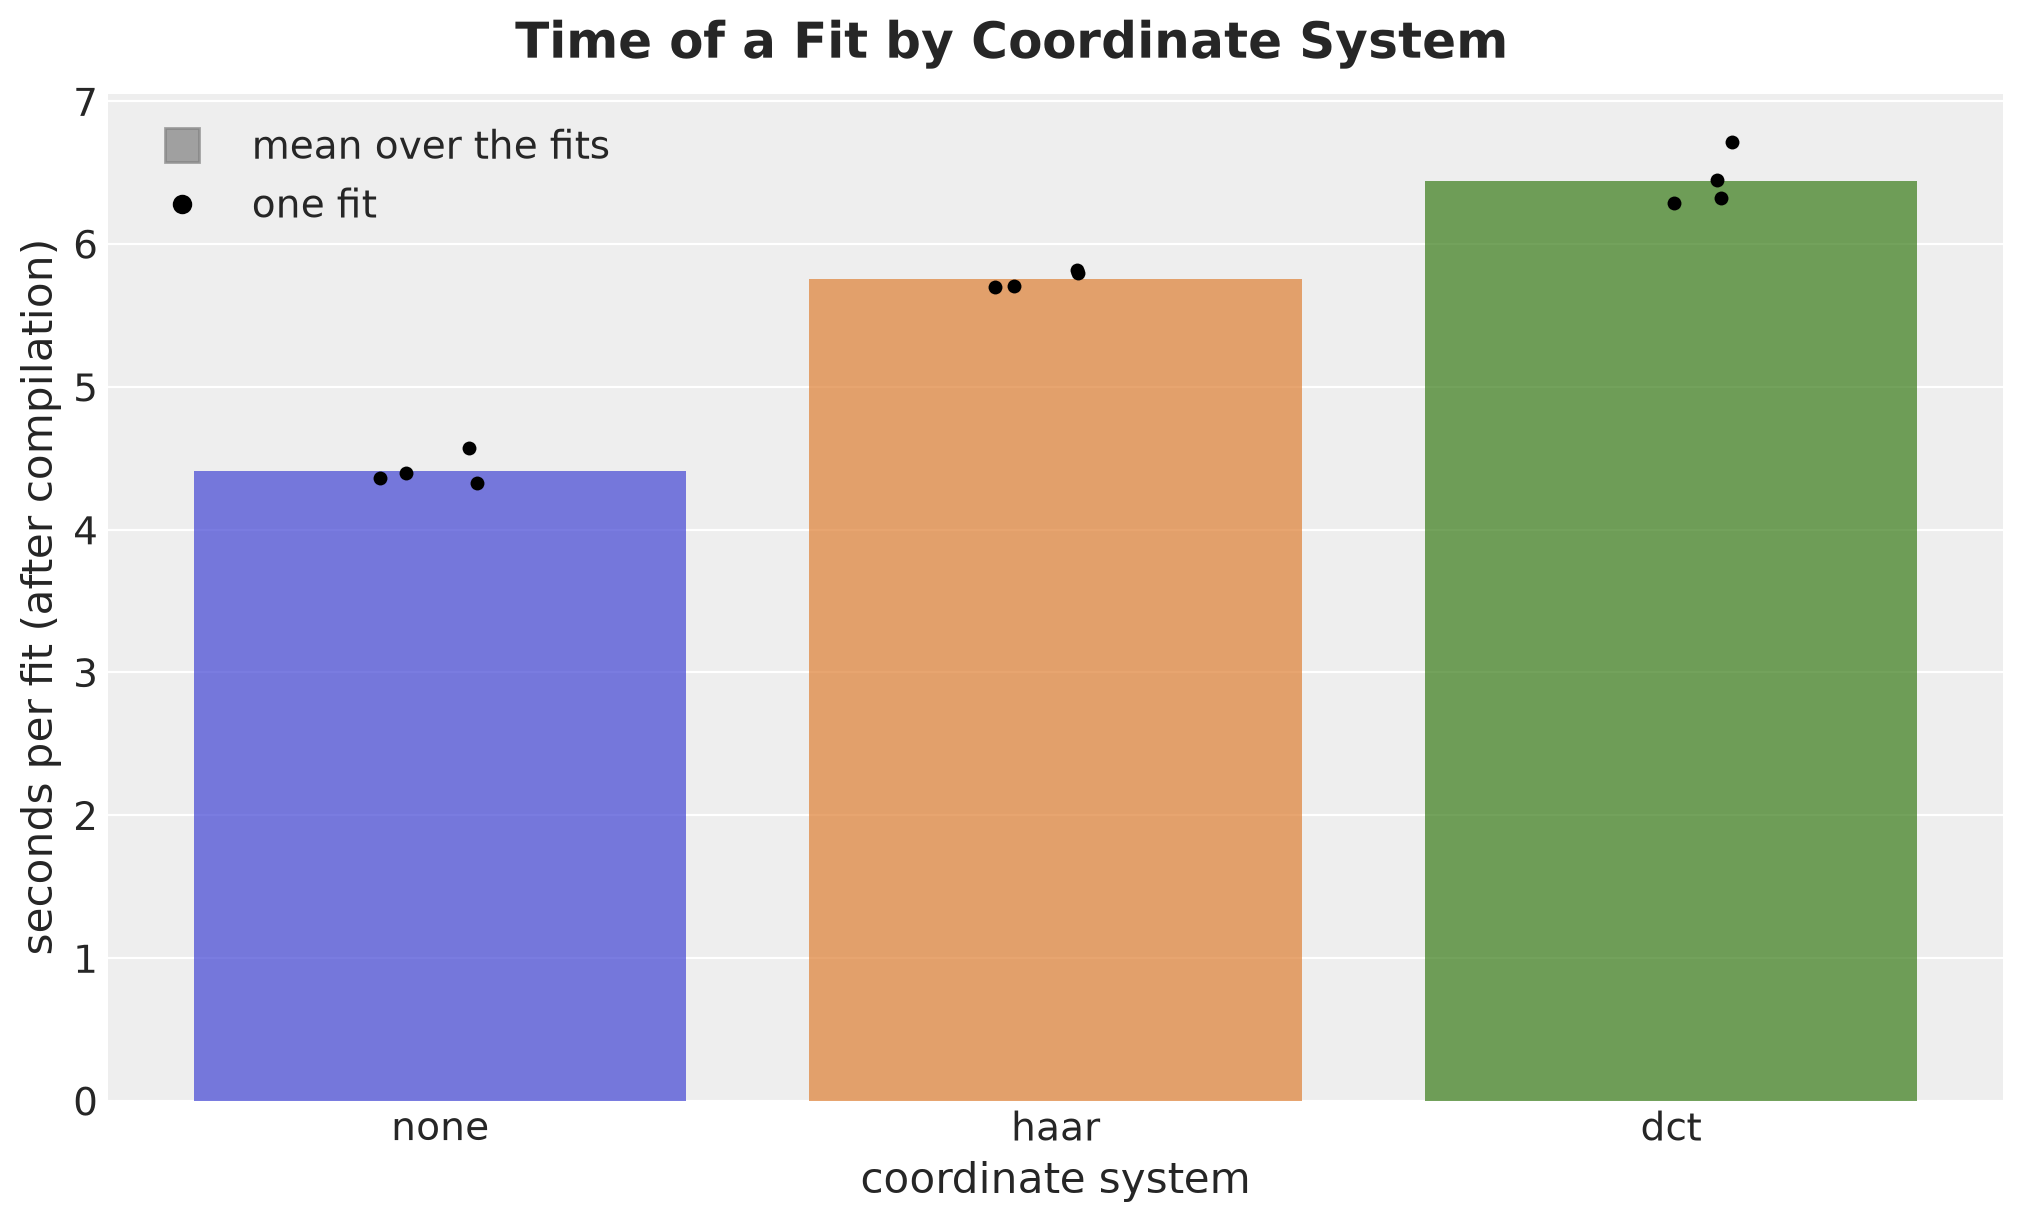

In [33]:
fit_seconds = pl.DataFrame(
    [
        {"coordinates": name, "seconds": fit.seconds}
        for name, fits in svi_fits.items()
        for fit in fits[1:]
    ]
)

fig, ax = plt.subplots()
sns.barplot(
    data=fit_seconds,
    x="coordinates",
    y="seconds",
    hue="coordinates",
    palette=COLORS,
    alpha=0.7,
    errorbar=None,
    legend=False,
    ax=ax,
)
sns.stripplot(data=fit_seconds, x="coordinates", y="seconds", color="black", ax=ax)
ax.plot([], [], "s", color="gray", alpha=0.7, markersize=12, label="mean over the fits")
ax.plot([], [], "o", color="black", label="one fit")
ax.legend(loc="upper left")
ax.set(xlabel="coordinate system", ylabel="seconds per fit (after compilation)")
fig.suptitle("Time of a Fit by Coordinate System", fontsize=18, fontweight="bold");

The spread of the points shows how much the time varies between runs.

- **A step costs more in the rotated coordinates.** A fit takes about $4.4$ seconds in the original coordinates, $5.8$ with the Haar transform and $6.4$ with the DCT. The rotated fits need less than half the steps to reach the final loss of the original fit, so they are also ahead in time.

**Remark (series length):** The DCT uses a fast Fourier transform, and its cost depends on the factorization of the length of the series. Here $T = 417 = 3 \times 139$, and $139$ is a prime number. A length with small prime factors, such as $512$, makes the transform cheaper.

### Initialization

What happens with the default initialization? We repeat all the fits with `init_to_uniform`, the default of `AutoNormal`, and the same random keys.

In [34]:
%%time

default_fits = {
    name: [fit_guide(key, model, init_to_uniform) for key in svi_keys]
    for name, model in models.items()
}

CPU times: user 2min 43s, sys: 1min, total: 3min 43s
Wall time: 1min 22s


We plot the complete loss curves of the first fit (left), and the final loss of all the fits for the two initializations (right).

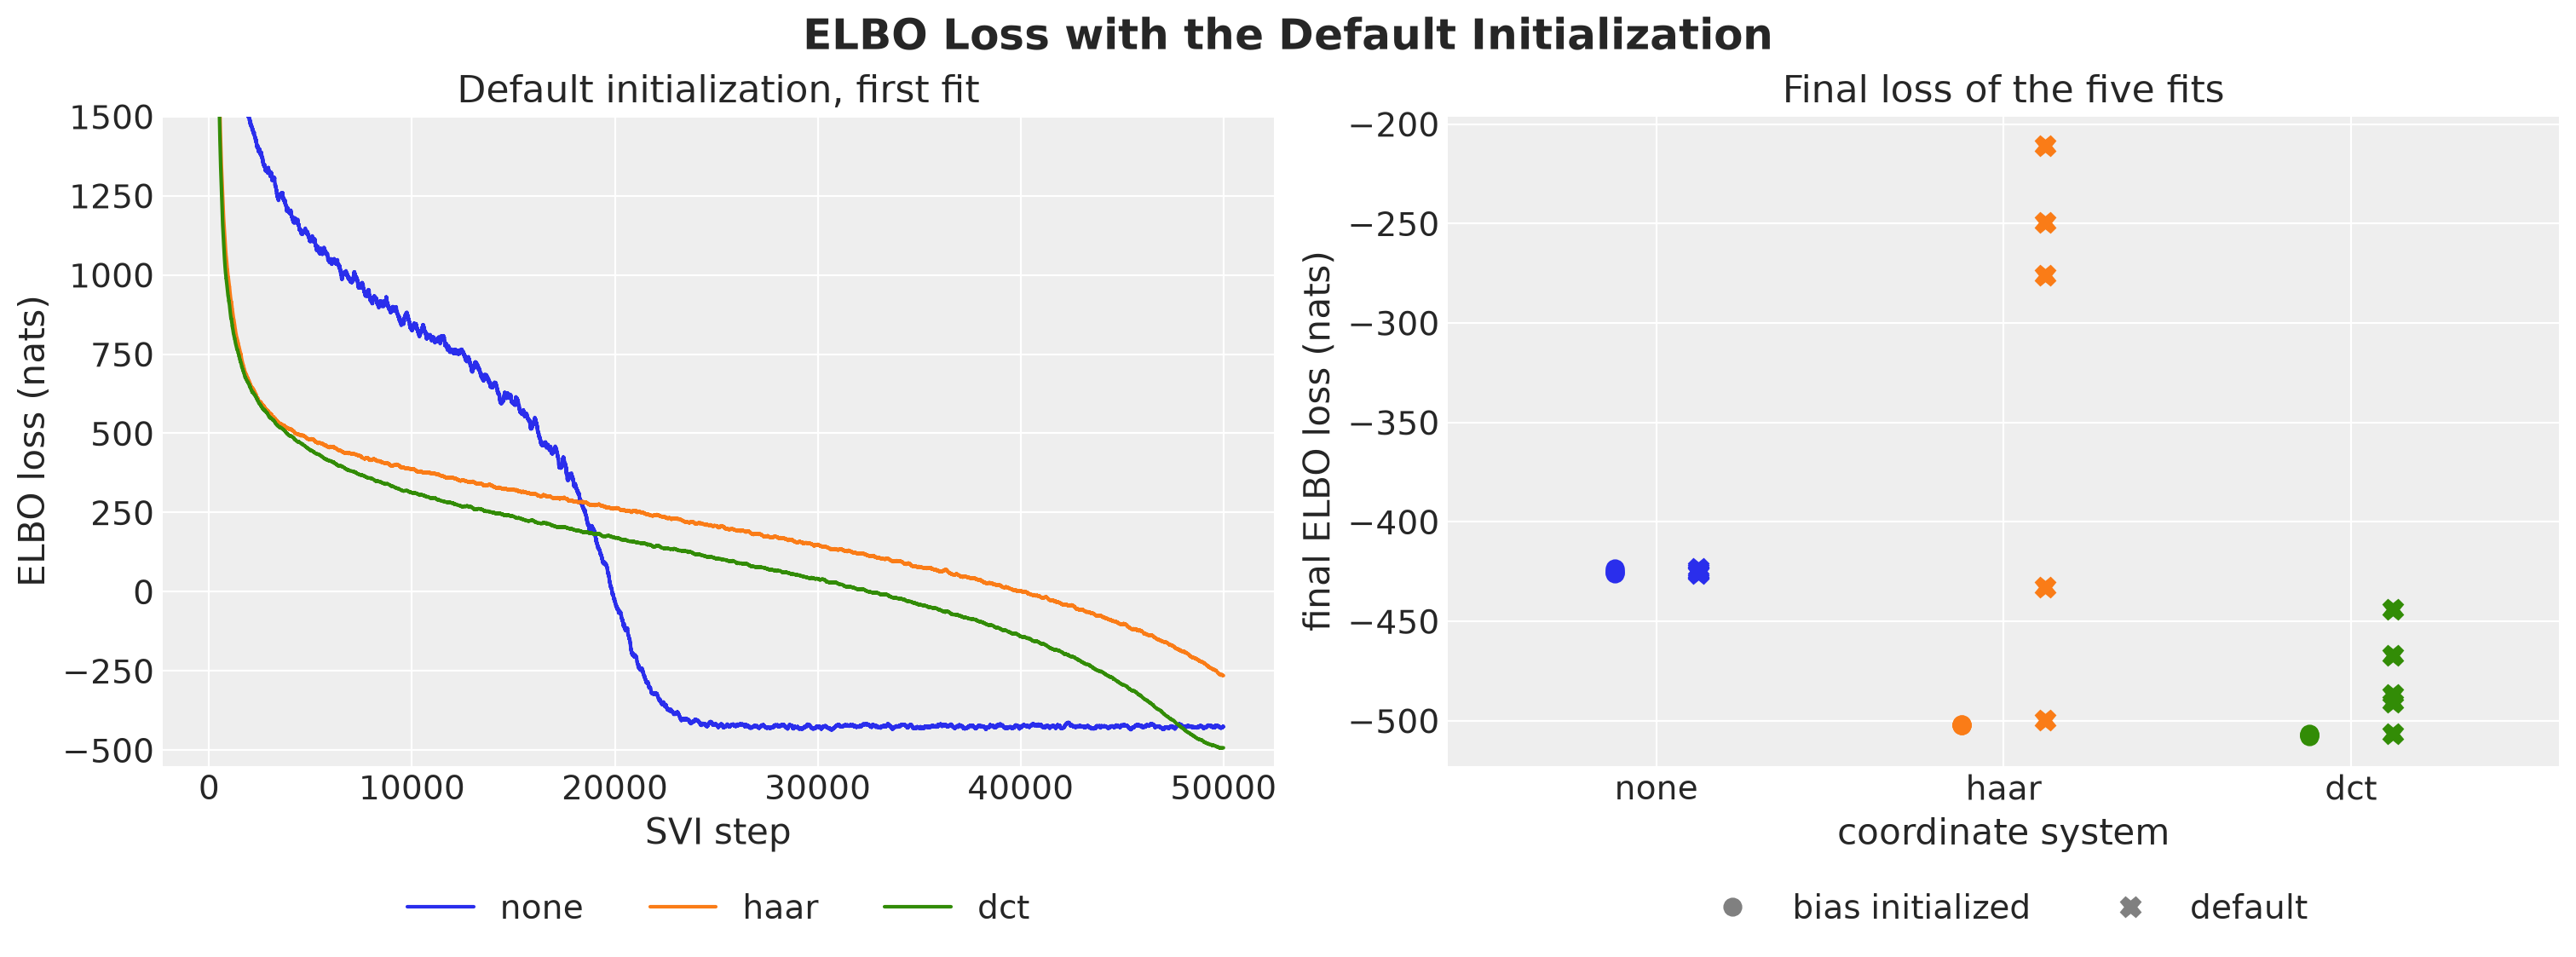

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5))

for position, name in enumerate(COLORS):
    axes[0].plot(
        steps,
        rolling_mean(default_fits[name][0].losses, window),
        color=COLORS[name],
        label=name,
    )
    axes[1].plot(
        [position - 0.12] * len(svi_keys),
        [final_loss(fit) for fit in svi_fits[name]],
        "o",
        color=COLORS[name],
        markersize=7,
    )
    axes[1].plot(
        [position + 0.12] * len(svi_keys),
        [final_loss(fit) for fit in default_fits[name]],
        "X",
        color=COLORS[name],
        markersize=8,
    )

axes[0].set(
    xlabel="SVI step",
    ylabel="ELBO loss (nats)",
    title="Default initialization, first fit",
    ylim=(-550, 1_500),
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
axes[1].set(
    xticks=list(range(len(COLORS))),
    xticklabels=list(COLORS),
    xlim=(-0.6, 2.6),
    xlabel="coordinate system",
    ylabel="final ELBO loss (nats)",
    title="Final loss of the five fits",
)
axes[1].plot([], [], "o", color="gray", markersize=7, label="bias initialized")
axes[1].plot([], [], "X", color="gray", markersize=8, label="default")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
fig.suptitle(
    "ELBO Loss with the Default Initialization", fontsize=18, fontweight="bold"
);

The left panel shows the three loss curves of the first fit with the default initialization. In the right panel each marker is the final loss of one fit: circles for the fits with `bias` initialized and crosses for the default initialization.

- **With `bias` initialized the result does not depend on the random key.** The five circles of each coordinate system are within $3$ nats of each other.
- **With the default initialization every fit needs many more steps.** In the original coordinates the five fits reach the same loss as before. The first one needs about $24000$ steps to come within $5$ nats of its final loss, instead of about $5200$ with `bias` initialized.
- **The rotated fits are slower, and most do not finish.** In the first fit neither rotated version comes within $5$ nats of the loss with `bias` initialized: the Haar fit ends about $250$ nats above it and the DCT fit about $20$ nats above it. Three of the five Haar fits end more than $200$ nats above it, and four of the five DCT fits end between $17$ and $63$ nats above it.

The slow phase comes from the intercept: the only difference between the two sets of fits is the starting value of `bias`. Let's look at where the unfinished fits are. For the first fit of each coordinate system we compare the default initialization with the initialized `bias`: the difference in the final loss, the difference in the guide median of `bias`, and the ratio of the guide medians of `drift_scale`.

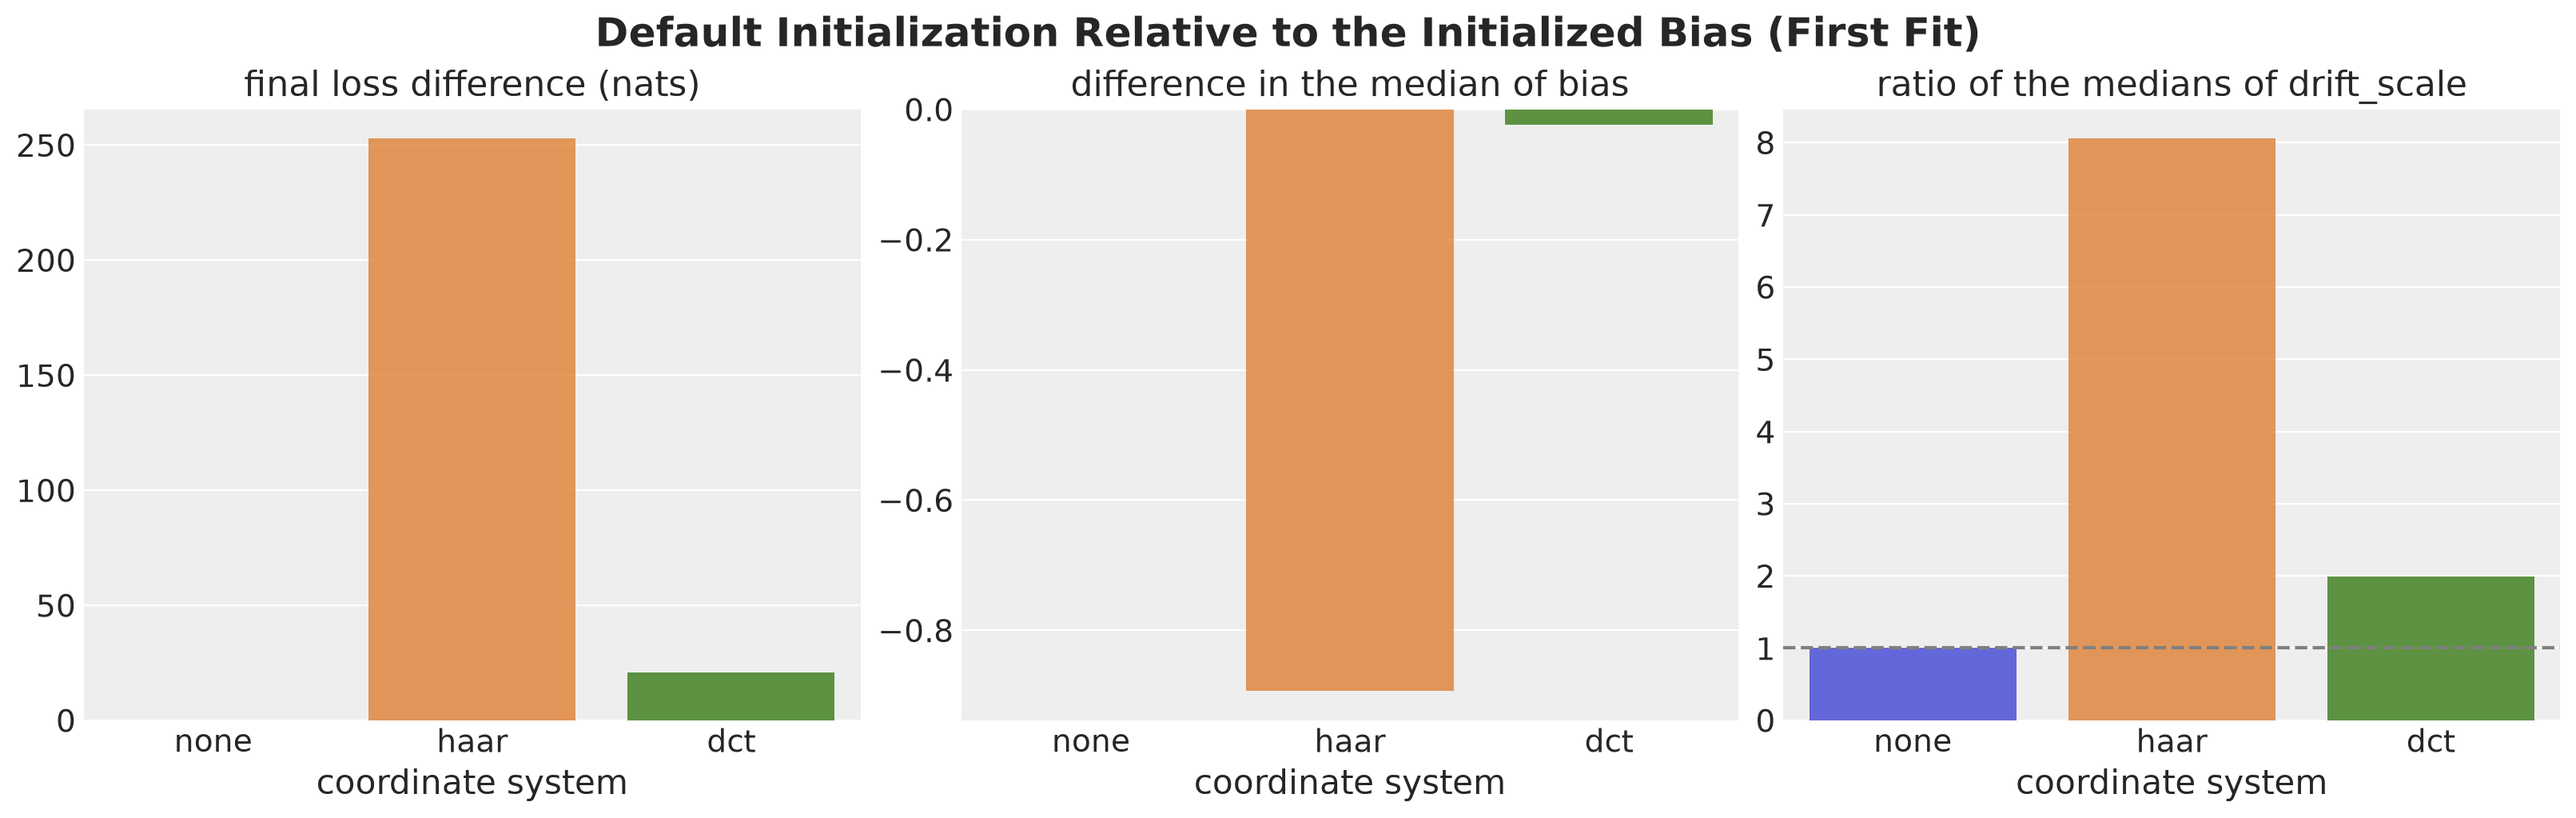

In [36]:
def guide_median(fit: Fit, site: str) -> float:
    "Guide median of a scalar site of one fit."
    return float(fit.guide.median(fit.params)[site])


first_fit_differences = pl.DataFrame(
    [
        {"coordinates": name, "quantity": quantity, "value": value}
        for name in COLORS
        for quantity, value in [
            (
                "final loss difference (nats)",
                final_loss(default_fits[name][0]) - final_loss(svi_fits[name][0]),
            ),
            (
                "difference in the median of bias",
                guide_median(default_fits[name][0], "bias")
                - guide_median(svi_fits[name][0], "bias"),
            ),
            (
                "ratio of the medians of drift_scale",
                guide_median(default_fits[name][0], "drift_scale")
                / guide_median(svi_fits[name][0], "drift_scale"),
            ),
        ]
    ]
)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

for ax, quantity in zip(
    axes, first_fit_differences["quantity"].unique(maintain_order=True), strict=True
):
    sns.barplot(
        data=first_fit_differences.filter(pl.col("quantity") == quantity),
        x="coordinates",
        y="value",
        hue="coordinates",
        palette=COLORS,
        alpha=0.8,
        legend=False,
        ax=ax,
    )
    ax.set(xlabel="coordinate system", ylabel="", title=quantity)

axes[2].axhline(1, color="gray", linestyle="--")
fig.suptitle(
    "Default Initialization Relative to the Initialized Bias (First Fit)",
    fontsize=18,
    fontweight="bold",
);

The unfinished fits hold part of the intercept in the level. The Haar fit ends about $250$ nats above the fit with `bias` initialized, its median of `bias` is about $0.9$ below, and its median of `drift_scale` is about $8$ times larger, because the level has to carry the rest of the offset. The DCT fit shows the same pattern with smaller numbers: about $20$ nats, a `bias` close to the initialized one, and a `drift_scale` about $2$ times larger.

The fit in the original coordinates ends at the same point as with `bias` initialized, so its three bars are at $0$, $0$ and $1$.

The step size is the one of the documentation example, which is tuned for the original coordinates. Let's repeat the fits with the default initialization and a step size that decays from $0.02$ to $0.005$, so that the step size at the start is four times larger and the end of the run is as before.

In [37]:
%%time

schedule = exponential_decay(0.02, NUM_STEPS, 0.25)

schedule_fits = {
    name: [fit_guide(key, model, init_to_uniform, schedule) for key in svi_keys]
    for name, model in models.items()
}

CPU times: user 2min 44s, sys: 1min, total: 3min 45s
Wall time: 1min 23s


We plot the final loss of every fit for the three setups (left). For the two setups with the default initialization we also plot, per coordinate system, the largest difference over the five keys between the final loss of the fit and the final loss of the fit with `bias` initialized (middle and right).

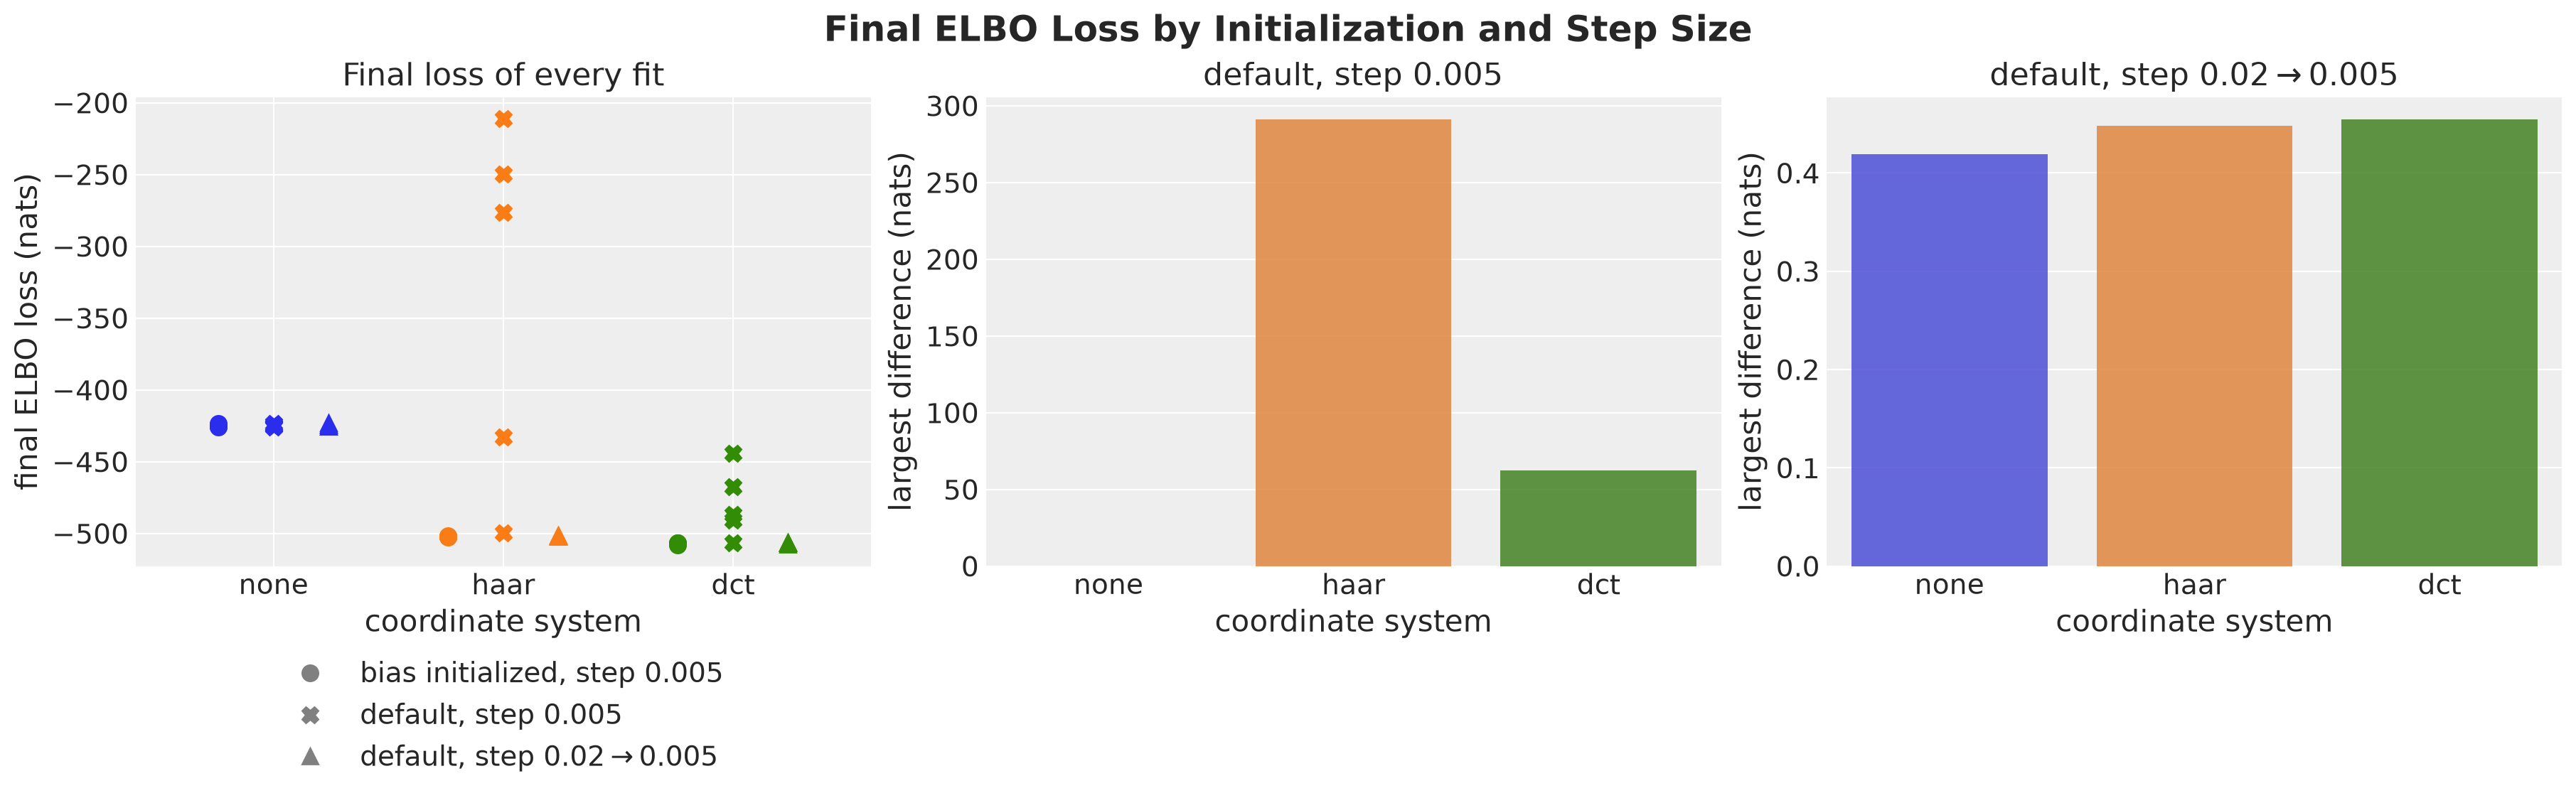

In [38]:
setups = {
    "bias initialized, step $0.005$": (svi_fits, "o", -0.24),
    "default, step $0.005$": (default_fits, "X", 0.0),
    "default, step $0.02 \\to 0.005$": (schedule_fits, "^", 0.24),
}

loss_differences = pl.DataFrame(
    [
        {
            "coordinates": name,
            "setup": setup,
            "largest difference (nats)": max(
                abs(final_loss(fit) - final_loss(reference))
                for fit, reference in zip(fits[name], svi_fits[name], strict=True)
            ),
        }
        for name in COLORS
        for setup, (fits, _, _) in list(setups.items())[1:]
    ]
)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5.5))

for position, name in enumerate(COLORS):
    for fits, marker, shift in setups.values():
        axes[0].plot(
            [position + shift] * len(svi_keys),
            [final_loss(fit) for fit in fits[name]],
            marker,
            color=COLORS[name],
            markersize=8,
            linestyle="",
        )

for setup, (_, marker, _) in setups.items():
    axes[0].plot([], [], marker, color="gray", markersize=8, linestyle="", label=setup)

axes[0].set(
    xticks=list(range(len(COLORS))),
    xticklabels=list(COLORS),
    xlim=(-0.6, 2.6),
    xlabel="coordinate system",
    ylabel="final ELBO loss (nats)",
    title="Final loss of every fit",
)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1)

for ax, setup in zip(axes[1:], list(setups)[1:], strict=True):
    sns.barplot(
        data=loss_differences.filter(pl.col("setup") == setup),
        x="coordinates",
        y="largest difference (nats)",
        hue="coordinates",
        palette=COLORS,
        alpha=0.8,
        legend=False,
        ax=ax,
    )
    ax.set(
        xlabel="coordinate system",
        ylabel="largest difference (nats)",
        title=setup,
    )

fig.suptitle(
    "Final ELBO Loss by Initialization and Step Size", fontsize=18, fontweight="bold"
);

Each marker on the left is the final loss of one fit. In the middle panel, the constant step size leaves differences of about $300$ nats for Haar and about $60$ nats for the DCT. In the right panel, the decaying step size leaves differences below $0.5$ nats in every coordinate system.

- **The decaying step size removes the slow phase.** With the default initialization and the decaying step size, the five fits of every coordinate system end within $0.5$ nats of the fits with `bias` initialized.
- **A larger initial step size works without an initial value for `bias`.** The rotation changes the optimization problem, and a step size tuned for the original coordinates does not transfer as it is. We do not know why the rotated coordinates need the larger initial step.

### Takeaways

Here is what we learned about the interplay between the reparameterization, the initialization and the optimizer.

1. **The rotation changes the optimization problem.** The model and the guide family are the same, but the loss surface that Adam sees is not. Settings tuned in the original coordinates, such as the step size, do not transfer as they are.
2. **Global parameters couple to the coarse coefficients.** The intercept enters the mean through the sum $b + \mu_t$. In the rotated coordinates the coarsest coefficient is the mean increment, and an offset in `bias` can sit in the level for many steps. The differences in the medians of `bias` and `drift_scale` show this for the unfinished fits.
3. **Initialize the global location parameters.** Setting `bias` at the mean of the training data with `init_to_value` removed the slow phase in every fit, and it costs nothing.
4. **Otherwise, start with a larger step size and decay it.** A step size that starts four times larger and decays to the original value reached the same final loss in all $15$ fits. The decay keeps the noise of the last iterates where it was.
5. **Compare the final loss across coordinate systems and keys.** The log evidence is the same in every coordinate system, so a rotated fit that ends above the original one has not converged. A fit that ends above the other keys has not converged either.
6. **Check the medians of the global parameters.** A `bias` away from the other fits or a `drift_scale` several times above them flags an unfinished fit before any forecast is made.
7. **The two bases differ in sensitivity.** On this model the DCT fits with the default initialization ended closer to the converged loss than the Haar fits. We do not have an explanation for the difference.

## Posterior and Forecast Comparison

We now judge the variational fits against a reference. For this model we do not have the exact posterior, so we use NUTS in the original coordinates.

We run $4$ chains with $1000$ draws each. The model is harder than the local level model, so we use $2000$ warmup steps, as the [comparison of inference methods](https://juanitorduz.github.io/numpyro_forecast/docs/examples/inference_methods_comparison.html) does. We use the same initialization of `bias` as for the guides.

We convert the run to a `DataTree` with `az.from_numpyro`, which keeps the sampler statistics, and we check it with `az.diagnose`. It reports divergences, parameters with fewer than $100$ effective draws per chain, and parameters with an $\hat{R}$ above $1.01$.

In [39]:
%%time

scalar_names = ["drift_scale", "sigma", "nu"]

rng_key, rng_subkey = random.split(rng_key)
mcmc = MCMC(
    NUTS(ridership_model, init_strategy=init_bias),
    num_warmup=2_000,
    num_samples=1_000,
    num_chains=4,
    progress_bar=False,
)
mcmc.run(rng_subkey, covariates_train, y_train)
nuts_reference = mcmc.get_samples()
nuts_tree = az.from_numpyro(mcmc)

az.diagnose(nuts_tree);

Divergences
No divergent transitions found.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.
CPU times: user 3min 28s, sys: 6min 48s, total: 10min 17s
Wall time: 1min 13s


The reference run converges, which is good! There are no divergences, and no parameter is flagged for its effective sample size or its $\hat{R}$.

**Remark (secondary mode):** The Student-T likelihood can make this posterior multimodal. Check $\hat{R}$ on every run.

Next, we draw $4000$ samples from each fitted guide with `draw_posterior`. We pack the draws of the first fit of each coordinate system, and the draws of the reference, as ArviZ `DataTree` objects with `to_datatree` from `numpyro_forecast`.

In [40]:
%%time

rng_key, rng_subkey = random.split(rng_key)
svi_posteriors = {
    name: [draw_posterior(rng_subkey, fit.guide, fit.params, 4_000) for fit in fits]
    for name, fits in svi_fits.items()
}

FIT_COLORS = {"NUTS": "black"} | {
    f"SVI: {name}": color for name, color in COLORS.items()
}

# We keep one chain for every tree, so that the four trees share the same `chain` and
# `draw` coordinates.
fit_trees = {
    "NUTS": to_datatree(
        rng_subkey, ridership_model, nuts_reference, y_train, covariates_train
    )
} | {
    f"SVI: {name}": to_datatree(
        rng_subkey, models[name], posteriors[0], y_train, covariates_train
    )
    for name, posteriors in svi_posteriors.items()
}

CPU times: user 29.8 s, sys: 2.08 s, total: 31.9 s
Wall time: 6.76 s


First, we compare the marginal posteriors of the scalar parameters for the first fit. The variational posteriors of `drift_scale` are very narrow, so we plot cumulative distributions, which stay readable when the widths differ.

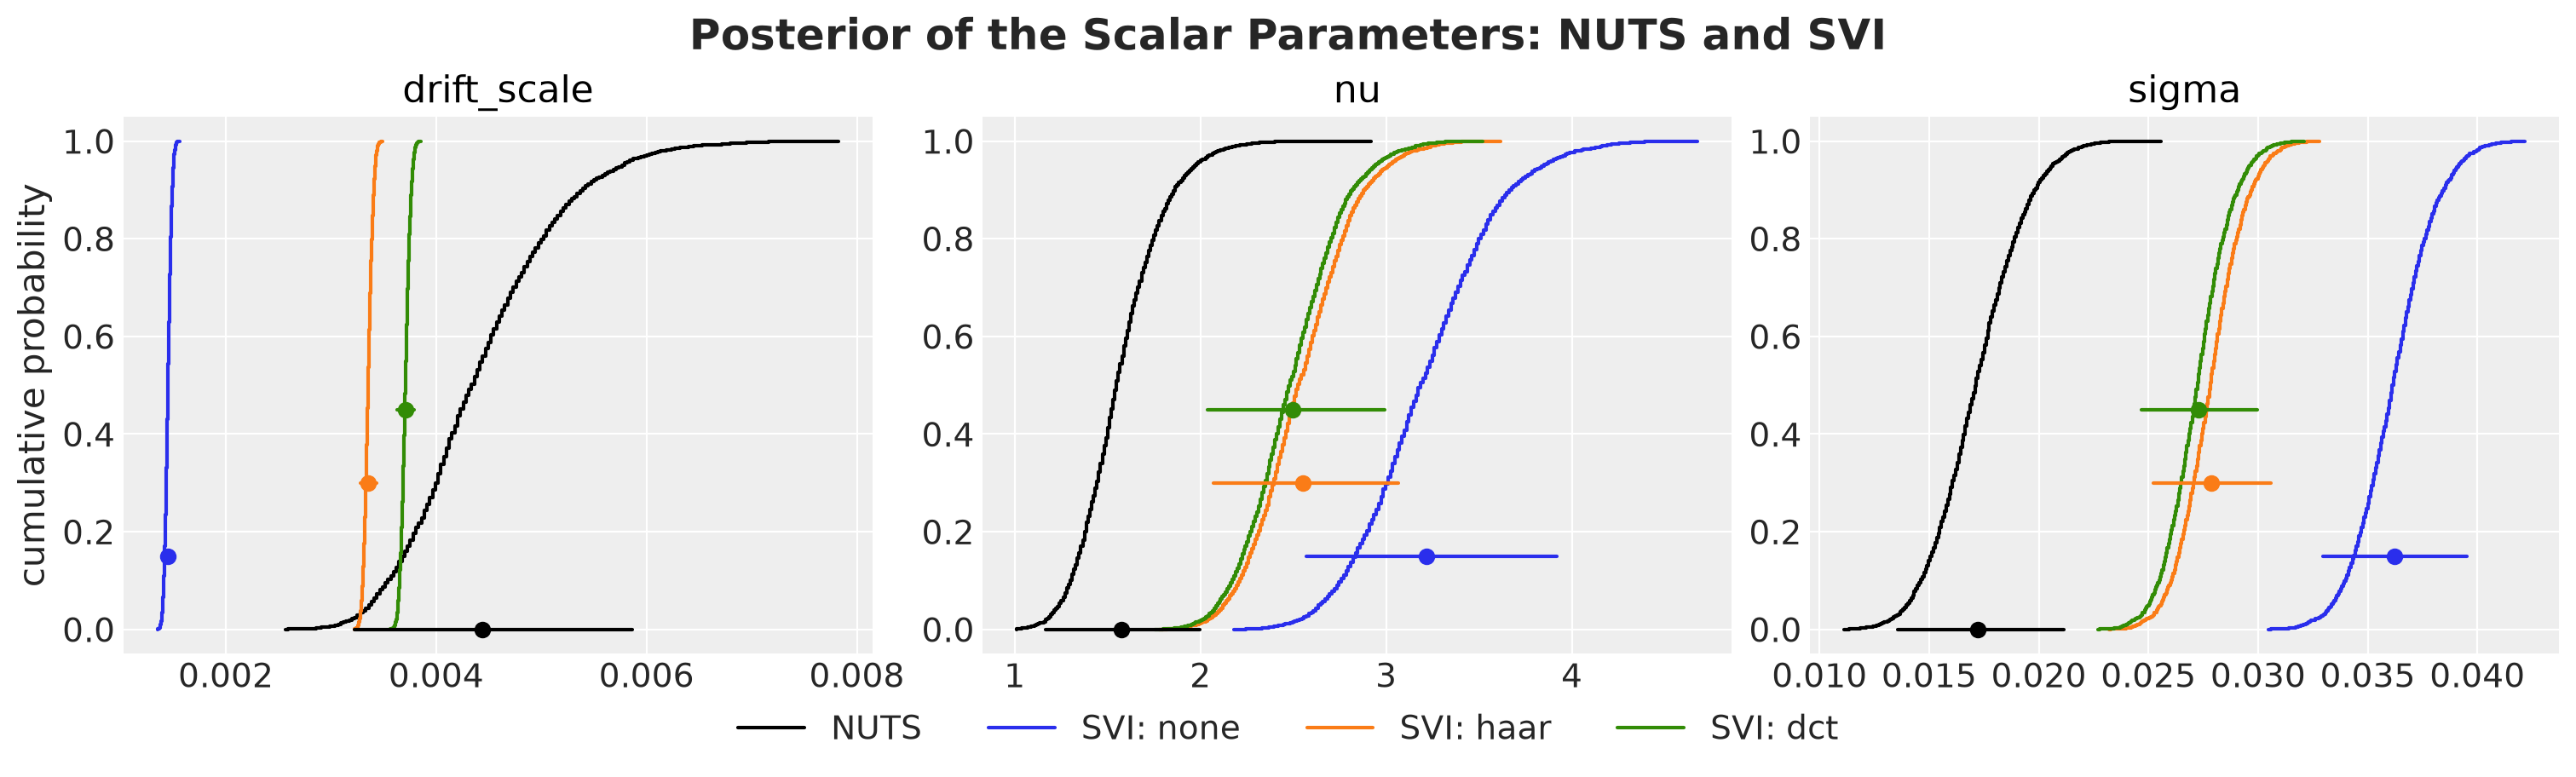

In [41]:
pc = az.plot_dist(
    fit_trees,
    var_names=scalar_names,
    kind="ecdf",
    visuals={"point_estimate_text": False},
    color=list(FIT_COLORS.values()),
    figure_kwargs={"figsize": (15, 4.5)},
)
pc.add_legend("model", title="", loc="outside lower center", ncols=4)
fig = pc.viz["figure"].item()
fig.axes[0].set(ylabel="cumulative probability")
fig.suptitle(
    "Posterior of the Scalar Parameters: NUTS and SVI", fontsize=18, fontweight="bold"
);

Each curve is the empirical cumulative distribution of the draws of one fit. The point is its mean and the horizontal line is its $94\%$ HDI. A steep curve is a narrow posterior. The black curve is the NUTS reference.

- **The likelihood is heavy-tailed.** The NUTS reference puts the degrees of freedom `nu` around $1.6$, far from a Gaussian likelihood.
- **In the original coordinates the fit shrinks the level.** The scale of the increments `drift_scale` is three times smaller than the NUTS mean, and the noise scale `sigma` is about twice as large. This is the pattern of the local level model with unknown scales.
- **The rotated fits are much closer to NUTS.** Their estimates of `drift_scale` are inside the NUTS interval, and `sigma` and `nu` move about halfway toward the reference.
- **A difference remains.** The values of `sigma` and `nu` are still above the reference, and the variational posterior of `drift_scale` is about $20$ times narrower than the NUTS one. A mean-field guide also ignores the dependence between the global parameters and the latent path, and the rotation does not help there.

Next, we compare the posterior of the level, which is the quantity that the forecast extends. We plot its posterior mean and its posterior standard deviation by week.

Can the Gaussian computation of the local level model explain the standard deviations of the fitted guides? We repeat it with two changes, and we plug in the posterior means of $\sigma_\eta$, $\sigma_\varepsilon$ and $\nu$ of each fit.

The first change is the intercept. It enters the mean only through the sum $b + \mu_t$, so we add it to the Gaussian model as one more latent variable, with its prior $\text{Normal}(0, 10)$.

The second change is the likelihood. A Student-T observation with $\nu$ degrees of freedom carries less information about its location than a Gaussian observation with the same scale, by the factor $(\nu + 1) / (\nu + 3)$ (see [Lange, Little and Taylor (1989)](https://doi.org/10.1080/01621459.1989.10478852)). We account for it with a larger noise scale in the Gaussian model,

$$
\tilde{\sigma}_\varepsilon = \sigma_\varepsilon \sqrt{\frac{\nu + 3}{\nu + 1}} .
$$

We leave out the seasonal regression. We compute two quantities from this Gaussian model. The first is the level standard deviation under the best mean-field guide, in the coordinate system and at the scales of each fit. In the original coordinates it is the formula $\tilde{\sigma}_\varepsilon^2 \log\left(a / (a - t)\right)$ of the first part, because the intercept does not change the mean-field variances there.

The second is the exact level standard deviation at the scales of the NUTS reference, without the mean-field restriction. If the Gaussian model is a good proxy, this line should be close to the NUTS line, and the mean-field lines should be close to the fitted guides.

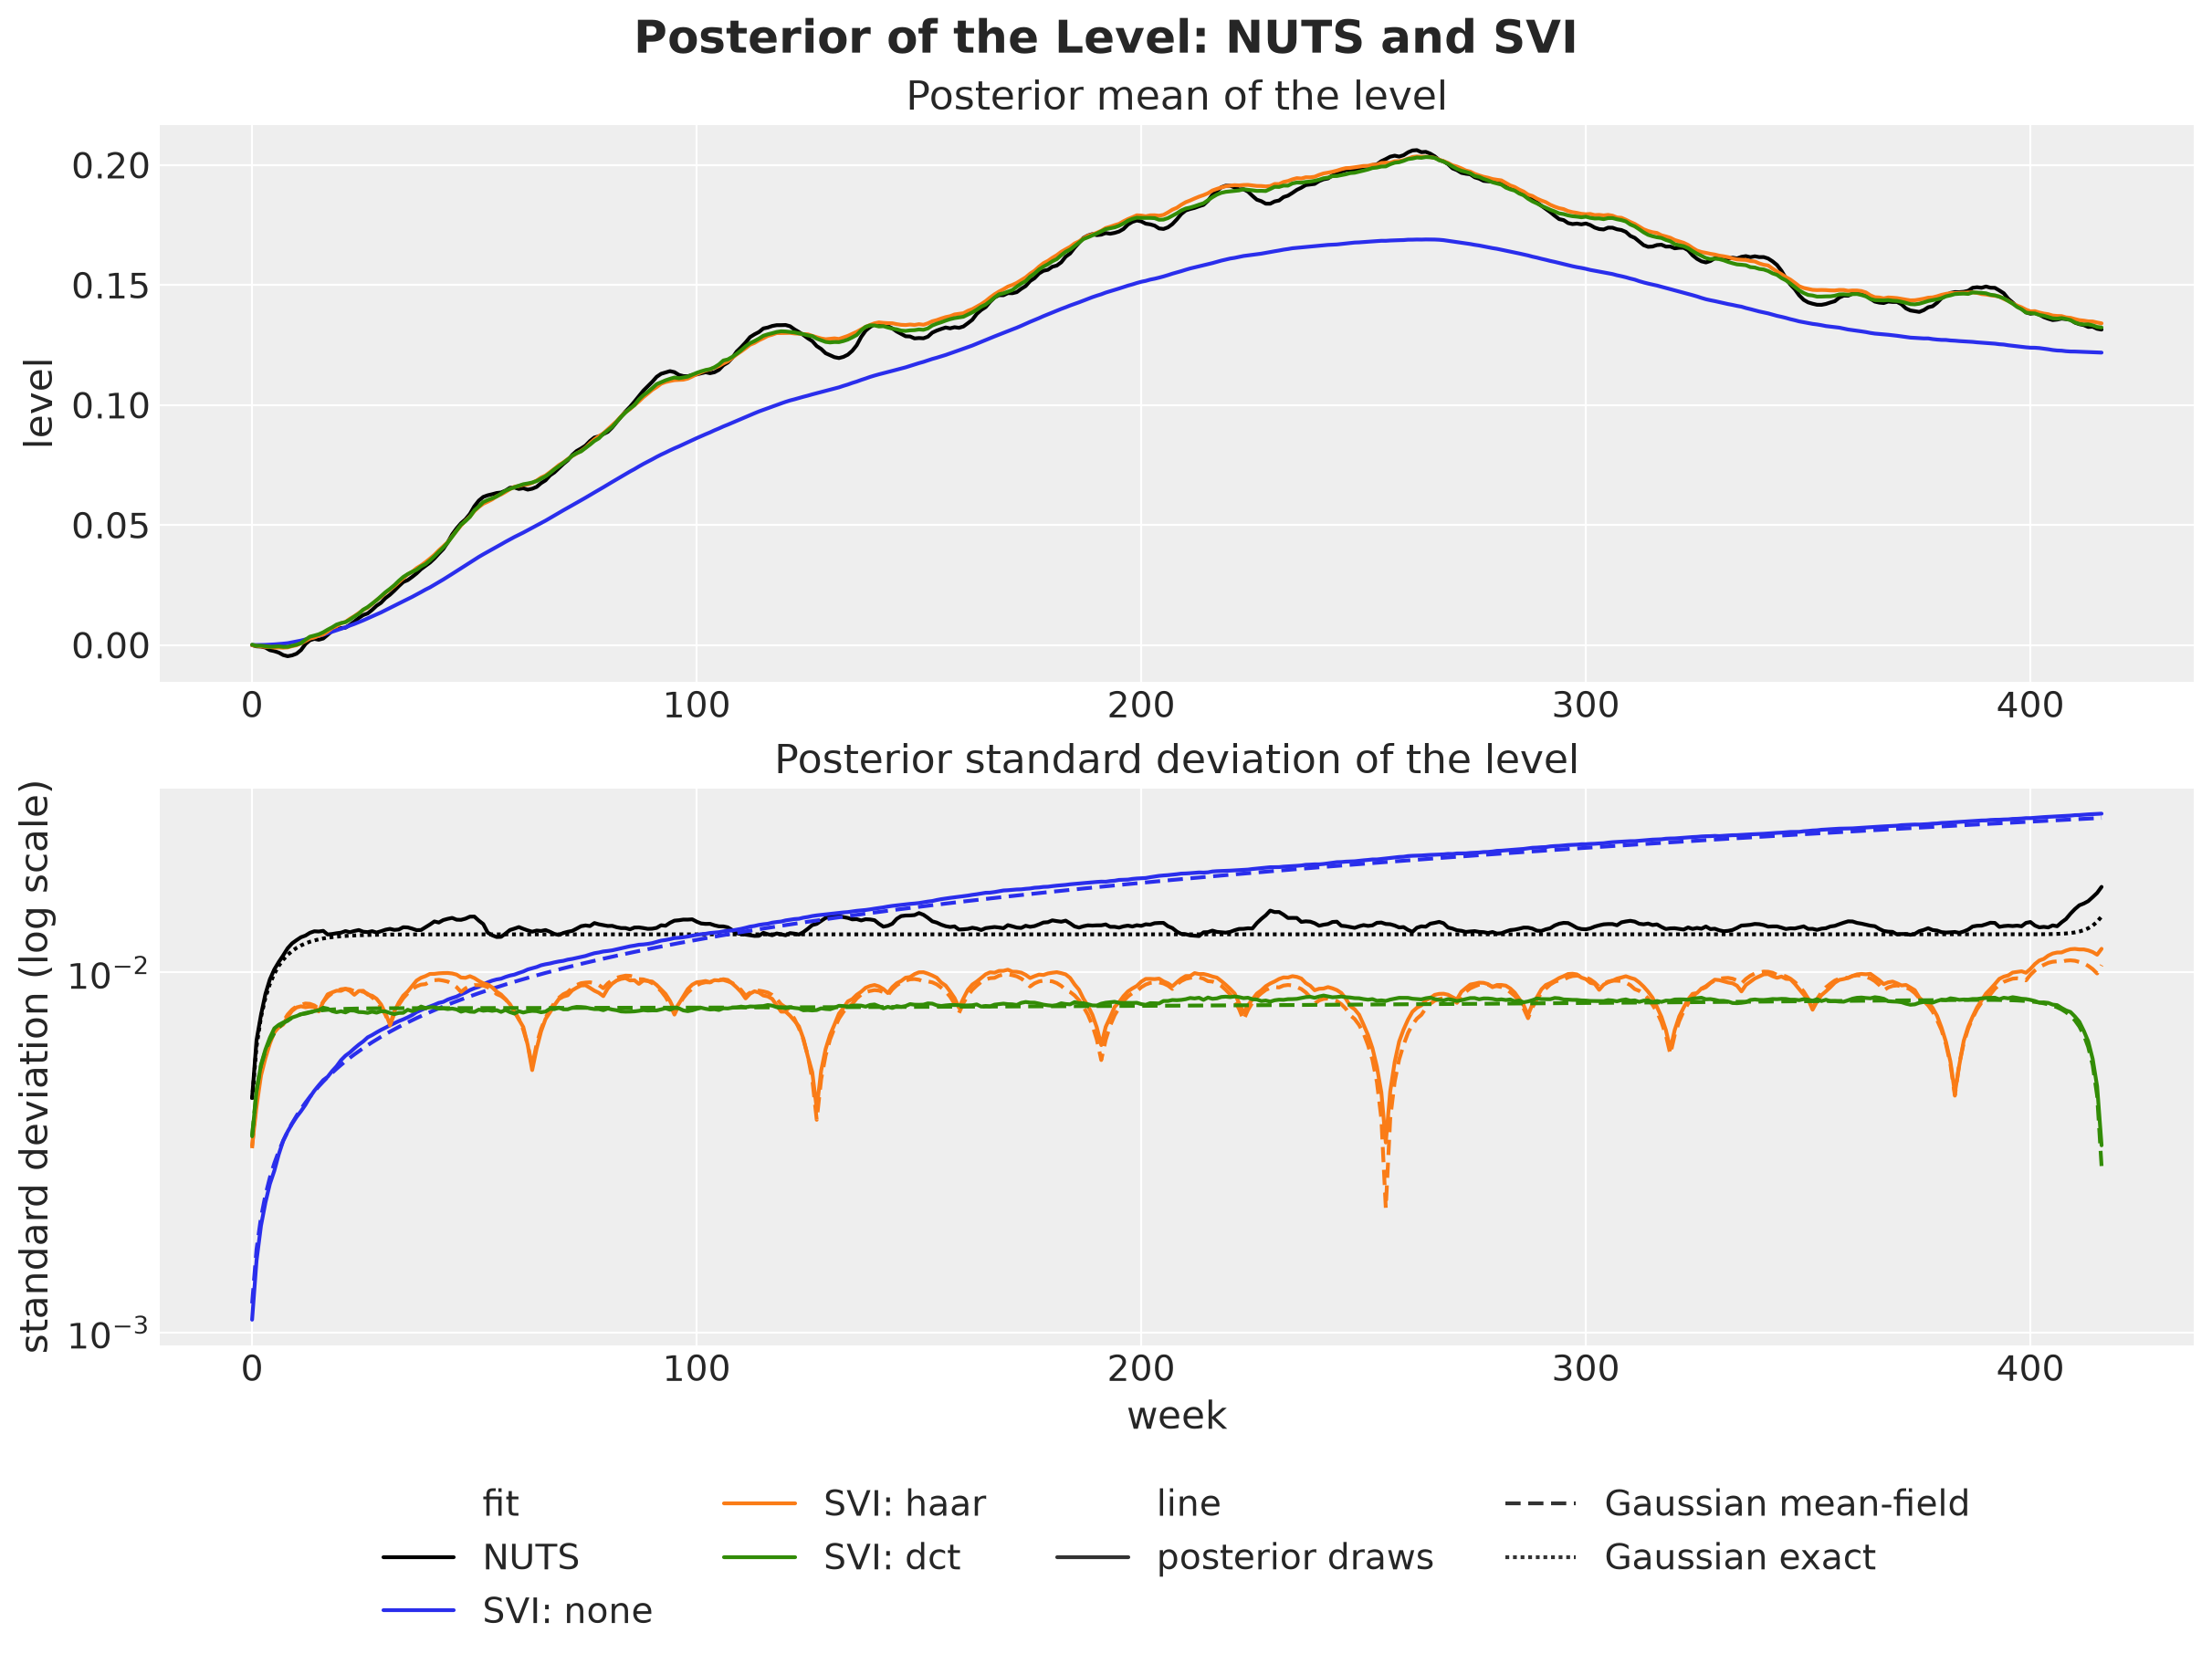

In [42]:
level_draws = {"NUTS": jnp.asarray(nuts_reference["level"])[..., 0]} | {
    f"SVI: {name}": jnp.asarray(posteriors[0]["level"])[..., 0]
    for name, posteriors in svi_posteriors.items()
}


def gaussian_level_sd(
    drift_scale: ScalarLike,
    sigma: ScalarLike,
    nu: ScalarLike,
    rotation: Float[Array, "t t"],
    *,
    mean_field: bool,
    intercept: bool = True,
) -> Float[Array, " t"]:
    "Level sd of a Gaussian local level, exact or under the best mean-field guide."
    t_obs = rotation.shape[0]
    cumsum = jnp.tril(jnp.ones((t_obs, t_obs)))
    # A Student-T observation carries (nu + 1) / (nu + 3) of the information of a
    # Gaussian observation with the same scale.
    noise_scale = sigma * jnp.sqrt((nu + 3) / (nu + 1))
    # The latent variables are the intercept (if any) and the standardized increments.
    num_global = int(intercept)
    design = jnp.hstack([jnp.ones((t_obs, num_global)), drift_scale * cumsum])
    prior_diagonal = jnp.concatenate(
        [jnp.full(num_global, 1 / 10.0**2), jnp.ones(t_obs)]
    )
    precision = jnp.diag(prior_diagonal) + design.T @ design / noise_scale**2
    if mean_field:
        full_rotation = (
            jnp.eye(t_obs + num_global).at[num_global:, num_global:].set(rotation)
        )
        covariance = mean_field_covariance(precision, full_rotation)
    else:
        # The exact covariance does not depend on the rotation.
        covariance = jnp.linalg.inv(precision)
    increments_covariance = covariance[num_global:, num_global:]
    return drift_scale * jnp.sqrt(jnp.diag(cumsum @ increments_covariance @ cumsum.T))


def scale_means(samples: dict[str, Array]) -> tuple[float, float, float]:
    "Posterior means of `drift_scale`, `sigma` and `nu`."
    drift_scale, sigma, nu = (
        float(jnp.asarray(samples[name]).mean()) for name in scalar_names
    )
    return drift_scale, sigma, nu


ridership_rotations = {
    "none": jnp.eye(t_train),
    "haar": transform_matrix(HaarTransform(dim=-1), t_train),
    "dct": transform_matrix(DiscreteCosineTransform(dim=-1), t_train),
}
nuts_scales = scale_means(nuts_reference)
predicted_level_sd = {
    f"SVI: {name}": gaussian_level_sd(
        *scale_means(svi_posteriors[name][0]), rotation, mean_field=True
    )
    for name, rotation in ridership_rotations.items()
}
exact_gaussian_level_sd = gaussian_level_sd(
    *nuts_scales, ridership_rotations["none"], mean_field=False
)

level_means = pl.DataFrame(
    [
        {"week": int(week), "fit": name, "mean": float(value)}
        for name, draws in level_draws.items()
        for week, value in zip(weeks_train, draws.mean(axis=0), strict=True)
    ]
)
level_sds = pl.DataFrame(
    [
        {"week": int(week), "fit": name, "line": line, "standard deviation": float(sd)}
        for name, line, values in [
            *(
                (name, "posterior draws", draws.std(axis=0))
                for name, draws in level_draws.items()
            ),
            *(
                (name, "Gaussian mean-field", values)
                for name, values in predicted_level_sd.items()
            ),
            ("NUTS", "Gaussian exact", exact_gaussian_level_sd),
        ]
        for week, sd in zip(weeks_train, values, strict=True)
    ]
)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), sharex=True)
sns.lineplot(
    data=level_means,
    x="week",
    y="mean",
    hue="fit",
    palette=FIT_COLORS,
    legend=False,
    ax=axes[0],
)
sns.lineplot(
    data=level_sds,
    x="week",
    y="standard deviation",
    hue="fit",
    style="line",
    palette=FIT_COLORS,
    dashes={
        "posterior draws": "",
        "Gaussian mean-field": (4, 2),
        "Gaussian exact": (1, 1),
    },
    ax=axes[1],
)
sns.move_legend(axes[1], "upper center", bbox_to_anchor=(0.5, -0.2), ncol=4)
axes[0].tick_params(labelbottom=True)
axes[0].set(xlabel="week", ylabel="level", title="Posterior mean of the level")
axes[1].set(
    yscale="log",
    xlabel="week",
    ylabel="standard deviation (log scale)",
    title="Posterior standard deviation of the level",
)
fig.suptitle("Posterior of the Level: NUTS and SVI", fontsize=18, fontweight="bold");

The top panel is the posterior mean of the level and the bottom panel its posterior standard deviation, on a log scale. The solid lines are the posterior draws of each fit, the dashed lines are the Gaussian mean-field computation in the color of the fit, and the dotted black line is the exact Gaussian model at the NUTS scales.

We quantify how close the dashed lines are to the fitted guides with the mean absolute relative difference over the training weeks.

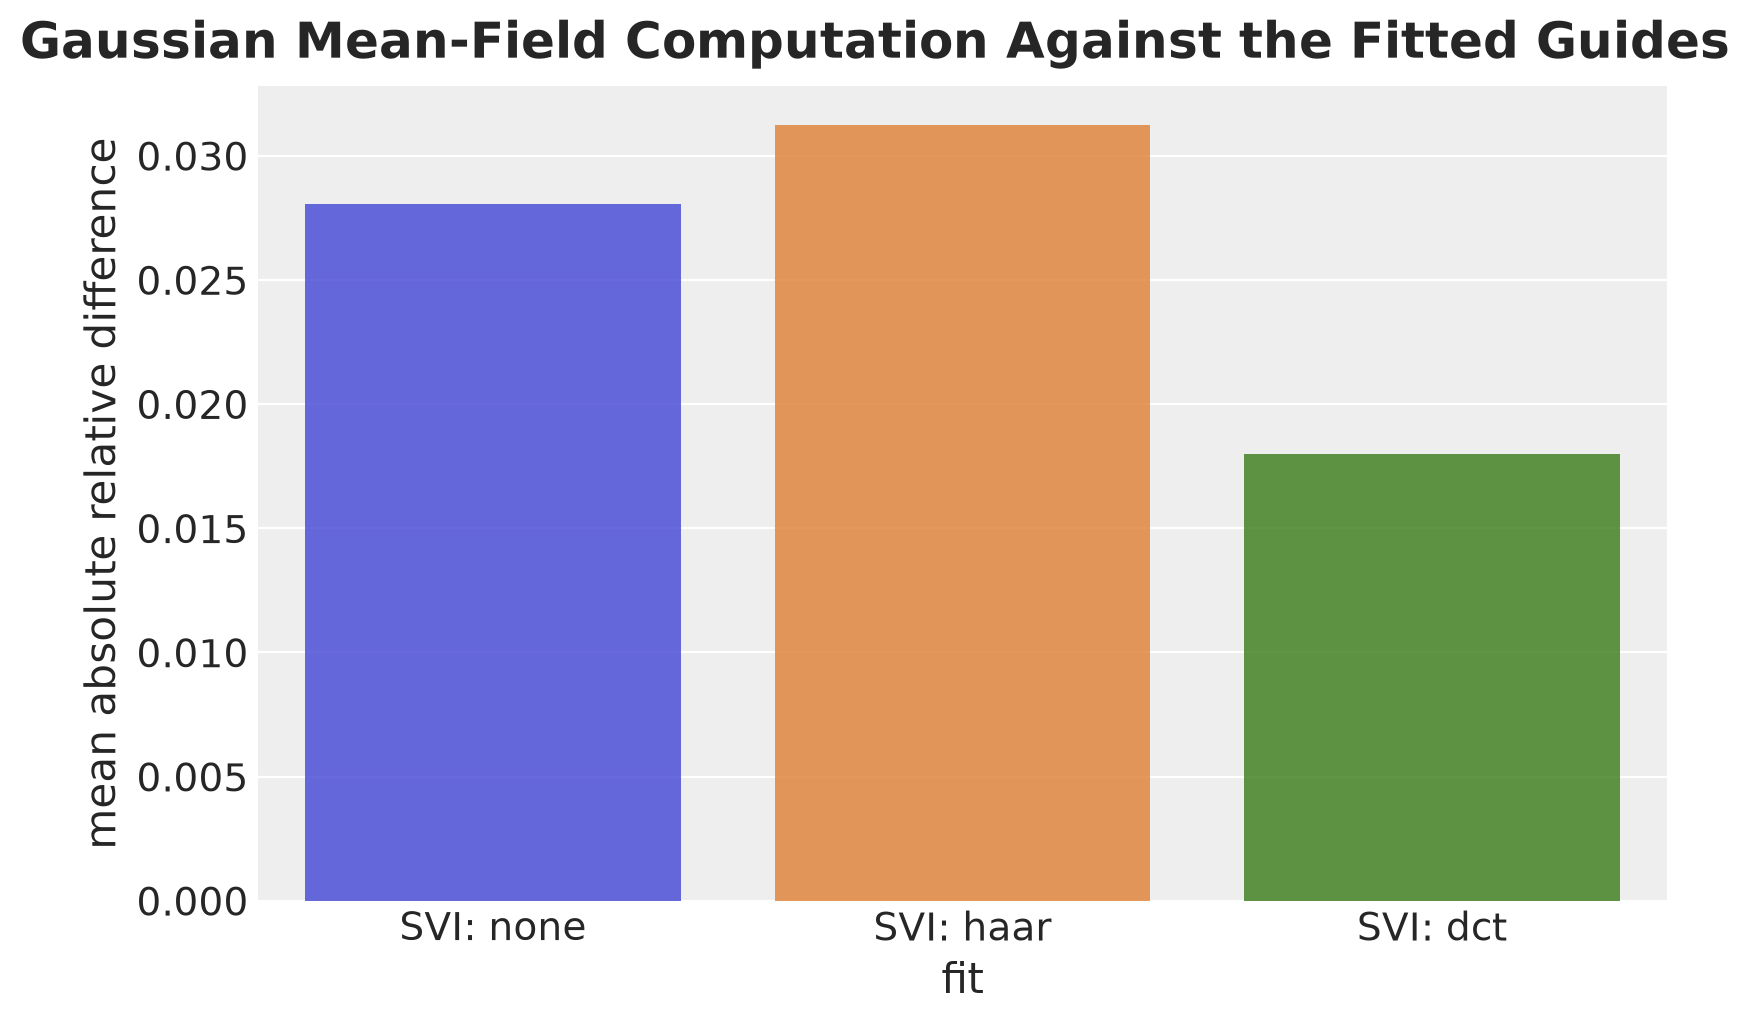

In [43]:
def relative_difference(name: str) -> float:
    "Mean absolute relative difference between the dashed and the solid line of a fit."
    fitted_sd = level_draws[name].std(axis=0)
    return float(jnp.abs(predicted_level_sd[name] / fitted_sd - 1).mean())


relative_differences = pl.DataFrame(
    {
        "fit": list(predicted_level_sd),
        "relative difference": [
            relative_difference(name) for name in predicted_level_sd
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=relative_differences,
    x="fit",
    y="relative difference",
    hue="fit",
    palette=FIT_COLORS,
    alpha=0.8,
    legend=False,
    ax=ax,
)
ax.set(xlabel="fit", ylabel="mean absolute relative difference")
fig.suptitle(
    "Gaussian Mean-Field Computation Against the Fitted Guides",
    fontsize=18,
    fontweight="bold",
);

The bars are all below $4\%$, so the dashed lines are within a few percent of the fitted guides on average. Here is what we see in the figure of the level:

- **The rotated fits recover the path of the level.** Their posterior means follow the NUTS reference. The fit in the original coordinates gives a smoother path that misses the turns.
- **In the original coordinates the uncertainty accumulates.** The standard deviation starts near zero and keeps growing, while the reference is flat after the first weeks.
- **The rotated fits have a flat profile, and it is too low.** The DCT profile is about $40\%$ below the reference, and the Haar profile about $35\%$.
- **The DCT fit collapses in the last weeks.** In the last week its standard deviation is below $0.004$, against $0.017$ for NUTS. The deepest Haar dip is at week $255$, where the level is the sum of the first $256$ increments. This is the first Haar block, and that level depends on the coefficient $z_0$ alone. For $T = 417$ the Haar fit does not collapse at the end.
- **The Gaussian computation follows each fit.** The dashed lines reproduce the three profiles: the growth in the original coordinates, the flat level of the rotated fits, the Haar dips and the DCT collapse. The differences are larger only at the sharpest Haar dips and in the last weeks.
- **The exact Gaussian model is close to NUTS.** At the NUTS scales, the exact standard deviation of the Gaussian model with the intercept is a flat line at about $0.013$, just below the NUTS line, which varies between $0.013$ and $0.015$ away from the ends.

How much of the shortfall is the intercept? We compare the mean-field standard deviation with the exact one at the NUTS scales, with and without the intercept, averaged over the middle of the series (weeks $52$ to $364$).

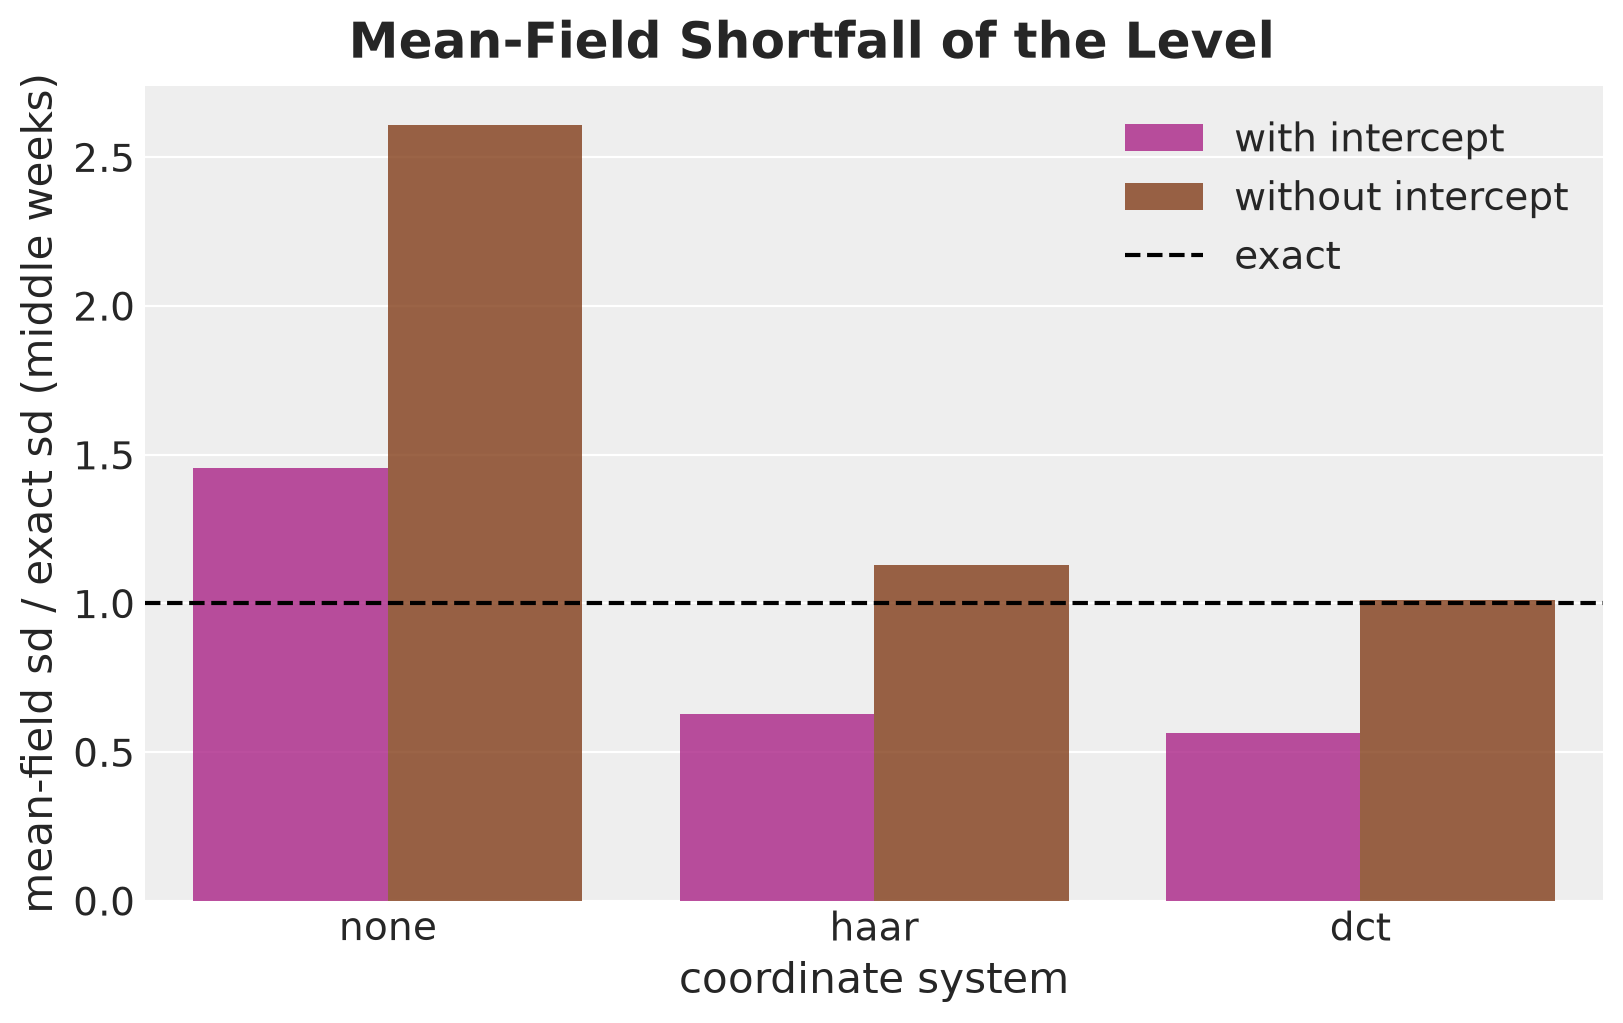

In [44]:
middle = slice(52, 365)


def mean_field_ratio(rotation: Float[Array, "t t"], *, intercept: bool) -> float:
    "Mean-field over exact level sd at the NUTS scales, averaged over the middle weeks."
    exact = gaussian_level_sd(
        *nuts_scales, rotation, mean_field=False, intercept=intercept
    )
    mean_field = gaussian_level_sd(
        *nuts_scales, rotation, mean_field=True, intercept=intercept
    )
    return float((mean_field[middle] / exact[middle]).mean())


mean_field_ratios = pl.DataFrame(
    [
        {
            "coordinates": name,
            "model": model,
            "mean-field / exact": mean_field_ratio(rotation, intercept=intercept),
        }
        for name, rotation in ridership_rotations.items()
        for model, intercept in [("with intercept", True), ("without intercept", False)]
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=mean_field_ratios,
    x="coordinates",
    y="mean-field / exact",
    hue="model",
    palette=["C3", "C4"],
    alpha=0.8,
    ax=ax,
)
ax.axhline(1, color="black", linestyle="--", label="exact")
ax.legend(loc="upper right")
ax.set(xlabel="coordinate system", ylabel="mean-field sd / exact sd (middle weeks)")
fig.suptitle("Mean-Field Shortfall of the Level", fontsize=18, fontweight="bold");

The bars confirm that the intercept explains the flat shortfall. With the intercept, the best mean-field guide gives about $0.6$ of the exact standard deviation in both rotated bases. Without the intercept, the DCT ratio is close to $1$, as in the local level model, and the Haar ratio is about $1.1$, the same excess as in the local level model.

In the original coordinates the ratio is above $1$ in both cases. The mean-field guide is too wide in the middle of the series, as in the local level model.

The data determine the sum $b + \mu_t$ much better than each term, so the exact posterior has a strong negative dependence between the intercept and the level. A mean-field guide cannot represent it, and in the rotated coordinates it makes the level too certain everywhere.

Finally, we look at the forecasts. We generate the in-sample predictions and the $52$-week forecast of every fit and of the NUTS reference.

We score them with the continuous ranked probability score (CRPS), where lower is better. For an introduction to this score see [Intuition behind CRPS](https://juanitorduz.github.io/crps/).

We compute the scores of every fit. Then we plot the mean over the fits (bars) and the score of every fit (points), in sample and out of sample. Thin gray lines connect the three SVI fits that share a random key.

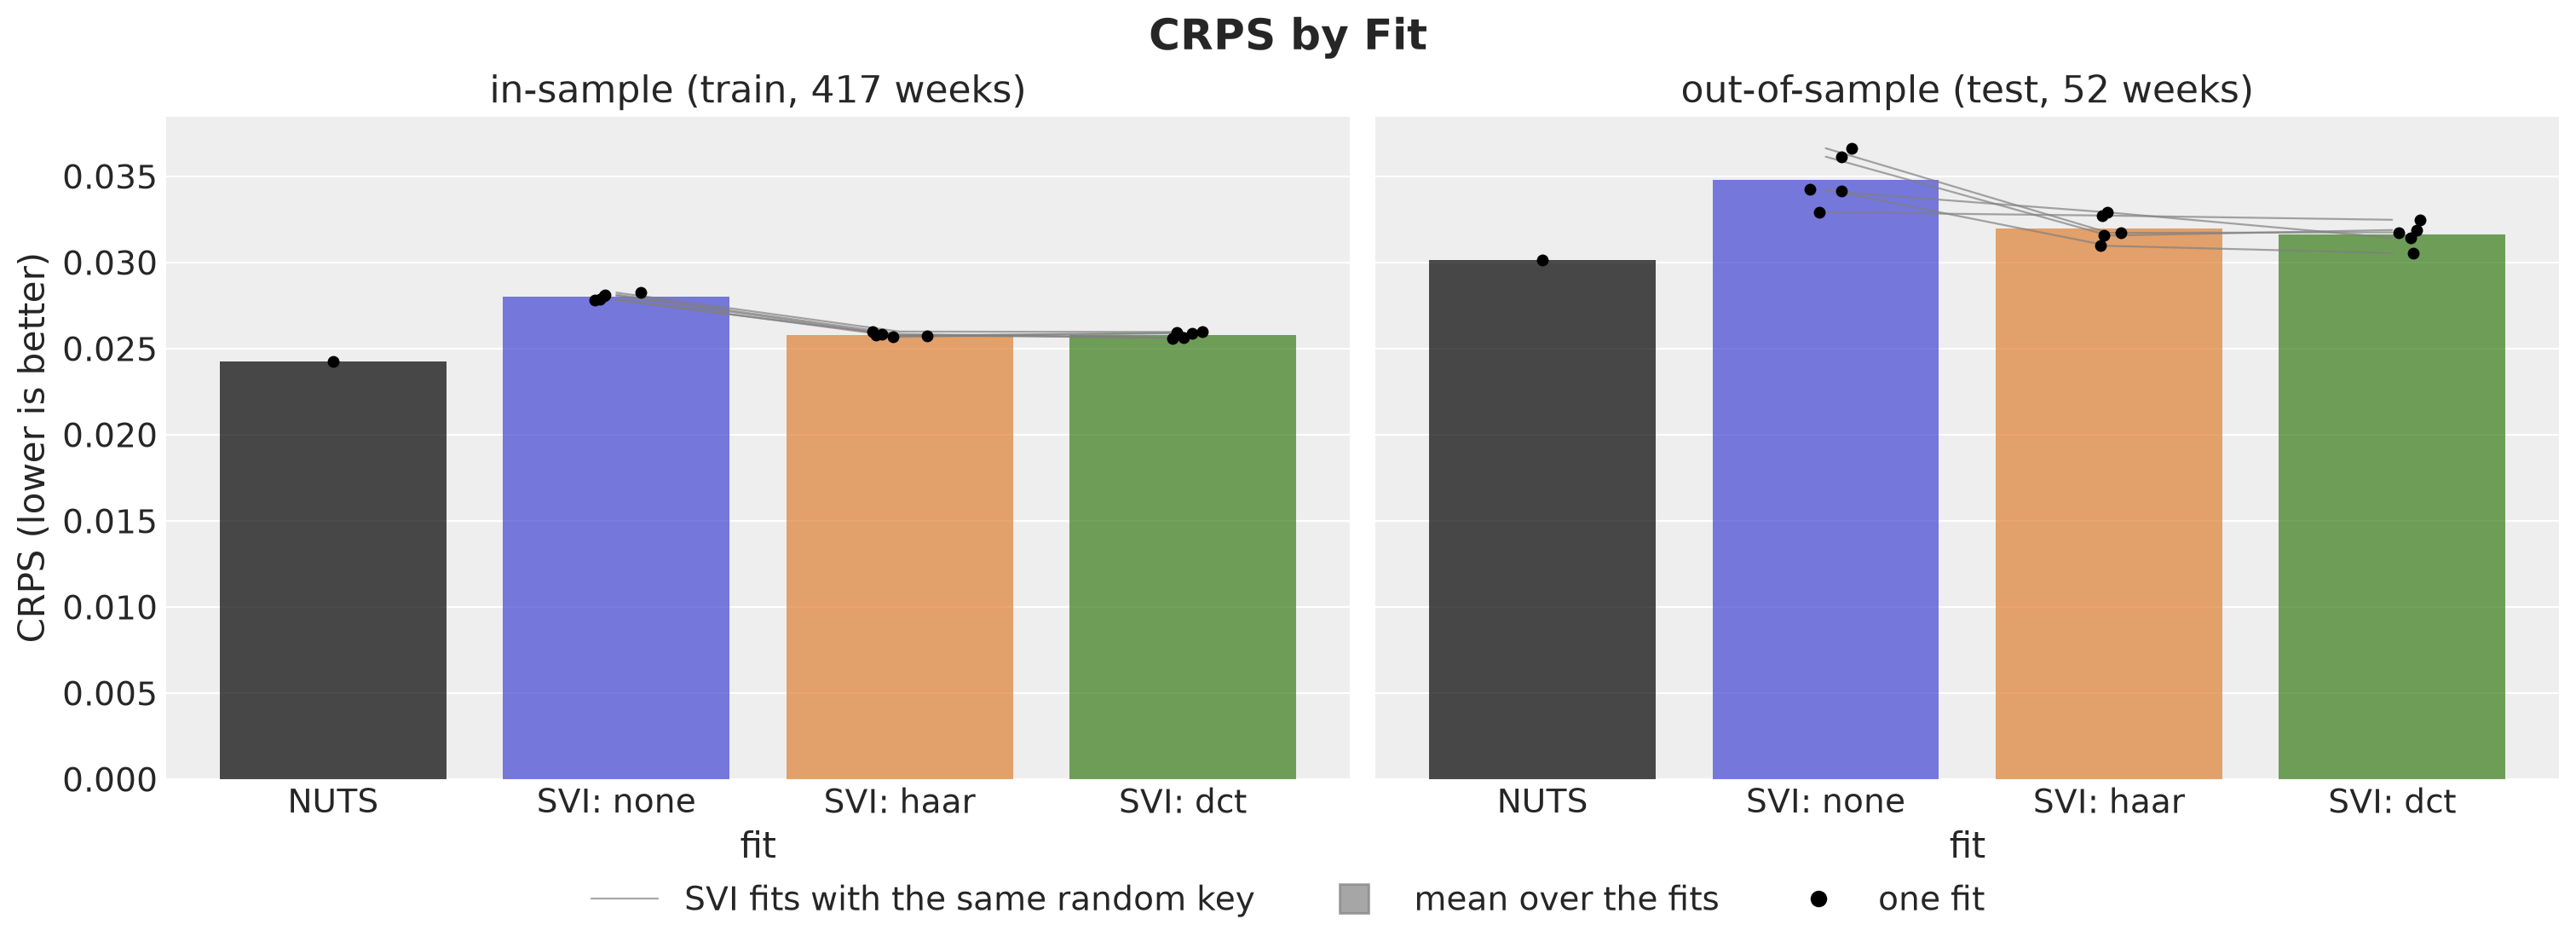

In [45]:
def score(
    rng_key: UInt[Array, "2"], model: Model, posterior: dict[str, Array]
) -> tuple[float, float, Float[Array, "samples horizon 1"]]:
    "In-sample CRPS, out-of-sample CRPS and forecast draws of a posterior."
    key_train, key_test = random.split(rng_key)
    in_sample = predict_in_sample(key_train, model, posterior, covariates_train)
    forecast_draws = forecast(key_test, model, posterior, y_train, covariates)
    return (
        float(eval_crps(in_sample, y_train)),
        float(eval_crps(forecast_draws, y_test)),
        forecast_draws,
    )


rng_key, rng_subkey = random.split(rng_key)
scores = {"NUTS": [score(rng_subkey, models["none"], nuts_reference)]} | {
    f"SVI: {name}": [
        score(rng_subkey, models[name], posterior) for posterior in posteriors
    ]
    for name, posteriors in svi_posteriors.items()
}

sample_labels = ["in-sample (train, 417 weeks)", "out-of-sample (test, 52 weeks)"]
crps_scores = pl.DataFrame(
    [
        {"fit": name, "key": key_index, "sample": sample_label, "CRPS": value}
        for name, runs in scores.items()
        for key_index, run in enumerate(runs)
        for sample_label, value in zip(sample_labels, run[:2], strict=True)
    ]
)
svi_fit_names = [name for name in scores if name != "NUTS"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5.5), sharey=True)

for ax, sample_label in zip(axes, sample_labels, strict=True):
    sample_scores = crps_scores.filter(pl.col("sample") == sample_label)
    sns.barplot(
        data=sample_scores,
        x="fit",
        y="CRPS",
        hue="fit",
        palette=FIT_COLORS,
        alpha=0.7,
        errorbar=None,
        legend=False,
        ax=ax,
    )
    sns.stripplot(data=sample_scores, x="fit", y="CRPS", color="black", ax=ax)

    for key_index in range(len(svi_keys)):
        ax.plot(
            svi_fit_names,
            sample_scores.filter(
                pl.col("key") == key_index, pl.col("fit").is_in(svi_fit_names)
            )["CRPS"],
            color="gray",
            linewidth=0.8,
            alpha=0.7,
            label="SVI fits with the same random key" if key_index == 0 else None,
        )

    ax.plot(
        [], [], "s", color="gray", alpha=0.7, markersize=12, label="mean over the fits"
    )
    ax.plot([], [], "o", color="black", label="one fit")
    ax.set(xlabel="fit", ylabel="CRPS (lower is better)", title=sample_label)

fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=3)
fig.suptitle("CRPS by Fit", fontsize=18, fontweight="bold");

The left panel is the in-sample score, on the $417$ training weeks, and the right panel is the out-of-sample score, on the held-out year. Each bar is the mean over the fits (five for SVI and one for NUTS), and each black point is one fit. Each thin gray line connects the three SVI fits (`none`, `haar` and `dct`) that use the same random key, so its slope shows the effect of the rotation for that key.

- **The rotated fits have a better in-sample score.** Their in-sample CRPS is about $0.026$, between the $0.028$ of the original coordinates and the $0.024$ of NUTS, which is about $8\%$ lower than the original coordinates.
- **The rotated fits forecast better on this split.** The mean out-of-sample CRPS goes from about $0.035$ in the original coordinates to about $0.032$ with both rotations, which is about $8\%$ lower. Every gray line ends lower at both rotated fits, so for each of the five random keys both rotated fits have a lower score than the original fit. The NUTS score is about $0.030$.
- **Haar and DCT are close.** The difference between their means is smaller than the spread over the random keys.
- **The spread over the random keys is not negligible.** The optimizer has a constant step size, so the last iterate is noisy, most of all in the original coordinates, where the out-of-sample CRPS varies between about $0.033$ and $0.037$.

This is one split of one series. It supports the direction of the effect and not a precise size, and we check it with a backtest below.

We end with the forecasts themselves. We use `az.plot_lm` to plot the forecast of the NUTS reference, of the first fit in the original coordinates, and of the first DCT fit.

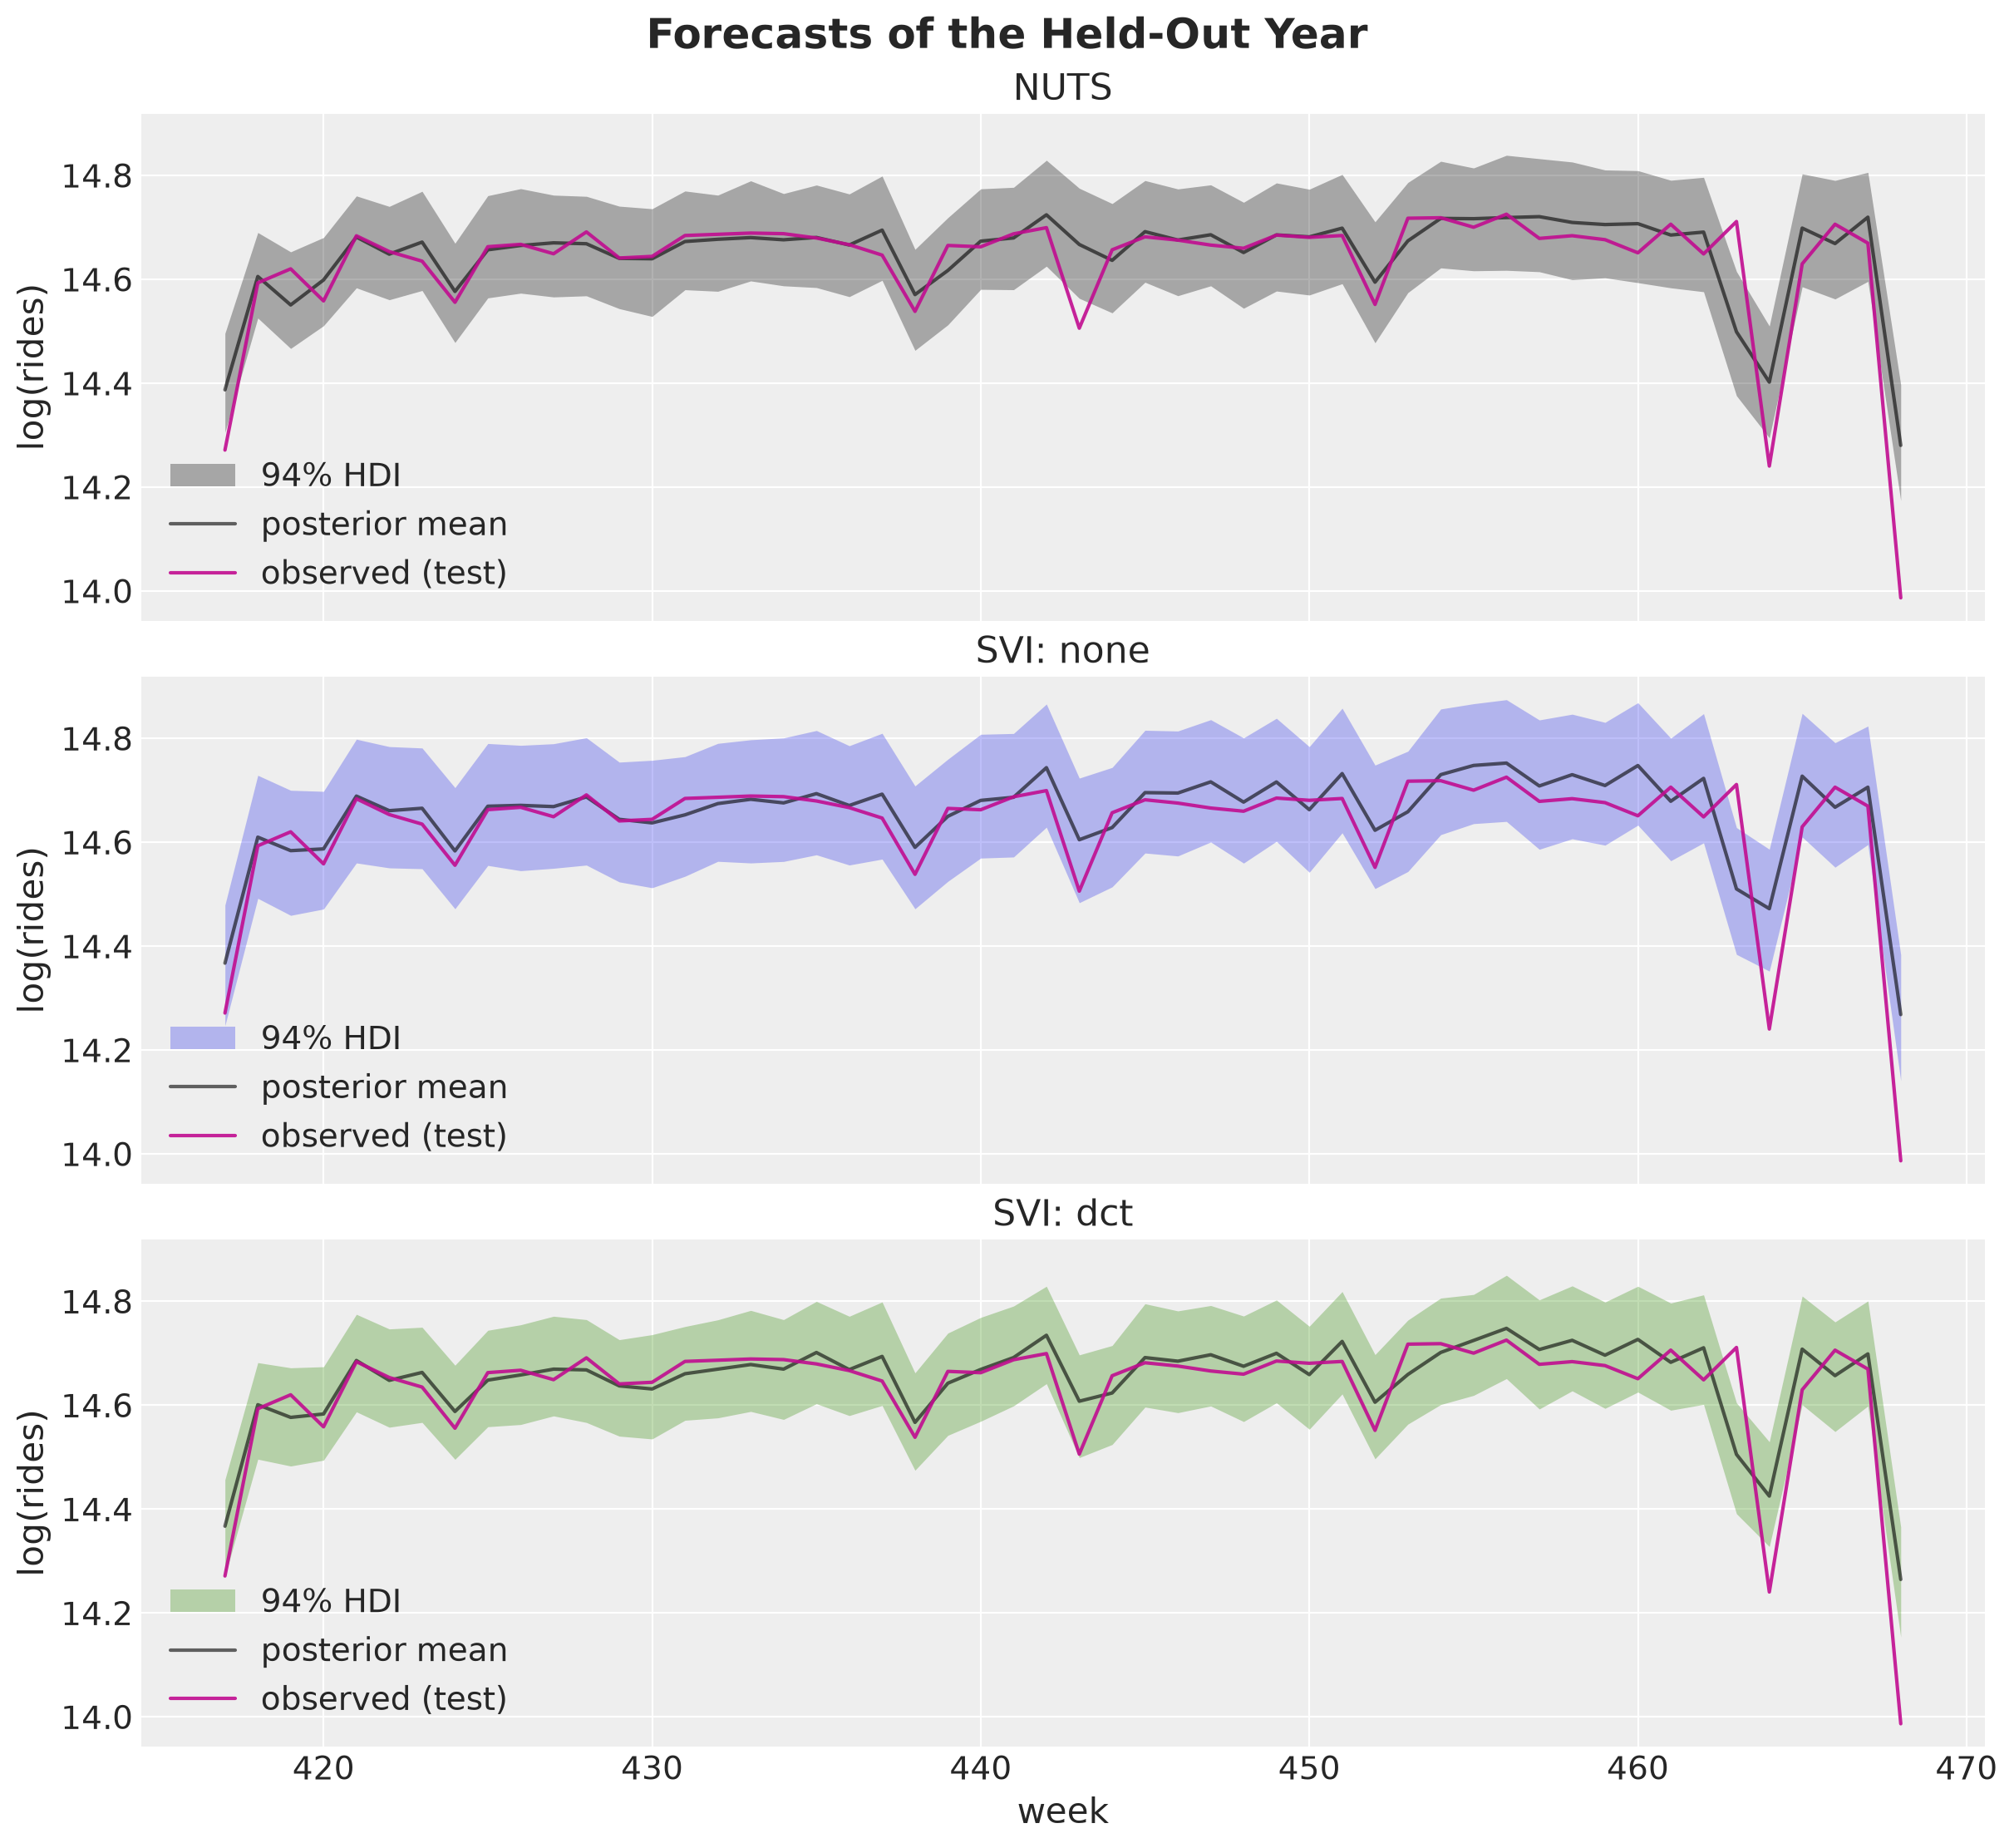

In [46]:
forecast_fits = ["NUTS", "SVI: none", "SVI: dct"]

# `az.plot_lm` draws one panel per variable, and each variable needs its own x variable.
# The three fits have the same number of draws.
forecast_tree = az.from_dict(
    {
        "posterior_predictive": {
            name: np.asarray(scores[name][0][2][..., 0])[None] for name in forecast_fits
        },
        "observed_data": {name: np.asarray(y_test[:, 0]) for name in forecast_fits},
        "constant_data": {
            f"week ({name})": np.asarray(weeks_test, dtype=float)
            for name in forecast_fits
        },
    },
    coords={"time": np.asarray(weeks_test)},
    dims={name: ["time"] for name in forecast_fits}
    | {f"week ({name})": ["time"] for name in forecast_fits},
)

pc = az.plot_lm(
    forecast_tree,
    y=forecast_fits,
    x=[f"week ({name})" for name in forecast_fits],
    ci_kind="hdi",
    ci_prob=HDI_PROB,
    smooth=False,
    color=[FIT_COLORS[name] for name in forecast_fits],
    visuals={
        "pe_line": {"label": "posterior mean"},
        "ci_band": {"alpha": 0.3, "label": "$94\\%$ HDI"},
        "observed_scatter": False,
    },
    col_wrap=1,
    figure_kwargs={"figsize": (12, 11), "sharex": True, "sharey": True},
)
fig = pc.viz["figure"].item()

for ax, name in zip(fig.axes, forecast_fits, strict=True):
    ax.plot(weeks_test, y_test[:, 0], color="C3", alpha=0.9, label="observed (test)")
    ax.set(xlabel="", ylabel="log(rides)", title=name)
    ax.legend(loc="lower left")

fig.axes[-1].set(xlabel="week")
fig.suptitle("Forecasts of the Held-Out Year", fontsize=18, fontweight="bold");

Each panel is the forecast of one fit for the $52$ held-out weeks. The dark line is the posterior mean, the band is the $94\%$ HDI and the magenta line is the observed series.

- **The three forecasts follow the seasonal pattern.** The regression on the Fourier features does this part in every fit.
- **The DCT forecast is closer to the NUTS forecast.** The band of the fit in the original coordinates is wider, consistent with its larger noise scale `sigma`.
- **The largest holiday drops are outside every band.** The heavy-tailed likelihood treats them as outliers.

### Backtest

A single train-test split scores one held-out year. A rolling-origin backtest gives a broader picture: we move the train-test boundary forward, refit, and forecast the next window, so that several later years of the series are scored out of sample. We follow the [univariate forecasting example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html) of `numpyro_forecast` and use its function `backtest` with an expanding window.

Each fold trains on all the weeks up to its split point and forecasts the next $52$ weeks. The first fold trains on $104$ weeks (two years), and the split point moves forward by $52$ weeks, so the test windows do not overlap. With `eval_train=True`, `backtest` also scores the in-sample predictions of each fold.

In every fold and coordinate system we fit the same `AutoNormal` guide as before, with `bias` initialized at the mean of the training window.

The closures `forecast_fn` and `in_sample_fn` return the forecast and the in-sample predictions of a fold. `backtest` calls the two closures with different random keys.

`fit_window` therefore caches the posterior of each window, so both scores come from the same fit. This is $7$ folds and $3$ coordinate systems, so $21$ fits in total.

In [47]:
fitted_windows: dict[tuple[int, int], dict[str, Array]] = {}


def fit_window(
    rng_key: UInt[Array, "2"],
    model: ForecastModel,
    train_data: Float[Array, "t_train 1"],
    train_covariates: Float[Array, "t_train features"],
    num_samples: int,
) -> dict[str, Array]:
    "Fit a mean-field guide on one training window once, and draw from it."
    window = (id(model), train_data.shape[0])
    if window not in fitted_windows:
        key_fit, key_posterior = random.split(rng_key)
        guide = AutoNormal(
            model, init_loc_fn=init_to_value(values={"bias": train_data.mean()})
        )
        svi = SVI(model, guide, Adam(step_size=0.005), Trace_ELBO())
        result = svi.run(
            key_fit, NUM_STEPS, train_covariates, train_data, progress_bar=False
        )
        fitted_windows[window] = draw_posterior(
            key_posterior, guide, result.params, num_samples
        )
    return fitted_windows[window]


def forecast_fn(
    rng_key: UInt[Array, "2"],
    model: ForecastModel,
    train_data: Float[Array, "t_train 1"],
    train_covariates: Float[Array, "t_train features"],
    full_covariates: Float[Array, "t_full features"],
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Float[Array, "samples horizon 1"]:
    "Forecast the test window of a fold from its cached fit."
    key_fit, key_forecast = random.split(rng_key)
    posterior = fit_window(key_fit, model, train_data, train_covariates, num_samples)
    return forecast(
        key_forecast,
        model,
        posterior,
        train_data,
        full_covariates,
        batch_size=batch_size,
    )


def in_sample_fn(
    rng_key: UInt[Array, "2"],
    model: ForecastModel,
    train_data: Float[Array, "t_train 1"],
    train_covariates: Float[Array, "t_train features"],
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Float[Array, "samples t_train 1"]:
    "Predict the training window of a fold from its cached fit."
    key_fit, key_predict = random.split(rng_key)
    posterior = fit_window(key_fit, model, train_data, train_covariates, num_samples)
    return predict_in_sample(
        key_predict, model, posterior, train_covariates, batch_size=batch_size
    )


rng_key, rng_subkey = random.split(rng_key)
fitted_windows.clear()
backtest_results = {
    name: backtest(
        rng_subkey,
        lambda model=model: model,
        data,
        covariates,
        forecast_fn=forecast_fn,
        in_sample_fn=in_sample_fn,
        metrics={"crps": eval_crps},
        test_window=52,
        stride=52,
        min_train_window=104,
        num_samples=1_000,
        eval_train=True,
    )
    for name, model in models.items()
}

We plot the CRPS of every fold and, in the last group, the mean over the folds. The top panel is the in-sample CRPS and the bottom panel the out-of-sample CRPS. Each group of bars is one fold, labeled by the week of its split point, and each bar is one coordinate system.

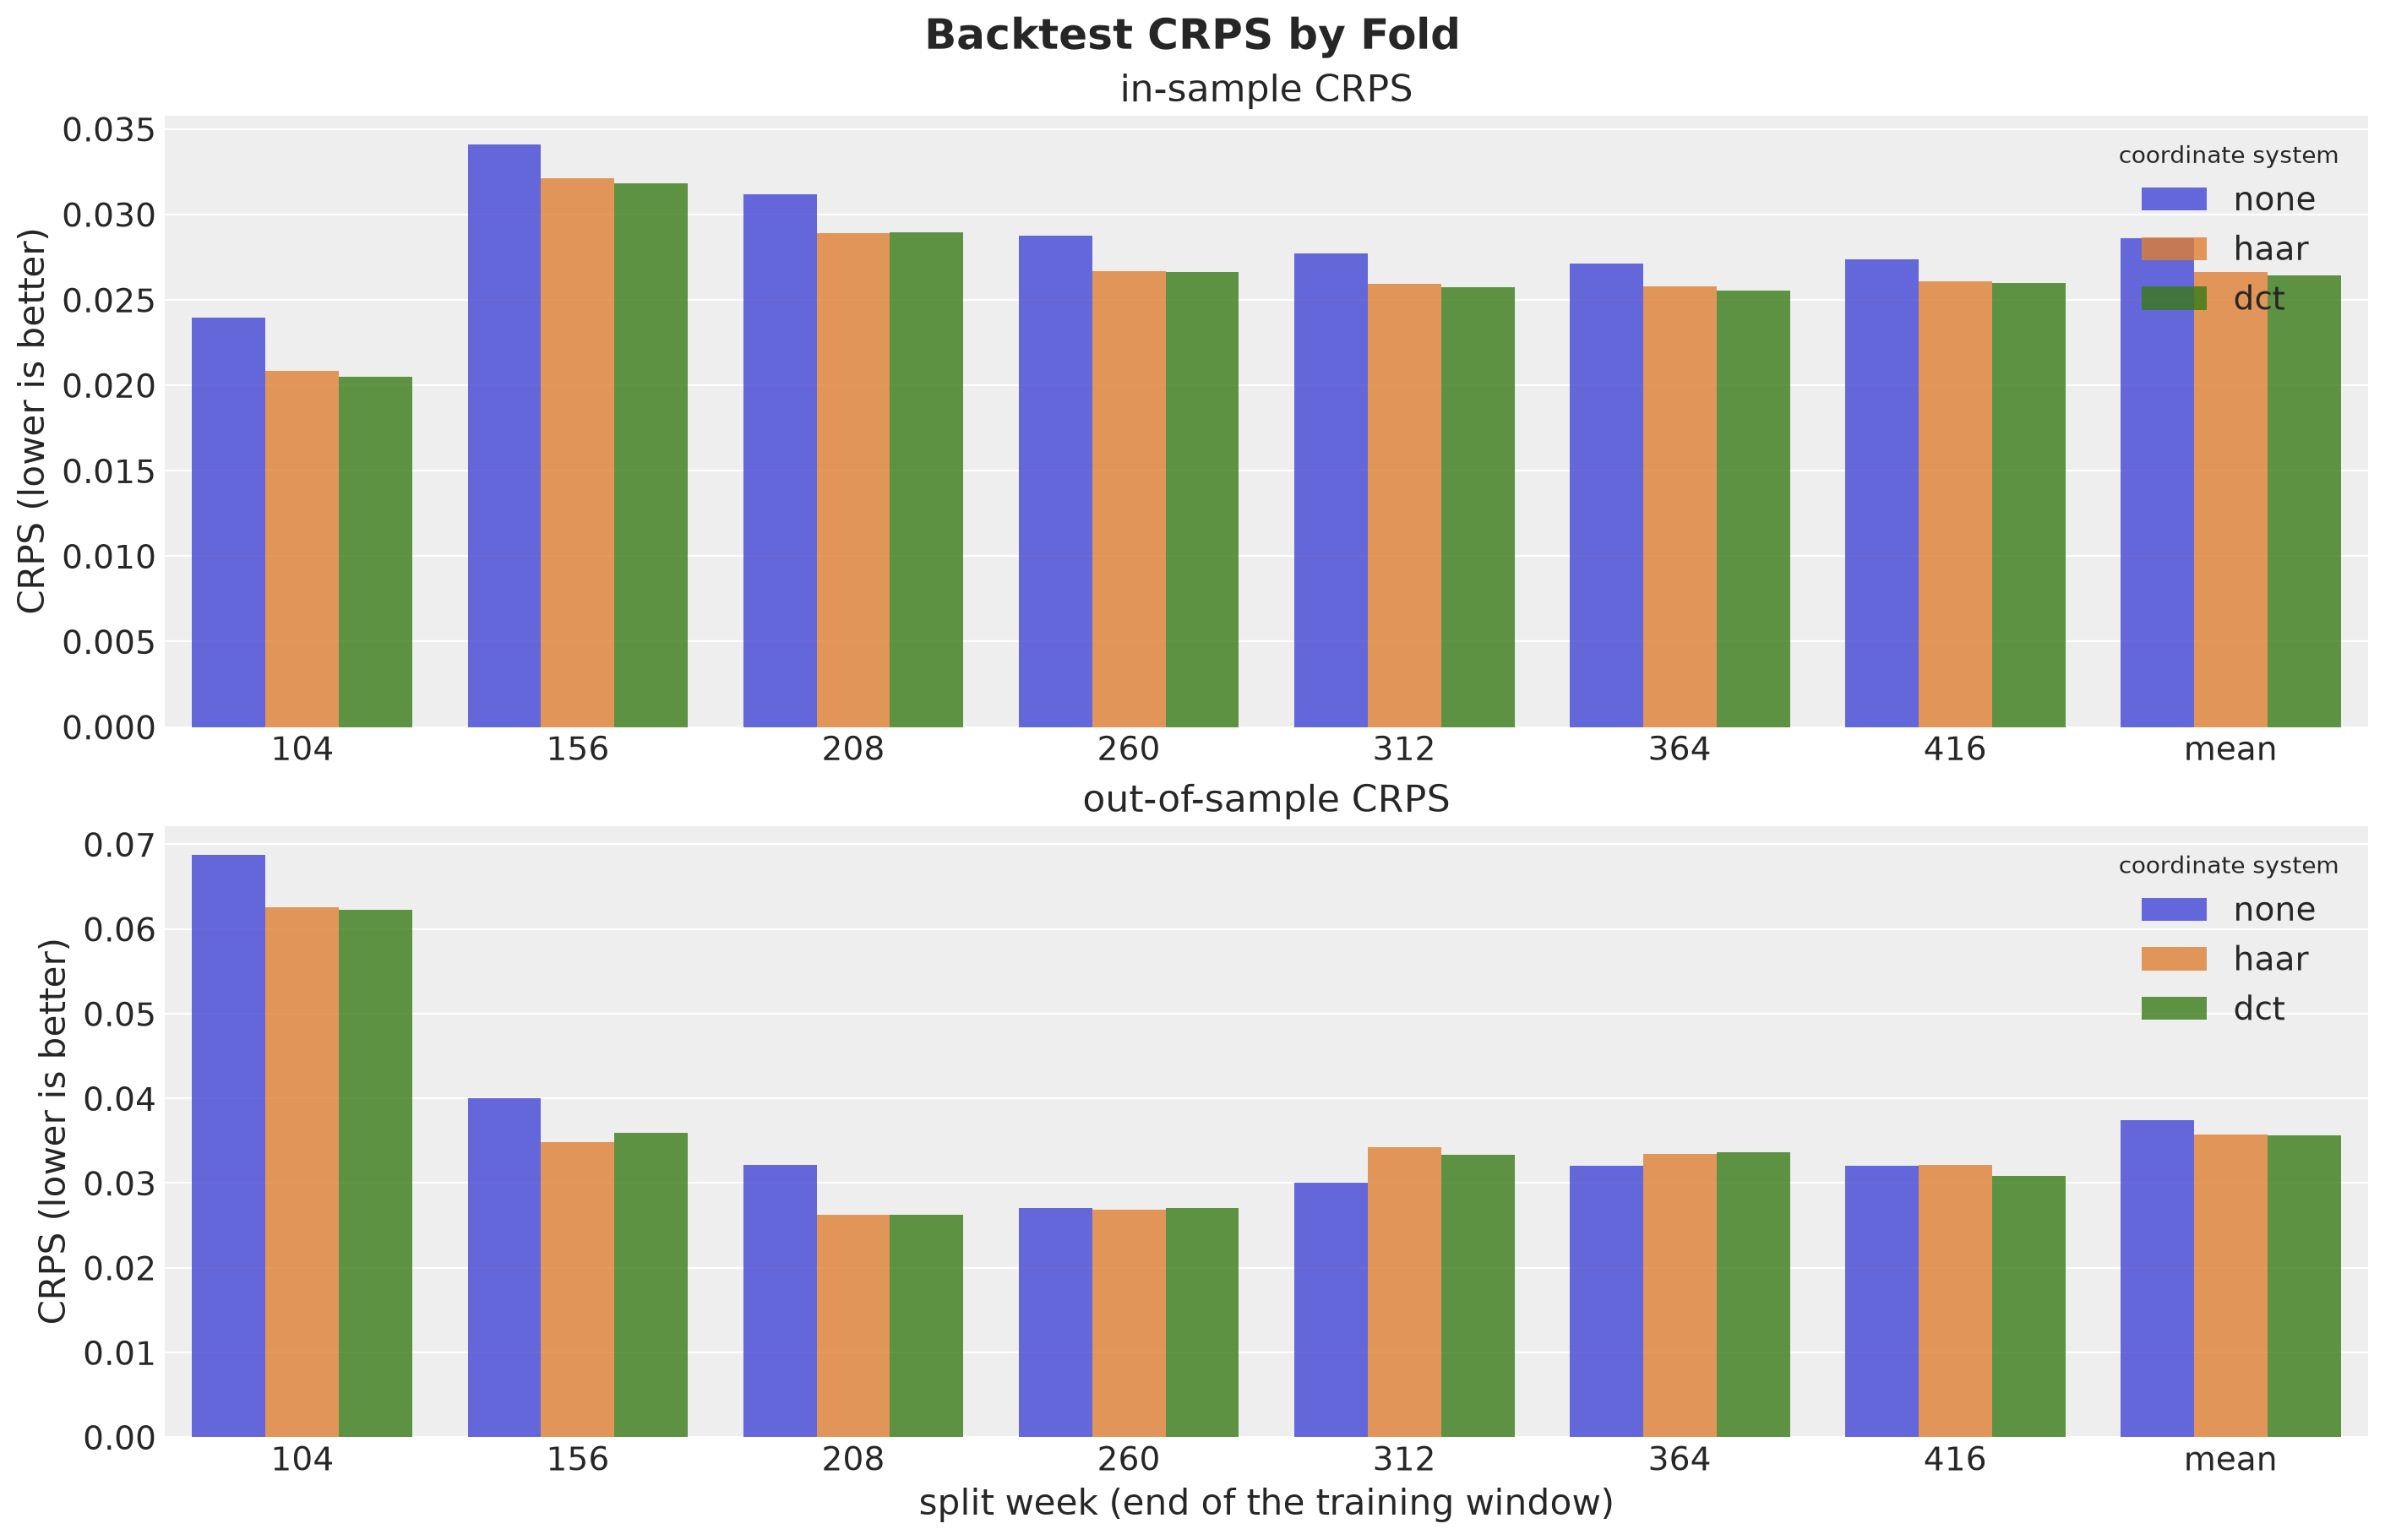

In [48]:
backtest_crps = pl.DataFrame(
    [
        {
            "split week": str(result.t1),
            "coordinates": name,
            "sample": sample,
            "CRPS": value,
        }
        for name, results in backtest_results.items()
        for result in results
        for sample, value in [
            ("in-sample", result.train_metrics["crps"]),
            ("out-of-sample", result.metrics["crps"]),
        ]
    ]
)
backtest_means = (
    backtest_crps.group_by(["coordinates", "sample"], maintain_order=True)
    .agg(pl.col("CRPS").mean())
    .with_columns(pl.lit("mean").alias("split week"))
)
backtest_crps = pl.concat([backtest_crps, backtest_means.select(backtest_crps.columns)])

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 9), sharex=True)

for ax, sample in zip(axes, ["in-sample", "out-of-sample"], strict=True):
    sns.barplot(
        data=backtest_crps.filter(pl.col("sample") == sample),
        x="split week",
        y="CRPS",
        hue="coordinates",
        palette=COLORS,
        alpha=0.8,
        ax=ax,
    )
    ax.tick_params(labelbottom=True)
    ax.set(xlabel="", ylabel="CRPS (lower is better)", title=f"{sample} CRPS")
    ax.legend(title="coordinate system", loc="upper right")

axes[1].set(xlabel="split week (end of the training window)")
fig.suptitle("Backtest CRPS by Fold", fontsize=18, fontweight="bold");

Here is what we see in the backtest.

- **In sample, the rotated fits are better in every fold.** Their mean in-sample CRPS over the folds is about $0.027$ with both bases, against about $0.029$ in the original coordinates, which is about $7\%$ to $8\%$ lower. This matches the single split, and it follows from the better ELBO.
- **Out of sample, the gain is smaller and not uniform.** The mean out-of-sample CRPS over the folds is about $0.037$ in the original coordinates and about $0.036$ with both bases, which is about $4\%$ to $5\%$ lower. The rotated fits are better in the folds that end at weeks $104$, $156$ and $208$, about equal at week $260$, and worse at weeks $312$ and $364$. At week $416$ the Haar fit is equal and the DCT fit is better.
- **The first fold is the hardest.** With only two years of training data, its out-of-sample CRPS is about twice that of the later folds, in every coordinate system.

The fold that ends at week $416$ is the split of the previous section with one week less of training data, a test window one week earlier, $1000$ instead of $4000$ draws and a different random key. Its out-of-sample CRPS in the original coordinates is about $0.032$, below the spread of $0.033$ to $0.037$ of the five fits of the previous section. The gain on a single split is of the same order as the run-to-run variation.

Each fold uses one random key, and the spread over keys on the single split is of the same order as some of these differences. The backtest therefore supports a clear in-sample gain, and a small out-of-sample gain on average rather than in every year.

## Conclusion

We studied the Haar and DCT reparameterizations of time-indexed latent variables: what they are, why they help, and how to apply them in NumPyro.

### Key Findings

- **It is a rotation, not a new model.** The reparameterization samples the coefficients of the latent variables in an orthonormal basis. The Jacobian determinant is one, so the log density is the same and only the coordinates change.
- **The posterior of a random walk is coupled along time.** The data constrain the smooth combinations of the increments and leave the oscillating ones at the prior. For $256$ time steps the condition number of the posterior precision is about $1057$.
- **The gain for mean-field SVI is large.** In the local level model the gap of the best mean-field guide drops from $187$ nats to $7.4$ (Haar) and $1.4$ (DCT), and fitted guides reproduce these numbers. In the ridership model the ELBO improves by about $77$ (Haar) and $82$ (DCT) nats, and the scale estimates move toward the NUTS reference.
- **The forecast gain is smaller than the in-sample gain.** On the held-out year the out-of-sample CRPS is about $8\%$ lower, within the spread over random keys. In a backtest over seven yearly folds the rotated fits have an in-sample CRPS about $7\%$ to $8\%$ lower on average, and lower in every fold, and an out-of-sample CRPS about $4\%$ to $5\%$ lower on average, with mixed results between folds.
- **The errors of the mean-field guide are predictable.** In the original coordinates the uncertainty of the level accumulates along the series and the scale of the increments is too small. In the rotated coordinates the coarse coefficients stay coupled: the level is too certain at the end of the series with the DCT and at the ends of the Haar blocks. With an intercept the level is too certain everywhere. A Gaussian computation at the fitted scales, with the noise scale adjusted for the Student-T likelihood, reproduces the level uncertainty of the fitted guides in the ridership model.

### Model Limitations

- **The theory is Gaussian.** The exact results are for a Gaussian model with fixed scales. With unknown scales and a heavy-tailed likelihood they give the direction of the bias in the scale estimates, not its size.
- **The bases are approximate.** The coarsest coefficients remain strongly coupled, and a mean-field guide underestimates the uncertainty of the level where it depends on them, for the DCT most of all at the forecast origin.
- **Only the coupling along time is addressed.** The dependence between the global parameters and the latent path is still there. It makes the level too certain and the variational posterior of `drift_scale` much too narrow.
- **The optimization problem changes.** With the default initialization and the step size of the original coordinates, some rotated fits did not converge in $50000$ steps. A decaying step size removed the slow phase on this model, and we did not tune it further.
- **The models are small.** The transform is a large part of the cost of each gradient. The timings depend on the machine, and they say little about larger models.
- **The forecast evaluation covers one series.** The backtest uses one random key per fold, and some of its out-of-sample differences are of the same order as the optimizer noise.
- **NUTS is only a reference.** We use it to judge the variational fits in the original coordinates, and we do not measure the effect of the rotation on NUTS.

### Recommendations

1. **Use `time_reparam` with mean-field guides.** For a model with a random-walk latent path that we fit with `AutoNormal`, we try `time_reparam(model, "dct")` and `time_reparam(model, "haar")`. It is one line and it leaves the model code as it is.
2. **Compare the two bases.** The DCT had the best ELBO in both models. The Haar basis was close, its forecasts were as good, and its transform was cheaper.
3. **Revisit the initialization and the optimizer.** In the rotated coordinates the fits with the default initialization did not converge at the step size of the original coordinates. Initialize the global location parameters, or start with a larger step size and decay it, as in the takeaways of the Variational Inference section.
4. **Check the uncertainty of the level.** The rotated mean-field guides make the level too certain, most of all at the forecast origin with the DCT.
5. **Measure before using it with NUTS.** We expect fewer leapfrog steps per draw and a higher cost per step, as we explain below. Compare the effective sample size per second with a run in the original coordinates before adopting it.
6. **Keep a NUTS reference.** A better ELBO does not show how much bias is left. A comparison of the scales against NUTS does.

### Expectations for NUTS

We did not measure NUTS in the rotated coordinates, but the geometry of the local level model tells us what to expect. NUTS samples from the exact posterior, so the coupling along time does not bias it. Instead, it makes NUTS slow: the narrowest direction of the posterior limits the step size, and the widest direction sets the length of a trajectory ([Neal, 2011](https://arxiv.org/abs/1206.1901)). The function `time_reparam` works with NUTS in the same way as with SVI, and Pyro's `HMCForecaster` has the same `time_reparam` argument. Here is what we expect from the rotation:

- **The gain comes from a diagonal mass matrix.** HMC with an identity mass matrix behaves the same in every orthonormal basis, because its kinetic energy does not change under a rotation. NumPyro, Stan and PyMC adapt a diagonal mass matrix by default. It rescales each coordinate but cannot remove the correlations between them, so in the original coordinates the sampler still sees the elongated ellipsoid. In the rotated coordinates the correlations are weaker, and we expect larger steps and fewer leapfrog steps per draw.
- **Each leapfrog step costs more.** Every step evaluates the gradient through the transform. In a small model the transform is a large part of the gradient, so fewer leapfrog steps do not always mean less time. The Haar transform costs $O(T)$ operations and the DCT $O(T \log T)$.
- **The coarse coefficients stay coupled.** As for the mean-field guide, the rotation does not decouple the first coefficients from each other or from global parameters such as the intercept. We expect the coordinates that depend on them, such as the last levels in the DCT basis, to mix the slowest.
- **Dense and low-rank mass matrices reduce the gain.** A dense mass matrix (`dense_mass=True` in NumPyro) learns the coupling during warmup, at a cost of $O(T^2)$ operations per leapfrog step. A diagonal mass matrix plus a low-rank correction captures the strongest correlations at a cost close to the diagonal case. [nutpie](https://pymc-devs.github.io/nutpie/sampling-options.html) offers this adaptation as an experimental option, based on the Fisher divergence ([Seyboldt, Carlson and Carpenter, 2026](https://arxiv.org/abs/2603.18845)), and BlackJAX has a similar adaptation, `window_adaptation_low_rank` (see [blackjax#847](https://github.com/blackjax-devs/blackjax/pull/847)). These mass matrices learn some of the correlations that the rotation removes, so we expect a smaller gain from the rotation with them.

## Next Steps

1. **Implement the exact basis.** For white increments under a cumulative sum the true axes are the rows of the DCT of type VIII, for every value of the scales. A transform with these rows makes the Gaussian local level model exact.
2. **Add structure for the coarse coefficients.** A low-rank or a full-rank block for the first few coefficients and the global parameters, the intercept above all, should address the remaining couplings and the uncertainty of the level.
3. **Test a panel of series.** In a hierarchical model the `time` plate is next to a plate of series, and `time_reparam` rotates all the series at once.
4. **Benchmark NUTS.** Measure the leapfrog steps and the effective sample size per second in the three coordinate systems, on small and on large models, to test the expectations of the previous subsection. Compare the rotation with dense and low-rank mass matrices, and with a combination of the two.

## References

- Pyro. [Forecasting I: univariate, heavy tailed](https://pyro.ai/examples/forecasting_i.html). Pyro tutorials.
- Pyro. [Forecasting](https://docs.pyro.ai/en/stable/contrib.forecast.html) and [Reparameterizers](https://docs.pyro.ai/en/stable/infer.reparam.html). Pyro documentation.
- NumPyro. [Reparameterizers](https://num.pyro.ai/en/stable/reparam.html). NumPyro documentation.
- [numpyro#2208](https://github.com/pyro-ppl/numpyro/pull/2208): Add `HaarTransform` and `DiscreteCosineTransform`.
- [numpyro_forecast#135](https://github.com/juanitorduz/numpyro_forecast/pull/135): Add `time_reparam`, the Haar and DCT time-axis reparameterization.
- [numpyro_forecast](https://github.com/juanitorduz/numpyro_forecast): [Univariate forecasting](https://juanitorduz.github.io/numpyro_forecast/docs/examples/forecasting_univariate.html) and [Comparing inference methods](https://juanitorduz.github.io/numpyro_forecast/docs/examples/inference_methods_comparison.html).
- nutpie. [Sampling options](https://pymc-devs.github.io/nutpie/sampling-options.html). nutpie documentation.
- [blackjax#847](https://github.com/blackjax-devs/blackjax/pull/847): Low-rank mass matrix adaptation (nutpie-aligned).
- statsmodels. [`UnobservedComponents`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.structural.UnobservedComponents.html). statsmodels documentation.
- Wikipedia. [Haar wavelet](https://en.wikipedia.org/wiki/Haar_wavelet).
- Strang, G. (1999). [The Discrete Cosine Transform](https://epubs.siam.org/doi/10.1137/S0036144598336745). *SIAM Review*, 41(1), 135-147.
- Turner, R. E. and Sahani, M. (2011). [Two problems with variational expectation maximisation for time-series models](https://www.semanticscholar.org/paper/Two-problems-with-variational-expectation-for-Turner-Sahani/aaca093827e826a1118a4d2a93b0e42a09308be7). In *Bayesian Time Series Models*, Cambridge University Press.
- Lange, K. L., Little, R. J. A. and Taylor, J. M. G. (1989). [Robust Statistical Modeling Using the t Distribution](https://doi.org/10.1080/01621459.1989.10478852). *Journal of the American Statistical Association*, 84(408), 881-896.
- Neal, R. M. (2011). [MCMC using Hamiltonian dynamics](https://arxiv.org/abs/1206.1901). In *Handbook of Markov Chain Monte Carlo*, Chapman and Hall/CRC.
- Gorinova, M. I., Moore, D. and Hoffman, M. D. (2020). [Automatic Reparameterisation of Probabilistic Programs](https://arxiv.org/abs/1906.03028). *ICML 2020*.
- Seyboldt, A., Carlson, E. L. and Carpenter, B. (2026). [Preconditioning Hamiltonian Monte Carlo by minimizing Fisher Divergence](https://arxiv.org/abs/2603.18845). *arXiv* 2603.18845.
- Orduz, J. (2024). [From Pyro to NumPyro: Forecasting a univariate, heavy tailed time series](https://juanitorduz.github.io/numpyro_forecasting-univariate/).
- Orduz, J. (2025). [PyData Berlin 2025: Introduction to Stochastic Variational Inference with NumPyro](https://juanitorduz.github.io/intro_svi/).
- Orduz, J. (2026). [Intuition behind CRPS](https://juanitorduz.github.io/crps/).